# 서울 생활인구 기반 대중교통 공간접근 취약지역 분석

### 250m 격자 생활인구와 버스·철도 공간접근성을 결합한 분석

**분석기간:** 2025년 9월 1일 ~ 2026년 8월 31일  
**분석지역:** 서울특별시  
**분석단위:** 250m × 250m 격자  
**분석환경:** Python / Google Colab

본 분석은 생활인구가 높은 지역 가운데 버스정류소와 철도역에 대한
**공간적 접근성이 상대적으로 낮은 지역**을 탐색하는 것을 목적으로 한다.

여기서 '취약'은 배차간격, 운행횟수, 혼잡도 등 전체 대중교통 서비스 수준이 아니라,
**정류소·철도역까지의 거리와 주변 교통시설 수를 이용한 상대적 공간접근 취약성**을 의미한다.

## 1. 분석 개요

분석은 다음 순서로 진행한다.

1. 입력자료 및 분석기간 검증
2. 생활인구 비식별값 및 중복격자 처리
3. 365일 생활인구를 격자 단위로 집계
4. 연간 관측률 95% 이상 격자 선정
5. 250m 격자 공간정보 결합
6. 생활인구 상위 10% 격자 선정
7. 버스 공간접근성 분석
8. 철도 공간접근성 분석
9. 버스·철도 통합 취약도 및 최종점수 산출
10. 최종점수 상위 10% 후보 선정
11. DBSCAN 공간군집 및 민감도 분석
12. 핵심 취약권역 도출 및 최종 시각화

## 2. 분석환경 및 입력자료

본 분석에서는 다음 5종의 공공데이터를 사용한다.

| 데이터 | 분석 활용 |
|---|---|
| 서울 생활인구 250m | 격자별 활동수요 산출 |
| 서울 생활인구 250m 격자 공간정보 | 공간분석 단위 |
| 서울시 버스정류소 위치정보 | 버스 공간접근성 |
| 서울시 역사마스터 정보 | 철도 공간접근성 |
| 전국 행정동 코드정보 | 최종 결과의 행정동명 연결 |

생활인구는 **2025년 9월부터 2026년 8월까지 12개월**을 사용한다.

거리 계산은 미터 단위 투영좌표계인 **EPSG:5179**를 기준으로 수행한다.

In [1]:
# ============================================================
# 1. 분석환경 설정
# ============================================================

import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import folium

from sklearn.cluster import DBSCAN

warnings.filterwarnings("ignore")

print("분석환경 설정 완료")

분석환경 설정 완료


In [2]:
# ============================================================
# 2. Google Drive 연결 및 입력자료 경로 설정
# ============================================================

from google.colab import drive

drive.mount("/content/drive")


# ------------------------------------------------------------
# 2-1. 입력 데이터 폴더
# ------------------------------------------------------------

# 12개월 생활인구 ZIP
POP_DIR = "/content/drive/MyDrive/seoul_population_250m"

# 나머지 입력자료
DATA_DIR = "/content/drive/MyDrive/교통공모전"


# ------------------------------------------------------------
# 2-2. 개별 입력자료
# ------------------------------------------------------------

GRID_ZIP = os.path.join(
    DATA_DIR,
    "서울생활인구_250m격자정보_EPSG5179.zip"
)

BUS_PATH = os.path.join(
    DATA_DIR,
    "서울시버스정류소위치정보(20260902).xlsx"
)

RAIL_PATH = os.path.join(
    DATA_DIR,
    "서울시 역사마스터 정보.csv"
)

ADMIN_ZIP = os.path.join(
    DATA_DIR,
    "전국_행정동_코드정보.zip"
)


# ------------------------------------------------------------
# 2-3. 생활인구 분석기간
# ------------------------------------------------------------
#
# 폴더에 다른 월의 파일이 추가되더라도 분석기간이
# 바뀌지 않도록 사용할 12개월을 명시적으로 지정한다.
# ------------------------------------------------------------

MONTHS = [
    "202509",
    "202510",
    "202511",
    "202512",
    "202601",
    "202602",
    "202603",
    "202604",
    "202605",
    "202606",
    "202607",
    "202608"
]

POP_ZIPS = [
    os.path.join(
        POP_DIR,
        f"250_LOCAL_RESD_{month}.zip"
    )
    for month in MONTHS
]


# ------------------------------------------------------------
# 2-4. 결과 저장 폴더
# ------------------------------------------------------------

OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "final_analysis",
    "output"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


print("Google Drive 및 경로 설정 완료")
print("생활인구 폴더 :", POP_DIR)
print("기타 데이터 폴더 :", DATA_DIR)
print("결과 저장 폴더 :", OUTPUT_DIR)

Mounted at /content/drive
Google Drive 및 경로 설정 완료
생활인구 폴더 : /content/drive/MyDrive/seoul_population_250m
기타 데이터 폴더 : /content/drive/MyDrive/교통공모전
결과 저장 폴더 : /content/drive/MyDrive/교통공모전/final_analysis/output


In [3]:
# ============================================================
# 3. 주요 분석기준
# ============================================================

# 연간 관측률
MIN_OBS_RATE = 0.95

# 생활인구 상위 10%
HIGH_POP_QUANTILE = 0.90

# 공간접근성 분석반경
BUS_RADIUS_M = 300
RAIL_RADIUS_M = 800

# 버스·철도 통합 가중치
BUS_WEIGHT = 0.50
RAIL_WEIGHT = 0.50

# 최종 후보 상위 10%
FINAL_CANDIDATE_SHARE = 0.10

# DBSCAN 최종 기준
DBSCAN_EPS_M = 400
DBSCAN_MIN_SAMPLES = 2


print("분석기준 설정 완료")
print(f"- 최소 관측률: {MIN_OBS_RATE:.0%}")
print(f"- 고생활인구: 상위 {(1-HIGH_POP_QUANTILE):.0%}")
print(f"- 버스 반경: {BUS_RADIUS_M}m")
print(f"- 철도 반경: {RAIL_RADIUS_M}m")
print(f"- 버스/철도 가중치: {BUS_WEIGHT:.0%}/{RAIL_WEIGHT:.0%}")
print(f"- DBSCAN 거리: {DBSCAN_EPS_M}m")

분석기준 설정 완료
- 최소 관측률: 95%
- 고생활인구: 상위 10%
- 버스 반경: 300m
- 철도 반경: 800m
- 버스/철도 가중치: 50%/50%
- DBSCAN 거리: 400m


### 2.1 입력자료 검증

본격적인 분석에 앞서 필요한 입력자료가 모두 존재하는지 확인한다.

필수 입력파일은 다음과 같다.

- 생활인구 월별 ZIP 12개
- 250m 격자 공간정보 1개
- 버스정류소 위치정보 1개
- 철도 역사정보 1개
- 행정동 코드정보 1개

따라서 총 **16개 파일**이 확인되어야 한다.

In [4]:
# ============================================================
# 4. 필수 입력자료 확인
# ============================================================

required_files = [
    *POP_ZIPS,
    GRID_ZIP,
    BUS_PATH,
    RAIL_PATH,
    ADMIN_ZIP
]


missing_files = [
    path
    for path in required_files
    if not os.path.exists(path)
]


print("필수 입력파일 수 :", len(required_files))
print("누락 파일 수     :", len(missing_files))


if missing_files:

    print("\n[누락된 입력자료]")

    for path in missing_files:
        print("-", path)

    raise FileNotFoundError(
        "분석에 필요한 입력자료가 누락되어 있습니다."
    )


print("\n모든 필수 입력자료 확인 완료")

필수 입력파일 수 : 16
누락 파일 수     : 0

모든 필수 입력자료 확인 완료


## 3. 생활인구 전처리

생활인구 자료는 2025년 9월부터 2026년 8월까지의 월별 ZIP 12개로 구성되어 있다.

연간 집계에 앞서 다음 항목을 먼저 검증한다.

- 12개월 ZIP 파일의 정상 여부
- 전체 일별 CSV 수가 분석기간 365일과 일치하는지
- 생활인구 원자료의 변수 구조
- 시간값이 0~23시로 구성되는지
- 비식별값 `*`의 존재 여부
- 동일 시간·250m 격자의 중복 여부

검증 후 비식별값과 행정동 경계 중복을 처리하여
250m 격자 단위의 시간별 생활인구를 생성한다.

In [5]:
# ============================================================
# 5. 생활인구 ZIP 및 일별 파일 구성 확인
# ============================================================

monthly_check = []


for month, zip_path in zip(
    MONTHS,
    POP_ZIPS
):

    # ZIP 파일 손상 여부 확인
    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:

        bad_file = z.testzip()

        csv_files = sorted([
            name
            for name in z.namelist()
            if name.lower().endswith(".csv")
        ])


    monthly_check.append({
        "연월": month,
        "일별CSV수": len(csv_files),
        "ZIP정상": bad_file is None
    })


monthly_check = pd.DataFrame(
    monthly_check
)


display(monthly_check)


# ------------------------------------------------------------
# 전체 검증
# ------------------------------------------------------------

total_daily_files = int(
    monthly_check["일별CSV수"].sum()
)

valid_zip_count = int(
    monthly_check["ZIP정상"].sum()
)


print(
    "\n정상 ZIP:",
    f"{valid_zip_count} / {len(POP_ZIPS)}"
)

print(
    "전체 일별 CSV 수:",
    total_daily_files
)


if valid_zip_count != 12:

    raise ValueError(
        "손상되었거나 정상적으로 읽을 수 없는 ZIP 파일이 있습니다."
    )


if total_daily_files != 365:

    raise ValueError(
        f"일별 CSV 수가 365개가 아닙니다: {total_daily_files}개"
    )


print(
    "\n12개월·365일 생활인구 자료 확인 완료"
)

,연월,일별CSV수,ZIP정상
0,202509,30,True
1,202510,31,True
2,202511,30,True
3,202512,31,True
4,202601,31,True
5,202602,28,True
6,202603,31,True
7,202604,30,True
8,202605,31,True
9,202606,30,True



정상 ZIP: 12 / 12
전체 일별 CSV 수: 365

12개월·365일 생활인구 자료 확인 완료


### 3.1 원자료 구조 확인

전체 365일을 처리하기 전에 2026년 8월 1일 자료를 표본으로 사용하여
생활인구 원자료의 구조를 확인한다.

본 분석에서 필요한 변수는 다음과 같다.

- `일자`: 관측 날짜
- `시간`: 관측 시간
- `행정동코드`: 생활인구가 배정된 행정동
- `250M격자`: 250m 격자 ID
- `생활인구합계`: 해당 시간·격자의 생활인구

이 단계에서는 행 수, 시간 범위, 격자 수, 결측치 등을 확인한다.

In [6]:
# ============================================================
# 6. 생활인구 원자료 표본 확인
# ============================================================

SAMPLE_ZIP = os.path.join(
    POP_DIR,
    "250_LOCAL_RESD_202608.zip"
)

SAMPLE_CSV = (
    "250_LOCAL_RESD_20260801.csv"
)


USE_COLS = [
    "일자",
    "시간",
    "행정동코드",
    "250M격자",
    "생활인구합계"
]


with zipfile.ZipFile(
    SAMPLE_ZIP,
    "r"
) as z:

    # ZIP 내부 경로가 존재할 가능성까지 고려하여
    # 파일명 기준으로 표본 CSV 탐색
    sample_member = next(
        (
            name
            for name in z.namelist()
            if os.path.basename(name) == SAMPLE_CSV
        ),
        None
    )


    if sample_member is None:

        raise FileNotFoundError(
            f"{SAMPLE_CSV}가 ZIP 내부에 없습니다."
        )


    with z.open(
        sample_member
    ) as f:

        day_df = pd.read_csv(
            f,
            encoding="cp949",
            usecols=USE_COLS,
            dtype={
                "행정동코드": "string",
                "250M격자": "string",
                "생활인구합계": "string"
            }
        )


# ------------------------------------------------------------
# 기본 구조 확인
# ------------------------------------------------------------

print(
    "표본 파일:",
    SAMPLE_CSV
)

print(
    "행 수:",
    f"{len(day_df):,}"
)

print(
    "시간 범위:",
    day_df["시간"].min(),
    "~",
    day_df["시간"].max()
)

print(
    "고유 250m 격자 수:",
    f"{day_df['250M격자'].nunique():,}"
)


print(
    "\n[결측치]"
)

display(
    day_df[
        USE_COLS
    ]
    .isna()
    .sum()
    .to_frame(
        "결측 수"
    )
)


print(
    "\n[원자료 일부]"
)

display(
    day_df.head()
)

표본 파일: 250_LOCAL_RESD_20260801.csv
행 수: 253,562
시간 범위: 0 ~ 23
고유 250m 격자 수: 8,565

[결측치]


,결측 수
일자,0
시간,0
행정동코드,0
250M격자,0
생활인구합계,0



[원자료 일부]


,일자,시간,행정동코드,250M격자,생활인구합계
0,20260801,0,11110515,다사52255350,5.57
1,20260801,0,11110515,다사52255375,12.1
2,20260801,0,11110515,다사52505325,17.81
3,20260801,0,11110515,다사52505350,882.84
4,20260801,0,11110515,다사52505375,88.05


### 3.2 비식별값과 중복격자 구조 확인

생활인구 원자료에는 일부 `생활인구합계`가 `*`로 비식별 처리되어 있다.

또한 하나의 250m 격자가 행정동 경계에 걸쳐 있는 경우,
동일한 날짜·시간·격자가 서로 다른 행정동코드로 여러 행에 기록될 수 있다.

본 분석의 공간단위는 행정동이 아닌 250m 격자이므로,
이러한 행은 오류로 제거하지 않고 이후 동일 시간·격자 단위에서 생활인구를 합산한다.

비식별값 `*`은 공개된 수치형 값의 분포를 확인한 뒤
기존 분석과 동일하게 2명으로 대체한다.

In [7]:
# ============================================================
# 7. 생활인구 비식별값(*) 검증
# ============================================================

raw_population = (
    day_df["생활인구합계"]
    .astype("string")
    .str.strip()
)


# ------------------------------------------------------------
# '*' 확인
# ------------------------------------------------------------

star_mask = (
    raw_population.eq("*")
)

star_count = int(
    star_mask.sum()
)


# ------------------------------------------------------------
# '*' 이외 값이 모두 숫자인지 검증
# ------------------------------------------------------------

non_star = (
    raw_population[
        ~star_mask
    ]
)

non_star_numeric = pd.to_numeric(
    non_star,
    errors="coerce"
)


unexpected_mask = (
    non_star.notna()
    & non_star_numeric.isna()
)

unexpected_count = int(
    unexpected_mask.sum()
)


print(
    "전체 행 수:",
    f"{len(day_df):,}"
)

print(
    "* 행 수:",
    f"{star_count:,}"
)

print(
    "* 비율:",
    f"{star_count / len(day_df) * 100:.2f}%"
)

print(
    "예상하지 못한 비수치 값:",
    unexpected_count
)


if unexpected_count > 0:

    print(
        "\n[예상하지 못한 값]"
    )

    display(
        non_star[
            unexpected_mask
        ]
        .value_counts()
        .to_frame("건수")
    )

    raise ValueError(
        "'*' 이외의 비수치 생활인구 값이 존재합니다."
    )


print(
    "\n숫자형 최소값:",
    non_star_numeric.min()
)

print(
    "숫자형 최대값:",
    non_star_numeric.max()
)


print(
    "\n[숫자형 하위 분위수]"
)

display(
    non_star_numeric
    .quantile(
        [
            0.00,
            0.01,
            0.05,
            0.10
        ]
    )
    .to_frame(
        "생활인구"
    )
)

전체 행 수: 253,562
* 행 수: 14,210
* 비율: 5.60%
예상하지 못한 비수치 값: 0

숫자형 최소값: 4.0
숫자형 최대값: 35469.54

[숫자형 하위 분위수]


,생활인구
0.00,4.0
0.01,4.45
0.05,7.7
0.10,12.28


In [8]:
# ============================================================
# 8. 동일 날짜·시간·격자 중복 구조 확인
# ============================================================

duplicate_mask = day_df.duplicated(
    subset=[
        "일자",
        "시간",
        "250M격자"
    ],
    keep=False
)


duplicate_rows = (
    day_df[
        duplicate_mask
    ]
    .sort_values(
        [
            "일자",
            "시간",
            "250M격자",
            "행정동코드"
        ]
    )
    .copy()
)


duplicate_groups = (
    duplicate_rows[
        [
            "일자",
            "시간",
            "250M격자"
        ]
    ]
    .drop_duplicates()
)


print(
    "중복 구조에 포함된 행 수:",
    f"{len(duplicate_rows):,}"
)

print(
    "중복 날짜·시간·격자 조합 수:",
    f"{len(duplicate_groups):,}"
)


print(
    "\n[중복 사례]"
)

display(
    duplicate_rows.head(20)
)

중복 구조에 포함된 행 수: 93,252
중복 날짜·시간·격자 조합 수: 44,512

[중복 사례]


,일자,시간,행정동코드,250M격자,생활인구합계
5933,20260801,0,11500620,다사37755225,6.29
6035,20260801,0,11500640,다사37755225,*
5942,20260801,0,11500620,다사38005175,24.98
6042,20260801,0,11500640,다사38005175,120.46
5946,20260801,0,11500620,다사38255150,91.67
6058,20260801,0,11500640,다사38255150,59.94
5950,20260801,0,11500620,다사38505150,54.75
6073,20260801,0,11500640,다사38505150,59.8
5957,20260801,0,11500620,다사38755150,2082.18
6086,20260801,0,11500640,다사38755150,8.68


### 3.3 비식별값 처리 및 격자 단위 통합

앞선 검증에서 생활인구 원자료에는 비식별값 `*`과
행정동 경계로 인해 동일 시간·250m 격자가 여러 행으로 기록되는 구조가 확인되었다.

따라서 다음과 같이 전처리한다.

- `*`은 2명으로 대체
- 동일한 `일자 + 시간 + 250M격자`의 생활인구를 합산
- 행정동코드는 격자 단위 통합 후 제거
- 통합 후 동일 시간·격자 중복이 남아 있지 않은지 다시 검증

In [9]:
# ============================================================
# 9. 표본일 생활인구 전처리
# ============================================================

temp = day_df.copy()


# ------------------------------------------------------------
# 1. 생활인구 문자열 정리
# ------------------------------------------------------------

raw_pop = (
    temp["생활인구합계"]
    .astype("string")
    .str.strip()
)

star_mask = raw_pop.eq("*")


# ------------------------------------------------------------
# 2. '*' 이외 값 숫자형 변환
# ------------------------------------------------------------

temp["생활인구"] = pd.to_numeric(
    raw_pop.mask(star_mask),
    errors="coerce"
)


# 예상하지 못한 비수치값 확인
unexpected_mask = (
    ~star_mask
    & raw_pop.notna()
    & temp["생활인구"].isna()
)

if unexpected_mask.any():

    raise ValueError(
        "'*' 이외의 비수치 생활인구 값이 존재합니다."
    )


# ------------------------------------------------------------
# 3. '*' → 2명
# ------------------------------------------------------------

temp["비식별여부"] = star_mask

temp.loc[
    star_mask,
    "생활인구"
] = 2.0


# ------------------------------------------------------------
# 4. 동일 날짜·시간·250m 격자 통합
# ------------------------------------------------------------

grid_hour = (
    temp
    .groupby(
        [
            "일자",
            "시간",
            "250M격자"
        ],
        as_index=False
    )
    .agg(
        생활인구=(
            "생활인구",
            "sum"
        ),
        비식별포함=(
            "비식별여부",
            "max"
        )
    )
)


# ------------------------------------------------------------
# 5. 통합 결과 검증
# ------------------------------------------------------------

remaining_duplicates = grid_hour.duplicated(
    subset=[
        "일자",
        "시간",
        "250M격자"
    ]
).sum()


print(
    "통합 전 행 수:",
    f"{len(temp):,}"
)

print(
    "통합 후 행 수:",
    f"{len(grid_hour):,}"
)

print(
    "통합 후 중복:",
    remaining_duplicates
)

print(
    "고유 250m 격자 수:",
    f"{grid_hour['250M격자'].nunique():,}"
)


print(
    "\n[통합 결과 일부]"
)

display(
    grid_hour.head(10)
)

통합 전 행 수: 253,562
통합 후 행 수: 204,822
통합 후 중복: 0
고유 250m 격자 수: 8,565

[통합 결과 일부]


,일자,시간,250M격자,생활인구,비식별포함
0,20260801,0,다사35005075,2.0,True
1,20260801,0,다사35005100,2.0,True
2,20260801,0,다사35255050,5.94,False
3,20260801,0,다사35255075,44.74,False
4,20260801,0,다사35255100,22.9,False
5,20260801,0,다사35505075,7.78,False
6,20260801,0,다사35755050,5.58,False
7,20260801,0,다사35755075,10.36,False
8,20260801,0,다사35755100,14.69,False
9,20260801,0,다사35755125,9.61,False


### 3.4 365일 생활인구 집계

앞서 확인한 전처리 규칙을 분석기간 전체 365일에 적용한다.

각 일별 자료에 대해 다음 순서로 처리한다.

1. `생활인구합계`의 실제 결측값이 존재하는지 검증
2. 생활인구 비식별값 `*`을 2명으로 대체
3. `*` 이외의 비수치 값이 존재하는지 검증
4. 처리 후 생활인구에 결측값이 남아 있지 않은지 재검증
5. 동일 시간·250m 격자에 여러 행정동으로 나뉜 생활인구를 합산
6. 격자별 생활인구 합계, 관측시간수, 최대생활인구를 계산
7. 365일 결과를 누적

생활인구 원자료의 결측값은 임의로 0 또는 다른 값으로 대체하지 않는다.
결측값이 발견될 경우 분석을 중단하여 원자료를 확인하도록 한다.

최종적으로 각 격자의 연간 생활인구는
**전체 분석기간 동안 실제로 관측된 시간별 생활인구의 평균**으로 산출한다.

In [10]:
# ============================================================
# 10. 365일 생활인구 전체 집계
# ============================================================


# ------------------------------------------------------------
# 1. 연간 누적 변수
# ------------------------------------------------------------

annual_sum = pd.Series(
    dtype="float64"
)

annual_count = pd.Series(
    dtype="float64"
)

annual_max = pd.Series(
    dtype="float64"
)

annual_days = pd.Series(
    dtype="float64"
)

annual_imputed = pd.Series(
    dtype="float64"
)


processed_days = 0

total_raw_missing = 0
total_unexpected_non_numeric = 0


# ------------------------------------------------------------
# 2. 12개월 순차 처리
# ------------------------------------------------------------

for zip_idx, (month, zip_path) in enumerate(
    zip(MONTHS, POP_ZIPS),
    start=1
):

    print(
        f"[{zip_idx:02d}/12] {month} 처리 중..."
    )


    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as z:

        csv_files = sorted([
            name
            for name in z.namelist()
            if name.lower().endswith(".csv")
        ])


        # ----------------------------------------------------
        # 각 일별 CSV 처리
        # ----------------------------------------------------

        for csv_name in csv_files:

            with z.open(
                csv_name
            ) as f:

                df = pd.read_csv(
                    f,
                    encoding="cp949",
                    usecols=[
                        "일자",
                        "시간",
                        "250M격자",
                        "생활인구합계"
                    ],
                    dtype={
                        "250M격자": "string",
                        "생활인구합계": "string"
                    }
                )


            # ------------------------------------------------
            # 생활인구 문자열 정리
            # ------------------------------------------------

            raw_pop = (
                df[
                    "생활인구합계"
                ]
                .astype("string")
                .str.strip()
            )


            # ------------------------------------------------
            # 1. 실제 결측값 검증
            #
            # '*'은 비식별값이므로 결측과 구분하여 처리한다.
            # ------------------------------------------------

            missing_mask = (
                raw_pop.isna()
            )


            missing_count = int(
                missing_mask.sum()
            )


            total_raw_missing += (
                missing_count
            )


            if missing_count > 0:

                missing_rows = (
                    df.loc[
                        missing_mask,
                        [
                            "일자",
                            "시간",
                            "250M격자",
                            "생활인구합계"
                        ]
                    ]
                    .head(20)
                )


                print(
                    f"\n[결측 생활인구 발견] {csv_name}"
                )

                display(
                    missing_rows
                )


                raise ValueError(
                    f"{csv_name}에서 생활인구합계 실제 결측값이 "
                    f"{missing_count:,}건 발견되었습니다. "
                    "결측값은 임의 대체하지 않고 분석을 중단합니다."
                )


            # ------------------------------------------------
            # 2. '*' 비식별값 확인
            # ------------------------------------------------

            star_mask = (
                raw_pop.eq("*")
            )


            # ------------------------------------------------
            # 3. '*' 이외 값 숫자형 변환
            # ------------------------------------------------

            numeric_pop = pd.to_numeric(
                raw_pop.mask(
                    star_mask
                ),
                errors="coerce"
            )


            # ------------------------------------------------
            # 4. '*' 이외 예상하지 못한 비수치값 검증
            # ------------------------------------------------

            unexpected_mask = (
                ~star_mask
                & numeric_pop.isna()
            )


            unexpected_count = int(
                unexpected_mask.sum()
            )


            total_unexpected_non_numeric += (
                unexpected_count
            )


            if unexpected_count > 0:

                unexpected_values = (
                    raw_pop[
                        unexpected_mask
                    ]
                    .value_counts(
                        dropna=False
                    )
                )


                raise ValueError(
                    f"{csv_name}에서 '*' 이외의 "
                    f"비수치 생활인구 값이 발견되었습니다.\n"
                    f"{unexpected_values}"
                )


            # ------------------------------------------------
            # 5. '*' → 2명
            # ------------------------------------------------

            df[
                "생활인구"
            ] = numeric_pop


            df.loc[
                star_mask,
                "생활인구"
            ] = 2.0


            df[
                "비식별여부"
            ] = star_mask


            # ------------------------------------------------
            # 6. 처리 후 생활인구 결측 재검증
            # ------------------------------------------------

            remaining_missing = int(
                df[
                    "생활인구"
                ]
                .isna()
                .sum()
            )


            if remaining_missing > 0:

                raise ValueError(
                    f"{csv_name} 전처리 후 생활인구에 "
                    f"결측값이 {remaining_missing:,}건 남아 있습니다."
                )


            # ------------------------------------------------
            # 7. 동일 시간 + 동일 250m 격자 통합
            # ------------------------------------------------

            grid_hour = (
                df
                .groupby(
                    [
                        "시간",
                        "250M격자"
                    ],
                    as_index=False
                )
                .agg(
                    생활인구=(
                        "생활인구",
                        "sum"
                    ),
                    비식별포함=(
                        "비식별여부",
                        "max"
                    )
                )
            )


            # ------------------------------------------------
            # 8. 통합 결과 결측 검증
            # ------------------------------------------------

            grid_hour_missing = int(
                grid_hour[
                    "생활인구"
                ]
                .isna()
                .sum()
            )


            if grid_hour_missing > 0:

                raise ValueError(
                    f"{csv_name} 격자 통합 후 생활인구 결측값이 "
                    f"{grid_hour_missing:,}건 존재합니다."
                )


            # ------------------------------------------------
            # 9. 하루 단위 격자 통계
            # ------------------------------------------------

            grouped = (
                grid_hour
                .groupby(
                    "250M격자"
                )
            )


            # 하루 동안 관측된 생활인구 총합
            day_sum = (
                grouped[
                    "생활인구"
                ]
                .sum()
            )


            # 하루 동안 실제 관측된 시간 수
            day_count = (
                grouped[
                    "생활인구"
                ]
                .count()
            )


            # 하루 최대 생활인구
            day_max = (
                grouped[
                    "생활인구"
                ]
                .max()
            )


            # '*'이 포함됐던 시간 수
            day_imputed = (
                grouped[
                    "비식별포함"
                ]
                .sum()
                .astype(float)
            )


            # 해당 날짜에 격자가 한 번이라도 존재했는지
            day_present = pd.Series(
                1.0,
                index=day_sum.index,
                dtype="float64"
            )


            # ------------------------------------------------
            # 10. 연간 누적
            # ------------------------------------------------

            annual_sum = annual_sum.add(
                day_sum,
                fill_value=0
            )


            annual_count = annual_count.add(
                day_count,
                fill_value=0
            )


            annual_days = annual_days.add(
                day_present,
                fill_value=0
            )


            annual_imputed = annual_imputed.add(
                day_imputed,
                fill_value=0
            )


            if annual_max.empty:

                annual_max = (
                    day_max.copy()
                )

            else:

                annual_max = (
                    pd.concat(
                        [
                            annual_max,
                            day_max
                        ],
                        axis=1
                    )
                    .max(
                        axis=1
                    )
                )


            processed_days += 1


    print(
        f"   → 누적 처리 일수: {processed_days}"
    )


# ------------------------------------------------------------
# 11. 처리일수 및 결측 검증 결과
# ------------------------------------------------------------

if processed_days != 365:

    raise ValueError(
        f"처리 일수가 365일과 일치하지 않습니다: "
        f"{processed_days}일"
    )


print(
    "\n365일 생활인구 처리 완료"
)

print(
    "원자료 실제 결측값:",
    f"{total_raw_missing:,}"
)

print(
    "'*' 이외 예상하지 못한 비수치값:",
    f"{total_unexpected_non_numeric:,}"
)

[01/12] 202509 처리 중...
   → 누적 처리 일수: 30
[02/12] 202510 처리 중...
   → 누적 처리 일수: 61
[03/12] 202511 처리 중...
   → 누적 처리 일수: 91
[04/12] 202512 처리 중...
   → 누적 처리 일수: 122
[05/12] 202601 처리 중...
   → 누적 처리 일수: 153
[06/12] 202602 처리 중...
   → 누적 처리 일수: 181
[07/12] 202603 처리 중...
   → 누적 처리 일수: 212
[08/12] 202604 처리 중...
   → 누적 처리 일수: 242
[09/12] 202605 처리 중...
   → 누적 처리 일수: 273
[10/12] 202606 처리 중...
   → 누적 처리 일수: 303
[11/12] 202607 처리 중...
   → 누적 처리 일수: 334
[12/12] 202608 처리 중...
   → 누적 처리 일수: 365

365일 생활인구 처리 완료
원자료 실제 결측값: 0
'*' 이외 예상하지 못한 비수치값: 0


### 3.5 연간 시간평균 생활인구와 관측률 산출

격자마다 일부 시간대의 자료가 존재하지 않을 수 있으므로,
단순히 365일 또는 8,760시간으로 일괄 나누지 않는다.

각 격자의 `생활인구합계누적`을 해당 격자의 실제 `관측시간수`로 나누어
연간 시간평균 생활인구를 계산한다.

또한 분석기간 365일의 최대 관측가능 시간인
`365 × 24 = 8,760시간`을 기준으로 연간 관측률을 산출한다.

이후 분석에서는 연간 관측률이 **95% 이상인 격자만 사용**한다.

In [11]:
# ============================================================
# 11. 연간 격자별 생활인구 지표 생성
# ============================================================


# ------------------------------------------------------------
# 1. 연간 격자 테이블 생성
# ------------------------------------------------------------

annual_grid = pd.DataFrame({

    "250M격자":
        annual_sum.index,

    "생활인구합계누적":
        annual_sum.values,

    "관측시간수":
        annual_count.reindex(
            annual_sum.index
        ).values,

    "관측일수":
        annual_days.reindex(
            annual_sum.index
        ).values,

    "최대생활인구":
        annual_max.reindex(
            annual_sum.index
        ).values,

    "비식별대체시간수":
        annual_imputed.reindex(
            annual_sum.index
        ).values
})


# ------------------------------------------------------------
# 2. 연간 시간평균 생활인구
# ------------------------------------------------------------

annual_grid[
    "연평균생활인구"
] = (
    annual_grid[
        "생활인구합계누적"
    ]
    /
    annual_grid[
        "관측시간수"
    ]
)


# ------------------------------------------------------------
# 3. 연간 관측률
# ------------------------------------------------------------

EXPECTED_HOURS = (
    processed_days * 24
)


annual_grid[
    "연간관측률"
] = (
    annual_grid[
        "관측시간수"
    ]
    /
    EXPECTED_HOURS
)


# ------------------------------------------------------------
# 4. 생활인구가 높은 순서로 정렬
# ------------------------------------------------------------

annual_grid = (
    annual_grid
    .sort_values(
        "연평균생활인구",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# 5. 기본 검증
# ------------------------------------------------------------

valid_count = int(
    (
        annual_grid[
            "연간관측률"
        ]
        >= MIN_OBS_RATE
    ).sum()
)


print(
    "처리 일수:",
    processed_days
)

print(
    "기대 관측시간:",
    f"{EXPECTED_HOURS:,}"
)

print(
    "전체 생활인구 격자:",
    f"{len(annual_grid):,}"
)

print(
    "관측률 95% 이상 격자:",
    f"{valid_count:,}"
)


print(
    "\n[연평균 생활인구 상위 10개 격자]"
)

display(
    annual_grid.head(10)
)

처리 일수: 365
기대 관측시간: 8,760
전체 생활인구 격자: 8,619
관측률 95% 이상 격자: 8,484

[연평균 생활인구 상위 10개 격자]


,250M격자,생활인구합계누적,관측시간수,관측일수,최대생활인구,비식별대체시간수,연평균생활인구,연간관측률
0,다사55755300,141748891.35,8760.0,365.0,59481.53,0.0,16181.380291,1.0
1,다사58755100,134735808.82,8760.0,365.0,35900.91,0.0,15380.800094,1.0
2,다사52255125,120115727.38,8760.0,365.0,44715.43,41.0,13711.841025,1.0
3,다사53755250,114867112.56,8760.0,365.0,38717.07,0.0,13112.684082,1.0
4,다사42254800,109328984.76,8760.0,365.0,30353.06,9.0,12480.477712,1.0
5,다사42004650,102114678.72,8760.0,365.0,25799.96,0.0,11656.926795,1.0
6,다사49255700,93478546.6,8760.0,365.0,21668.76,0.0,10671.066963,1.0
7,다사60254325,85151680.83,8760.0,365.0,20869.34,0.0,9720.51151,1.0
8,다사58004425,83799403.31,8760.0,365.0,26001.68,0.0,9566.14193,1.0
9,다사51004900,81944454.7,8760.0,365.0,16350.01,0.0,9354.389806,1.0


## 4. 250m 격자 공간정보 결합

지금까지 산출한 연간 생활인구 데이터에는 격자 ID별 생활인구 값은 존재하지만,
실제 지도상의 위치와 공간 형태는 포함되어 있지 않다.

따라서 서울 생활인구 250m 격자 공간정보를 불러와
생활인구 데이터의 `250M격자`와 공간정보의 `CELL_ID`를 기준으로 결합한다.

이후 버스정류소와 철도역까지의 거리 계산을 위해
미터 단위 투영좌표계인 **EPSG:5179**를 사용한다.

In [12]:
# ============================================================
# 12. 250m 격자 공간정보 불러오기
# ============================================================

GRID_DIR = "/content/grid_250m"

os.makedirs(
    GRID_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. ZIP 내부 Shapefile 확인
# ------------------------------------------------------------

with zipfile.ZipFile(
    GRID_ZIP,
    "r"
) as z:

    shp_files = [
        name
        for name in z.namelist()
        if name.lower().endswith(".shp")
    ]

    print(
        "ZIP 내부 Shapefile:",
        shp_files
    )


    # 생활인구 250m 격자 파일 match.shp 탐색
    target_shp = next(
        (
            name
            for name in shp_files
            if os.path.basename(name).lower() == "match.shp"
        ),
        None
    )


    if target_shp is None:

        raise FileNotFoundError(
            "ZIP 내부에서 match.shp를 찾을 수 없습니다."
        )


    # 압축 해제
    z.extractall(
        GRID_DIR
    )


# ------------------------------------------------------------
# 2. 공간정보 읽기
# ------------------------------------------------------------

GRID_SHP = os.path.join(
    GRID_DIR,
    target_shp
)


grid_gdf = gpd.read_file(
    GRID_SHP
)


# ------------------------------------------------------------
# 3. 필수 컬럼 및 좌표계 검증
# ------------------------------------------------------------

required_grid_cols = [
    "CELL_ID",
    "CELL_X",
    "CELL_Y",
    "geometry"
]


missing_grid_cols = [
    col
    for col in required_grid_cols
    if col not in grid_gdf.columns
]


if missing_grid_cols:

    raise ValueError(
        f"격자 공간정보에 필요한 컬럼이 없습니다: "
        f"{missing_grid_cols}"
    )


if grid_gdf.crs is None:

    raise ValueError(
        "격자 공간정보의 좌표계가 지정되어 있지 않습니다."
    )


print(
    "\n격자 수:",
    f"{len(grid_gdf):,}"
)

print(
    "좌표계:",
    grid_gdf.crs
)

print(
    "컬럼:",
    grid_gdf.columns.tolist()
)


display(
    grid_gdf.head()
)

ZIP 내부 Shapefile: ['match/match.shp']

격자 수: 10,125
좌표계: EPSG:5179
컬럼: ['CELL_ID', 'CELL_X', 'CELL_Y', 'GID', 'geometry']


,CELL_ID,CELL_X,CELL_Y,GID,geometry
0,다사54504050,954625,1940625,다사54ba40ba,"POLYGON ((954500 1940500, 954500 1940750, 9547..."
1,다사54255675,954375,1956875,다사54ab56bb,"POLYGON ((954250 1956750, 954250 1957000, 9545..."
2,다사54255700,954375,1957125,다사54ab57aa,"POLYGON ((954250 1957000, 954250 1957250, 9545..."
3,다사54255725,954375,1957375,다사54ab57ab,"POLYGON ((954250 1957250, 954250 1957500, 9545..."
4,다사54255750,954375,1957625,다사54ab57ba,"POLYGON ((954250 1957500, 954250 1957750, 9545..."


In [13]:
# ============================================================
# 13. 연간 생활인구와 250m 공간정보 결합
# ============================================================


# ------------------------------------------------------------
# 1. 결합키 자료형 통일
# ------------------------------------------------------------

annual_grid["250M격자"] = (
    annual_grid["250M격자"]
    .astype("string")
)

grid_gdf["CELL_ID"] = (
    grid_gdf["CELL_ID"]
    .astype("string")
)


# ------------------------------------------------------------
# 2. 공간정보가 없는 생활인구 격자 확인
# ------------------------------------------------------------

unmatched_grid = (
    annual_grid[
        ~annual_grid["250M격자"].isin(
            grid_gdf["CELL_ID"]
        )
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. 생활인구 + 공간정보 결합
# ------------------------------------------------------------

annual_grid_geo = (
    grid_gdf[
        [
            "CELL_ID",
            "CELL_X",
            "CELL_Y",
            "geometry"
        ]
    ]
    .merge(
        annual_grid,
        left_on="CELL_ID",
        right_on="250M격자",
        how="inner"
    )
)


annual_grid_geo = gpd.GeoDataFrame(
    annual_grid_geo,
    geometry="geometry",
    crs=grid_gdf.crs
)


# ------------------------------------------------------------
# 4. 결과 확인
# ------------------------------------------------------------

print(
    "생활인구 격자 수:",
    f"{len(annual_grid):,}"
)

print(
    "공간정보 결합 후:",
    f"{len(annual_grid_geo):,}"
)

print(
    "공간정보 미매칭:",
    f"{len(unmatched_grid):,}"
)

print(
    "좌표계:",
    annual_grid_geo.crs
)


if len(unmatched_grid) > 0:

    print(
        "\n[공간정보 미매칭 격자]"
    )

    display(
        unmatched_grid[
            [
                "250M격자",
                "연평균생활인구",
                "관측시간수",
                "관측일수",
                "연간관측률"
            ]
        ]
    )


print(
    "\n[공간정보 결합 결과]"
)

display(
    annual_grid_geo[
        [
            "CELL_ID",
            "CELL_X",
            "CELL_Y",
            "연평균생활인구",
            "연간관측률"
        ]
    ]
    .head()
)

생활인구 격자 수: 8,619
공간정보 결합 후: 8,617
공간정보 미매칭: 2
좌표계: EPSG:5179

[공간정보 미매칭 격자]


,250M격자,연평균생활인구,관측시간수,관측일수,연간관측률
8289,다사67254075,5.255926,324.0,131.0,0.036986
8518,다사47256125,2.0,4296.0,179.0,0.490411



[공간정보 결합 결과]


,CELL_ID,CELL_X,CELL_Y,연평균생활인구,연간관측률
0,다사54504050,954625,1940625,233.245253,1.0
1,다사54255700,954375,1957125,52.450168,0.99726
2,다사54255725,954375,1957375,8.288481,0.99726
3,다사54255575,954375,1955875,6.262157,0.99726
4,다사54255600,954375,1956125,186.858998,1.0


In [14]:
# ============================================================
# 14. 공간정보 미매칭 격자의 분석 영향 확인
# ============================================================

unmatched_valid_count = int(
    (
        unmatched_grid[
            "연간관측률"
        ]
        >= MIN_OBS_RATE
    ).sum()
)


print(
    "공간정보 미매칭 격자:",
    len(unmatched_grid)
)

print(
    "그중 관측률 95% 이상:",
    unmatched_valid_count
)


if unmatched_valid_count > 0:

    raise ValueError(
        "관측률 95% 이상인 격자 중 공간정보 미매칭 격자가 존재합니다."
    )


print(
    "\n→ 미매칭 격자는 모두 관측률 95% 미만이므로 "
    "최종 분석대상에 영향을 주지 않습니다."
)

공간정보 미매칭 격자: 2
그중 관측률 95% 이상: 0

→ 미매칭 격자는 모두 관측률 95% 미만이므로 최종 분석대상에 영향을 주지 않습니다.


### 4.1 유효격자 및 고생활인구 격자 선정

대중교통 접근성 분석에는 생활인구 자료의 관측이 충분히 이루어진 격자만 사용한다.

먼저 연간 관측률이 **95% 이상인 격자**를 유효격자로 선정한 뒤,
이들 가운데 연평균 생활인구가 **상위 10%**에 해당하는 격자를
주요 대중교통 접근성 분석대상으로 선정한다.

이 단계에서 생활인구는 최종점수에 직접 반영하기 위한 것이 아니라,
교통시설이 적더라도 실제 이용수요가 매우 낮은 산지·외곽지역 등이
취약지역으로 과도하게 선정되는 것을 줄이기 위한 **1차 분석대상 선별 기준**으로 사용한다.

따라서 이후 버스·철도 공간접근성 분석은
생활인구 수요가 상대적으로 높은 849개 격자를 대상으로 수행한다.

In [15]:
# ============================================================
# 15. 유효격자 및 생활인구 상위 10% 선정
# ============================================================


# ------------------------------------------------------------
# 1. 연간 관측률 95% 이상
# ------------------------------------------------------------

valid_grid = (
    annual_grid_geo[
        annual_grid_geo[
            "연간관측률"
        ]
        >= MIN_OBS_RATE
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. 유효격자의 생활인구 상위 10% 기준값
# ------------------------------------------------------------

POP_THRESHOLD = (
    valid_grid[
        "연평균생활인구"
    ]
    .quantile(
        HIGH_POP_QUANTILE
    )
)


# ------------------------------------------------------------
# 3. 고생활인구 격자 선정
# ------------------------------------------------------------

high_pop_grid = (
    valid_grid[
        valid_grid[
            "연평균생활인구"
        ]
        >= POP_THRESHOLD
    ]
    .copy()
)


print(
    "공간정보 결합 격자:",
    f"{len(annual_grid_geo):,}"
)

print(
    "관측률 95% 이상 유효격자:",
    f"{len(valid_grid):,}"
)

print(
    "생활인구 상위 10% 기준:",
    f"{POP_THRESHOLD:,.2f}"
)

print(
    "최종 고생활인구 격자:",
    f"{len(high_pop_grid):,}"
)


display(
    high_pop_grid[
        [
            "CELL_ID",
            "연평균생활인구",
            "연간관측률"
        ]
    ]
    .sort_values(
        "연평균생활인구",
        ascending=False
    )
    .head(10)
)

공간정보 결합 격자: 8,617
관측률 95% 이상 유효격자: 8,484
생활인구 상위 10% 기준: 3,304.89
최종 고생활인구 격자: 849


,CELL_ID,연평균생활인구,연간관측률
8160,다사55755300,16181.380291,1.0
7053,다사58755100,15380.800094,1.0
2174,다사52255125,13711.841025,1.0
155,다사53755250,13112.684082,1.0
4787,다사42254800,12480.477712,1.0
4831,다사42004650,11656.926795,1.0
3034,다사49255700,10671.066963,1.0
6497,다사60254325,9720.51151,1.0
7413,다사58004425,9566.14193,1.0
2518,다사51004900,9354.389806,1.0


## 5. 버스 공간접근성 분석

고생활인구 849개 격자를 대상으로 버스정류소에 대한 공간접근성을 분석한다.

버스 접근성은 다음 두 지표를 이용한다.

- 격자 중심점에서 가장 가까운 버스정류소까지의 직선거리
- 격자 중심점 기준 300m 이내의 물리적 버스정류소 수

정류소까지의 거리가 멀고 주변 정류소 수가 적을수록
버스 공간접근성이 상대적으로 낮다고 판단한다.

거리 계산은 격자와 버스정류소 모두 **EPSG:5179** 좌표계에서 수행한다.

In [16]:
# ============================================================
# 16. 버스정류소 원자료 확인
# ============================================================

bus = pd.read_excel(
    BUS_PATH,
    sheet_name="Data",
    dtype={
        "NODE_ID": "string",
        "ARS_ID": "string"
    }
)


# ------------------------------------------------------------
# 필수 컬럼 확인
# ------------------------------------------------------------

BUS_COLS = [
    "NODE_ID",
    "ARS_ID",
    "정류소명",
    "X좌표",
    "Y좌표",
    "정류소타입"
]

missing_bus_cols = [
    col
    for col in BUS_COLS
    if col not in bus.columns
]


if missing_bus_cols:

    raise ValueError(
        f"버스정류소 자료에 필요한 컬럼이 없습니다: "
        f"{missing_bus_cols}"
    )


# ------------------------------------------------------------
# 기본 구조 확인
# ------------------------------------------------------------

print(
    "버스정류소 행 수:",
    f"{len(bus):,}"
)

print(
    "\n[결측치]"
)

display(
    bus[BUS_COLS]
    .isna()
    .sum()
    .to_frame("결측 수")
)


print(
    "\n[정류소 타입]"
)

display(
    bus["정류소타입"]
    .value_counts(dropna=False)
    .to_frame("정류소 수")
)


print(
    "\n[원자료 일부]"
)

display(
    bus.head()
)

버스정류소 행 수: 11,236

[결측치]


,결측 수
NODE_ID,0
ARS_ID,0
정류소명,0
X좌표,0
Y좌표,0
정류소타입,0



[정류소 타입]


,정류소 수
정류소타입,
일반차로,6251
마을버스,4175
중앙차로,405
가로변시간,256
가로변전일,141
한강선착장,8



[원자료 일부]


,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입
0,123000689,00001,한강버스.잠실선착장,127.084778,37.518944,한강선착장
1,104000315,00002,한강버스.뚝섬선착장,127.066472,37.528695,한강선착장
2,103000517,00003,한강버스.옥수선착장,127.018056,37.538750,한강선착장
3,122000752,00004,한강버스.압구정선착장,127.016361,37.526806,한강선착장
4,118000622,00005,한강버스.여의도선착장,126.934639,37.529000,한강선착장


### 5.1 버스정류소 정제 및 공간자료 생성

버스정류소 원자료에는 도로 기반 버스정류소와 함께 `한강선착장`이 포함되어 있다.

본 분석은 도로 대중교통인 버스의 공간접근성을 평가하는 것이므로
한강선착장은 분석대상에서 제외한다.

또한 서로 다른 정류소 ID가 동일한 좌표에 기록된 경우,
300m 내 정류소 수를 중복 계산하지 않도록 동일 좌표를 하나의
**물리적 정류소 위치**로 처리한다.

원자료의 X·Y 좌표는 경도·위도이므로 EPSG:4326으로 공간자료를 생성한 뒤,
거리 계산을 위해 EPSG:5179로 변환한다.

In [17]:
# ============================================================
# 17. 버스정류소 정제 및 공간자료 생성
# ============================================================


# ------------------------------------------------------------
# 1. 한강선착장 제외
# ------------------------------------------------------------

bus_clean = (
    bus[
        bus["정류소타입"] != "한강선착장"
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. 좌표값 숫자형 검증
# ------------------------------------------------------------

bus_clean["X좌표"] = pd.to_numeric(
    bus_clean["X좌표"],
    errors="coerce"
)

bus_clean["Y좌표"] = pd.to_numeric(
    bus_clean["Y좌표"],
    errors="coerce"
)


invalid_coord = (
    bus_clean["X좌표"].isna()
    | bus_clean["Y좌표"].isna()
)


if invalid_coord.any():

    raise ValueError(
        f"좌표가 없거나 숫자가 아닌 버스정류소가 "
        f"{invalid_coord.sum()}개 존재합니다."
    )


# ------------------------------------------------------------
# 3. 위경도 → GeoDataFrame
# ------------------------------------------------------------

bus_gdf = gpd.GeoDataFrame(
    bus_clean,
    geometry=gpd.points_from_xy(
        bus_clean["X좌표"],
        bus_clean["Y좌표"]
    ),
    crs="EPSG:4326"
)


# ------------------------------------------------------------
# 4. EPSG:5179 변환
# ------------------------------------------------------------

bus_5179 = (
    bus_gdf
    .to_crs(
        epsg=5179
    )
)


# ------------------------------------------------------------
# 5. 동일 좌표 정류소 확인
# ------------------------------------------------------------

coord_dup = bus_5179.duplicated(
    subset=[
        "X좌표",
        "Y좌표"
    ],
    keep=False
)

duplicate_coord_rows = int(
    coord_dup.sum()
)

duplicate_coord_groups = int(
    bus_5179.loc[
        coord_dup,
        ["X좌표", "Y좌표"]
    ]
    .drop_duplicates()
    .shape[0]
)


# ------------------------------------------------------------
# 6. 동일 위치 중복 제거
# ------------------------------------------------------------

bus_locations = (
    bus_5179
    .drop_duplicates(
        subset=[
            "X좌표",
            "Y좌표"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# 결과 확인
# ------------------------------------------------------------

print(
    "정제 전:",
    f"{len(bus):,}"
)

print(
    "한강선착장 제외 후:",
    f"{len(bus_5179):,}"
)

print(
    "동일 좌표에 포함된 행:",
    duplicate_coord_rows
)

print(
    "동일 좌표 그룹:",
    duplicate_coord_groups
)

print(
    "최종 물리적 버스정류소 위치:",
    f"{len(bus_locations):,}"
)

print(
    "좌표계:",
    bus_locations.crs
)


if duplicate_coord_rows > 0:

    print(
        "\n[동일 좌표 정류소 사례]"
    )

    display(
        bus_5179.loc[
            coord_dup,
            [
                "NODE_ID",
                "ARS_ID",
                "정류소명",
                "정류소타입",
                "X좌표",
                "Y좌표"
            ]
        ]
        .sort_values(
            ["X좌표", "Y좌표"]
        )
        .head(10)
    )

정제 전: 11,236
한강선착장 제외 후: 11,228
동일 좌표에 포함된 행: 10
동일 좌표 그룹: 5
최종 물리적 버스정류소 위치: 11,223
좌표계: EPSG:5179

[동일 좌표 정류소 사례]


,NODE_ID,ARS_ID,정류소명,정류소타입,X좌표,Y좌표
9952,122000223,23327,군인공제회관,가로변시간,127.052025,37.489211
10195,122000629,23829,타워펠리스,일반차로,127.052025,37.489211
9867,122000139,23242,삼성역2번출구,가로변시간,127.064410,37.507253
10176,122900038,23741,삼성역2번출구,마을버스,127.064410,37.507253
9973,122000245,23349,디에이치아너힐즈,일반차로,127.068697,37.483730
10014,122000716,23390,글래드라이브강남호텔,일반차로,127.068697,37.483730
11193,124900047,25674,명일동국민은행.래미안솔베뉴,마을버스,127.144360,37.553372
11228,124000436,25784,명일동국민은행.래미안솔베뉴,일반차로,127.144360,37.553372
10824,124000018,25118,둔촌동프라자아파트.GS강동자이아파트,일반차로,127.148089,37.536129
11201,124000349,25718,길동LG자이아파트,가로변시간,127.148089,37.536129


### 5.2 최근접 버스정류소 거리

각 고생활인구 격자의 중심점을 기준으로
가장 가까운 물리적 버스정류소까지의 직선거리를 계산한다.

250m 격자는 면적을 가진 Polygon이므로,
거리 비교를 위해 각 격자의 중심점을 대표 위치로 사용한다.

거리가 클수록 해당 격자에서 버스정류소에 대한
공간적 접근성이 상대적으로 낮다고 해석한다.

In [18]:
# ============================================================
# 18. 고생활인구 격자의 최근접 버스정류소 거리
# ============================================================


# ------------------------------------------------------------
# 1. 849개 고생활인구 격자의 중심점 생성
# ------------------------------------------------------------

high_pop_centers = (
    high_pop_grid
    .copy()
)

high_pop_centers[
    "geometry"
] = (
    high_pop_centers
    .geometry
    .centroid
)


# ------------------------------------------------------------
# 2. 최근접 버스정류소 공간결합
# ------------------------------------------------------------

high_pop_bus = gpd.sjoin_nearest(
    high_pop_centers,
    bus_locations[
        [
            "NODE_ID",
            "ARS_ID",
            "정류소명",
            "정류소타입",
            "geometry"
        ]
    ],
    how="left",
    distance_col="최근접버스정류소거리_m"
)


# ------------------------------------------------------------
# 3. 결과 검증
# ------------------------------------------------------------

print(
    "고생활인구 격자 수:",
    f"{len(high_pop_centers):,}"
)

print(
    "최근접 거리 계산 후:",
    f"{len(high_pop_bus):,}"
)

print(
    "거리 결측:",
    high_pop_bus[
        "최근접버스정류소거리_m"
    ].isna().sum()
)


print(
    "\n[최근접 버스정류소 거리 요약]"
)

display(
    high_pop_bus[
        "최근접버스정류소거리_m"
    ]
    .describe()
    .to_frame()
)


print(
    "\n[거리 계산 결과 일부]"
)

display(
    high_pop_bus[
        [
            "CELL_ID",
            "연평균생활인구",
            "정류소명",
            "정류소타입",
            "최근접버스정류소거리_m"
        ]
    ]
    .head(10)
)

고생활인구 격자 수: 849
최근접 거리 계산 후: 849
거리 결측: 0

[최근접 버스정류소 거리 요약]


,최근접버스정류소거리_m
count,849.000000
mean,106.742482
std,65.161587
min,2.300689
25%,58.963884
50%,95.283336
75%,138.524264
max,434.560785



[거리 계산 결과 일부]


,CELL_ID,연평균생활인구,정류소명,정류소타입,최근접버스정류소거리_m
18,다사54005250,4828.14849,종로1가,일반차로,167.966462
54,다사54004200,6265.397936,사당역9번출구앞,일반차로,29.053653
55,다사54004225,4312.881561,사당역10번출구,마을버스,95.204271
60,다사54004400,3326.661808,정금마을,마을버스,145.849072
63,다사54004275,5460.522526,이수시너스.이수역7번출구,마을버스,67.648988
65,다사54004325,8490.789482,총신대입구역.남성사계시장입구앞,중앙차로,107.738333
79,다사54005000,5542.193172,후암시장,일반차로,278.654743
84,다사54005150,4308.505957,소공동.롯데영플라자,가로변시간,87.413767
85,다사54005175,6252.183031,을지로입구역.더그랜드롯데서울호텔,일반차로,81.480865
86,다사54005200,5940.567414,서울시청,일반차로,134.601515


### 5.3 300m 내 버스정류소 수

최근접 정류소까지의 거리만으로는 주변 버스정류소 공급 수준을 충분히 설명하기 어렵다.

예를 들어 가장 가까운 정류소까지의 거리가 비슷하더라도,
한 지역은 주변에 여러 정류소가 밀집해 있고 다른 지역은 정류소가 하나뿐일 수 있다.

따라서 각 고생활인구 격자의 중심점을 기준으로 **300m 반경**을 설정하고,
그 안에 존재하는 물리적 버스정류소 수를 계산한다.

300m 내 정류소 수가 적을수록 버스 공간접근성이 상대적으로 낮다고 해석한다.

In [19]:
# ============================================================
# 19. 고생활인구 격자의 300m 내 버스정류소 수
# ============================================================


# ------------------------------------------------------------
# 1. 고생활인구 격자 중심점에 300m 버퍼 생성
# ------------------------------------------------------------

high_pop_buffer_300 = (
    high_pop_centers[
        [
            "CELL_ID",
            "geometry"
        ]
    ]
    .copy()
)


high_pop_buffer_300[
    "geometry"
] = (
    high_pop_buffer_300
    .geometry
    .buffer(
        BUS_RADIUS_M
    )
)


# ------------------------------------------------------------
# 2. 버스정류소가 어느 격자의 300m 안에 있는지 공간결합
# ------------------------------------------------------------

bus_300_join = gpd.sjoin(
    bus_locations[
        [
            "geometry"
        ]
    ],
    high_pop_buffer_300,
    how="inner",
    predicate="within"
)


# ------------------------------------------------------------
# 3. 격자별 300m 내 물리적 버스정류소 수
# ------------------------------------------------------------

bus_count_300 = (
    bus_300_join
    .groupby(
        "CELL_ID"
    )
    .size()
    .rename(
        "버스정류소수_300m"
    )
)


# ------------------------------------------------------------
# 4. 최근접 거리 결과에 결합
# ------------------------------------------------------------

high_pop_bus[
    "버스정류소수_300m"
] = (
    high_pop_bus[
        "CELL_ID"
    ]
    .map(
        bus_count_300
    )
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 5. 결과 확인
# ------------------------------------------------------------

print(
    "분석대상 격자:",
    f"{len(high_pop_bus):,}"
)

print(
    "\n[300m 내 버스정류소 수 요약]"
)

display(
    high_pop_bus[
        "버스정류소수_300m"
    ]
    .describe()
    .to_frame()
)


few_bus_count = int(
    (
        high_pop_bus[
            "버스정류소수_300m"
        ]
        <= 2
    ).sum()
)


print(
    "\n300m 내 정류소가 0~2개인 격자:",
    few_bus_count
)

분석대상 격자: 849

 내 버스정류소 수 요약]


,버스정류소수_300m
count,849.000000
mean,8.803298
std,4.380509
min,0.000000
25%,6.000000
50%,8.000000
75%,11.000000
max,30.000000



300m 내 정류소가 0~2개인 격자: 41


### 5.4 버스 공간접근 취약도 산출

버스 공간접근성은 서로 단위가 다른 두 지표로 구성된다.

- 최근접 버스정류소 거리(m)
- 300m 내 버스정류소 수(개)

두 지표를 직접 더할 수 없으므로 고생활인구 849개 격자 내에서
각 지표를 **백분위 순위(percentile rank)**로 변환한다.

- 최근접 정류소 거리가 멀수록 높은 취약도
- 300m 내 정류소 수가 적을수록 높은 취약도

두 지표를 동일하게 50%씩 반영하여
0~100 범위의 `버스접근취약도`를 산출한다.

In [20]:
# ============================================================
# 20. 버스 공간접근 취약도 산출
# ============================================================

bus_analysis = (
    high_pop_bus
    .copy()
)


# ------------------------------------------------------------
# 1. 최근접 정류소 거리 취약도
#    거리가 멀수록 높은 값
# ------------------------------------------------------------

bus_analysis[
    "거리취약도"
] = (
    bus_analysis[
        "최근접버스정류소거리_m"
    ]
    .rank(
        pct=True
    )
)


# ------------------------------------------------------------
# 2. 300m 내 정류소 수 취약도
#    정류소가 적을수록 높은 값
# ------------------------------------------------------------

bus_analysis[
    "정류소수취약도"
] = (
    bus_analysis[
        "버스정류소수_300m"
    ]
    .rank(
        pct=True,
        ascending=False
    )
)


# ------------------------------------------------------------
# 3. 두 지표 동일 가중치 결합
# ------------------------------------------------------------

bus_analysis[
    "버스접근취약도"
] = (
    (
        bus_analysis[
            "거리취약도"
        ]
        +
        bus_analysis[
            "정류소수취약도"
        ]
    )
    / 2
    * 100
)


# ------------------------------------------------------------
# 4. 취약도 상위 결과 확인
# ------------------------------------------------------------

bus_weak_top10 = (
    bus_analysis[
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "거리취약도",
            "정류소수취약도",
            "버스접근취약도",
            "정류소명"
        ]
    ]
    .sort_values(
        "버스접근취약도",
        ascending=False
    )
    .head(10)
)


print(
    "버스 접근취약도 범위:",
    f"{bus_analysis['버스접근취약도'].min():.2f}",
    "~",
    f"{bus_analysis['버스접근취약도'].max():.2f}"
)


print(
    "\n[버스 공간접근 취약도 상위 10개 격자]"
)

display(
    bus_weak_top10
)

버스 접근취약도 범위: 1.21 ~ 99.82

[버스 공간접근 취약도 상위 10개 격자]


,CELL_ID,연평균생활인구,최근접버스정류소거리_m,버스정류소수_300m,거리취약도,정류소수취약도,버스접근취약도,정류소명
4744,다사42254650,3698.589308,434.560785,0,1.000000,0.996466,99.823322,신곡시장.금빛새마을금고
2353,다사51505050,3331.851616,368.533927,0,0.998822,0.996466,99.764429,웨딩타운
124,다사53754150,4626.816019,364.645883,0,0.997644,0.996466,99.705536,사당역4번출구B
7654,다사57254525,4065.516554,358.745407,0,0.996466,0.996466,99.646643,사평역
8371,다사55254525,3684.921881,347.735259,0,0.995289,0.996466,99.587750,반포2동주민센터
703,다사67505025,3311.282232,334.615572,0,0.994111,0.996466,99.528857,신암중학교
855,다사67004825,3985.24537,311.211122,0,0.992933,0.996466,99.469965,성내시장
4812,다사41754775,5512.766895,299.135852,1,0.991755,0.982921,98.733804,화곡동유림아파트
2942,다사49755550,3320.59795,289.416950,1,0.990577,0.982921,98.674912,녹번역
5630,다사62254400,3991.965439,286.846772,1,0.988221,0.982921,98.557126,학여울역


## 6. 철도 공간접근성 분석

고생활인구 849개 격자를 대상으로 철도역에 대한 공간접근성을 분석한다.

분석대상 격자는 서울특별시 내부의 250m 격자로 한정하지만,
철도역 자료는 서울시 행정경계 내부 역만으로 제한하지 않고
원자료에 포함된 수도권 철도역을 유지한다.

이는 서울 경계에 위치한 격자의 경우
실제로 접근 가능한 가장 가까운 철도역이 서울시 밖에 위치할 수 있기 때문이다.
서울시 경계에서 철도역을 일괄적으로 제외할 경우,
경계지역 격자의 최근접 철도역 거리가 실제보다 길게 계산되거나
800m 내 철도역 수가 과소계산되는 **행정경계 효과**가 발생할 수 있다.

따라서 서울 외 철도역은 분석지역을 수도권 전체로 확장하기 위한 것이 아니라,
서울 내부 격자의 철도 공간접근성을 행정경계 때문에 인위적으로 절단하지 않기 위한
접근시설 후보로만 활용한다.

철도 접근성은 다음 두 지표를 이용한다.

- 격자 중심점에서 가장 가까운 철도역까지의 직선거리
- 격자 중심점 기준 800m 이내의 물리적 철도역 수

철도 자료에는 여러 노선의 환승역이 중복 기록될 수 있으며,
일부 노선에는 분석기간과 관련하여 별도로 검토할 필요가 있는 역사도 포함될 수 있다.

따라서 원자료의 구조와 노선별 역사 구성을 먼저 검증한 뒤
실제 공간접근성 계산에 사용할 철도역 자료를 정제한다.

In [21]:
# ============================================================
# 21. 철도 역사 원자료 확인
# ============================================================

rail = pd.read_csv(
    RAIL_PATH,
    encoding="euc-kr",
    dtype={
        "역사_ID": "string"
    }
)


# ------------------------------------------------------------
# 필수 컬럼 확인
# ------------------------------------------------------------

RAIL_COLS = [
    "역사_ID",
    "역사명",
    "호선",
    "위도",
    "경도"
]

missing_rail_cols = [
    col
    for col in RAIL_COLS
    if col not in rail.columns
]


if missing_rail_cols:

    raise ValueError(
        f"철도 역사자료에 필요한 컬럼이 없습니다: "
        f"{missing_rail_cols}"
    )


# ------------------------------------------------------------
# 기본 구조 확인
# ------------------------------------------------------------

print(
    "철도 역사 행 수:",
    f"{len(rail):,}"
)

print(
    "컬럼:",
    rail.columns.tolist()
)


print(
    "\n[결측치]"
)

display(
    rail[RAIL_COLS]
    .isna()
    .sum()
    .to_frame("결측 수")
)


print(
    "\n[호선별 역사 수]"
)

display(
    rail["호선"]
    .value_counts()
    .to_frame("역사 수")
)


print(
    "\n[수도권 광역급행철도 자료]"
)

display(
    rail[
        rail["호선"]
        == "수도권 광역급행철도"
    ][
        RAIL_COLS
    ]
)

철도 역사 행 수: 784
컬럼: ['역사_ID', '역사명', '호선', '위도', '경도']

[결측치]


,결측 수
역사_ID,0
역사명,0
호선,0
위도,0
경도,0



[호선별 역사 수]


,역사 수
호선,
5호선,56
7호선,53
2호선,50
6호선,39
경부선,39
분당선,35
3호선,34
인천1호선,33
경원선,32



[수도권 광역급행철도 자료]


,역사_ID,역사명,호선,위도,경도
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569
1,9009,구성,수도권 광역급행철도,37.29913,127.10389
2,9008,성남,수도권 광역급행철도,37.39467,127.12058
3,9007,수서,수도권 광역급행철도,37.48637,127.10161
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324
5,9005,서울,수도권 광역급행철도,37.55569,126.97296
6,9004,연신내,수도권 광역급행철도,37.61878,126.92130
7,9002,대곡,수도권 광역급행철도,37.63191,126.81113
8,9001,킨텍스,수도권 광역급행철도,37.66532,126.74843
9,9000,운정,수도권 광역급행철도,37.71614,126.72841


### 6.1 분석기간을 고려한 철도 역사 정제

철도 역사마스터 자료에는 역사별 실제 영업 여부나 개통일 변수가 포함되어 있지 않다.

따라서 본 분석에서는 역사마스터 전체 역의 영업 여부를 코드상 일괄 판별하지 않고,
분석기간과 직접 관련하여 확인이 필요한 GTX-A 역사 가운데
분석기간 종료시점까지 승하차가 가능한 영업역이 아닌 삼성역을 별도로 제외하였다.

GTX-A의 나머지 역사 행은 분석대상에 유지하였으며,
동일 지역에 위치한 기존 철도역인 2호선 삼성역은 별개의 정상 영업역이므로 그대로 포함하였다.

이에 따라 원자료 784개 역사 행 가운데
GTX-A 삼성역 1개 행을 제외한 783개 역사 행을 이후 철도 공간접근성 분석에 사용한다.

In [22]:
# ============================================================
# 21-1. 분석기간 기준 미개통 GTX-A 삼성역 제외
# ============================================================

rail_clean = rail.copy()


# ------------------------------------------------------------
# GTX-A 삼성역 행 확인
# ------------------------------------------------------------

gtx_samseong_mask = (
    (rail_clean["호선"] == "수도권 광역급행철도")
    &
    (rail_clean["역사명"] == "삼성")
)


print(
    "제외 대상 GTX-A 삼성역 행:",
    int(gtx_samseong_mask.sum())
)


display(
    rail_clean.loc[
        gtx_samseong_mask,
        [
            "역사_ID",
            "역사명",
            "호선",
            "위도",
            "경도"
        ]
    ]
)


# ------------------------------------------------------------
# GTX-A 삼성역만 제외
# ------------------------------------------------------------

rail_clean = (
    rail_clean[
        ~gtx_samseong_mask
    ]
    .copy()
)


# ------------------------------------------------------------
# 결과 검증
# ------------------------------------------------------------

print(
    "\n정제 전 역사 행 수:",
    f"{len(rail):,}"
)

print(
    "정제 후 역사 행 수:",
    f"{len(rail_clean):,}"
)

print(
    "정제 후 GTX-A 역사 수:",
    (
        rail_clean["호선"]
        == "수도권 광역급행철도"
    ).sum()
)


print(
    "\n[분석에 포함되는 GTX-A 역사]"
)

display(
    rail_clean[
        rail_clean["호선"]
        == "수도권 광역급행철도"
    ][
        [
            "역사_ID",
            "역사명",
            "위도",
            "경도"
        ]
    ]
)

제외 대상 GTX-A 삼성역 행: 1


,역사_ID,역사명,호선,위도,경도
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324



정제 전 역사 행 수: 784
정제 후 역사 행 수: 783
정제 후 GTX-A 역사 수: 9

[분석에 포함되는 GTX-A 역사]


,역사_ID,역사명,위도,경도
0,9010,동탄,37.20034,127.09569
1,9009,구성,37.29913,127.10389
2,9008,성남,37.39467,127.12058
3,9007,수서,37.48637,127.10161
5,9005,서울,37.55569,126.97296
6,9004,연신내,37.61878,126.92130
7,9002,대곡,37.63191,126.81113
8,9001,킨텍스,37.66532,126.74843
9,9000,운정,37.71614,126.72841


### 6.2 물리적 철도역 식별

철도 역사마스터 자료는 노선별 역사 단위로 구성되어 있어,
하나의 환승역이 여러 행으로 기록될 수 있다.

예를 들어 하나의 환승역에 여러 노선이 연결되어 있는 경우
이를 각각 별개의 역으로 계산하면 주변 철도역 수가 과대평가될 수 있다.

또한 동일한 물리적 역이라도 노선에 따라 역사명이 다르게 기록된 사례가 존재한다.
본 자료에서는 다음과 같은 역사명 차이를 확인하였다.

- GTX-A의 `서울`과 기존 철도노선의 `서울역`
- 7호선의 `이수`와 4호선의 `총신대입구(이수)`

이들은 실제 동일한 환승역이므로 각각 하나의 통합 역사명으로 정규화한다.

단, 서로 다른 역사명이 공간적으로 가깝다는 이유만으로 자동 통합하지는 않는다.
실제로 서로 다른 역이 수백 m 이내에 위치하는 사례가 다수 존재하기 때문이다.
따라서 역사명이 다른 경우에는 실제 동일 역임이 확인된 사례에 대해서만
명시적으로 별칭을 통합한다.

이후 다음 기준으로 각 역사 행에 `물리역_ID`를 부여한다.

- 확인된 역사명 별칭을 통합 역사명으로 정규화하고
- 통합 역사명이 동일하며
- 노선별 역사 좌표가 600m 이내에서 서로 연결되는 경우

동일한 물리적 철도역으로 처리한다.

통합 과정에서 새로운 평균 좌표는 생성하지 않고
**원자료의 각 노선별 역사 좌표를 그대로 보존한다.**

따라서 최근접 철도역 거리는 하나의 물리역을 구성하는 좌표들 가운데
격자에서 가장 가까운 실제 역사 좌표까지의 거리로 계산한다.

또한 서로 다른 통합 역사명이 600m 이내에 위치하는 사례를 별도로 확인하여,
가깝지만 서로 다른 실제 역을 잘못 통합하지 않도록 검증한다.

In [23]:
# ============================================================
# 22. 철도 역사 공간자료 생성
# ============================================================


# ------------------------------------------------------------
# 1. 좌표를 숫자형으로 변환
# ------------------------------------------------------------

rail_clean["위도"] = pd.to_numeric(
    rail_clean["위도"],
    errors="coerce"
)

rail_clean["경도"] = pd.to_numeric(
    rail_clean["경도"],
    errors="coerce"
)


invalid_rail_coord = (
    rail_clean["위도"].isna()
    | rail_clean["경도"].isna()
)


if invalid_rail_coord.any():

    raise ValueError(
        f"좌표가 없거나 숫자가 아닌 철도역이 "
        f"{invalid_rail_coord.sum()}개 존재합니다."
    )


# ------------------------------------------------------------
# 2. 위경도 → GeoDataFrame
# ------------------------------------------------------------

rail_gdf = gpd.GeoDataFrame(
    rail_clean,
    geometry=gpd.points_from_xy(
        rail_clean["경도"],
        rail_clean["위도"]
    ),
    crs="EPSG:4326"
)


# ------------------------------------------------------------
# 3. 거리 계산용 EPSG:5179 변환
# ------------------------------------------------------------

rail_5179 = (
    rail_gdf
    .to_crs(
        epsg=5179
    )
)


# ------------------------------------------------------------
# 4. 동일 역사명 구조 확인
# ------------------------------------------------------------

station_name_count = (
    rail_5179
    .groupby("역사명")
    .size()
    .sort_values(
        ascending=False
    )
)


duplicate_station_names = int(
    (station_name_count >= 2).sum()
)


print(
    "철도 역사 행 수:",
    f"{len(rail_5179):,}"
)

print(
    "좌표계:",
    rail_5179.crs
)

print(
    "2개 이상 행을 가진 역사명:",
    duplicate_station_names
)


print(
    "\n[중복 역사명 상위]"
)

display(
    station_name_count[
        station_name_count >= 2
    ]
    .head(15)
    .to_frame("행 수")
)

철도 역사 행 수: 783
좌표계: EPSG:5179
2개 이상 행을 가진 역사명: 110

[중복 역사명 상위]


,행 수
역사명,
김포공항,5
서울역,5
공덕,4
고속터미널,3
신설동,3
연신내,3
부평구청,3
왕십리(성동구청),3
부천종합운동장,3


In [24]:
# ============================================================
# 23. 물리적 철도역 ID 부여
# ============================================================
#
# 1) 확인된 역사명 별칭을 명시적으로 통합
# 2) 통합 역사명이 동일하고 좌표가 600m 이내로 연결되는 경우
#    동일한 물리역_ID 부여
# 3) 원래 역사명과 노선별 좌표는 그대로 보존
# 4) 서로 다른 이름의 인접 역은 자동 병합하지 않음
#
# ============================================================

PHYSICAL_STATION_LINK_M = 600


# ------------------------------------------------------------
# 1. 원자료 복사
# ------------------------------------------------------------

rail_station_points = (
    rail_5179
    .copy()
    .reset_index(drop=True)
)


# 원본 역사명 보존
rail_station_points[
    "역사명_원본"
] = (
    rail_station_points[
        "역사명"
    ]
    .astype("string")
    .str.strip()
)


# 물리역 식별에 사용할 통합 역사명
rail_station_points[
    "역사명_통합기준"
] = (
    rail_station_points[
        "역사명_원본"
    ]
    .copy()
)


# ============================================================
# 2. 확인된 역사명 별칭 통합
# ============================================================


# ------------------------------------------------------------
# 2-1. GTX-A '서울' → '서울역'
# ------------------------------------------------------------

seoul_alias_mask = (
    (
        rail_station_points[
            "호선"
        ].astype(str)
        == "수도권 광역급행철도"
    )
    &
    (
        rail_station_points[
            "역사명_원본"
        ]
        == "서울"
    )
)


seoul_alias_count = int(
    seoul_alias_mask.sum()
)


print(
    "GTX-A '서울' → '서울역' 통합 대상:",
    seoul_alias_count
)


if seoul_alias_count != 1:

    raise ValueError(
        "GTX-A '서울' 역사 행 수가 예상과 다릅니다."
    )


rail_station_points.loc[
    seoul_alias_mask,
    "역사명_통합기준"
] = "서울역"



# ------------------------------------------------------------
# 2-2. 4호선 '총신대입구(이수)' + 7호선 '이수'
#      → 통합 역사명 '이수'
# ------------------------------------------------------------

isu_line4_mask = (
    (
        rail_station_points[
            "호선"
        ].astype(str)
        == "4호선"
    )
    &
    (
        rail_station_points[
            "역사명_원본"
        ]
        == "총신대입구(이수)"
    )
)


isu_line7_mask = (
    (
        rail_station_points[
            "호선"
        ].astype(str)
        == "7호선"
    )
    &
    (
        rail_station_points[
            "역사명_원본"
        ]
        == "이수"
    )
)


isu_line4_count = int(
    isu_line4_mask.sum()
)

isu_line7_count = int(
    isu_line7_mask.sum()
)


print(
    "4호선 '총신대입구(이수)' 통합 대상:",
    isu_line4_count
)

print(
    "7호선 '이수' 통합 대상:",
    isu_line7_count
)


if (
    isu_line4_count != 1
    or isu_line7_count != 1
):

    raise ValueError(
        "이수역 관련 역사 행 수가 예상과 다릅니다."
    )


rail_station_points.loc[
    isu_line4_mask
    | isu_line7_mask,
    "역사명_통합기준"
] = "이수"



# ============================================================
# 3. 물리역 ID 열 생성
# ============================================================

rail_station_points[
    "물리역_ID"
] = pd.Series(
    pd.NA,
    index=rail_station_points.index,
    dtype="string"
)


physical_station_summary = []



# ============================================================
# 4. 동일 통합 역사명 내부에서
#    600m 이내 연결요소 탐색
# ============================================================

for station_name, group in rail_station_points.groupby(
    "역사명_통합기준",
    sort=True
):

    row_indices = (
        group.index.tolist()
    )

    n = len(
        row_indices
    )

    visited = (
        [False] * n
    )

    component_number = 0


    for start in range(n):

        if visited[start]:
            continue


        component_number += 1

        stack = [
            start
        ]

        component = []

        visited[start] = True


        while stack:

            i = stack.pop()

            component.append(i)


            for j in range(n):

                if visited[j]:
                    continue


                idx_i = (
                    row_indices[i]
                )

                idx_j = (
                    row_indices[j]
                )


                distance = (
                    rail_station_points
                    .loc[
                        idx_i,
                        "geometry"
                    ]
                    .distance(
                        rail_station_points
                        .loc[
                            idx_j,
                            "geometry"
                        ]
                    )
                )


                if (
                    distance
                    <= PHYSICAL_STATION_LINK_M
                ):

                    visited[j] = True

                    stack.append(j)


        # 실제 데이터 행 인덱스
        component_indices = [
            row_indices[i]
            for i in component
        ]


        # 물리역 ID 생성
        physical_id = (
            f"{station_name}_"
            f"{component_number}"
        )


        rail_station_points.loc[
            component_indices,
            "물리역_ID"
        ] = physical_id


        # 원래 역사명 정리
        original_names = ", ".join(
            sorted(
                rail_station_points.loc[
                    component_indices,
                    "역사명_원본"
                ]
                .astype(str)
                .unique()
            )
        )


        # 노선정보 정리
        station_lines = ", ".join(
            sorted(
                rail_station_points.loc[
                    component_indices,
                    "호선"
                ]
                .astype(str)
                .unique()
            )
        )


        physical_station_summary.append({

            "물리역_ID":
                physical_id,

            "역사명":
                station_name,

            "원본역사명":
                original_names,

            "호선":
                station_lines,

            "구성행수":
                len(
                    component_indices
                )

        })



# ============================================================
# 5. 물리역 요약표 생성
# ============================================================

physical_rail_summary = pd.DataFrame(
    physical_station_summary
)



# ============================================================
# 6. 기본 검증
# ============================================================

missing_physical_id = int(
    rail_station_points[
        "물리역_ID"
    ]
    .isna()
    .sum()
)


physical_station_count = int(
    rail_station_points[
        "물리역_ID"
    ]
    .nunique()
)


print(
    "\n노선별 역사 행 수:",
    f"{len(rail_station_points):,}"
)

print(
    "물리적 철도역 수:",
    f"{physical_station_count:,}"
)

print(
    "물리역 ID 미부여 행:",
    missing_physical_id
)


if missing_physical_id > 0:

    raise ValueError(
        "물리역 ID가 부여되지 않은 역사 행이 존재합니다."
    )



# ============================================================
# 7. 서울역 통합 검증
# ============================================================

seoul_station_check = (
    rail_station_points[
        rail_station_points[
            "역사명_통합기준"
        ]
        == "서울역"
    ][
        [
            "역사명_원본",
            "호선",
            "물리역_ID",
            "위도",
            "경도"
        ]
    ]
    .copy()
)


print(
    "\n[서울역 별칭 통합 확인]"
)

display(
    seoul_station_check
)


if (
    seoul_station_check[
        "물리역_ID"
    ]
    .nunique()
    != 1
):

    raise ValueError(
        "서울역 별칭 통합에 문제가 있습니다."
    )


print(
    "서울역 물리역 통합: 정상"
)



# ============================================================
# 8. 이수역 통합 검증
# ============================================================

isu_station_check = (
    rail_station_points[
        rail_station_points[
            "역사명_통합기준"
        ]
        == "이수"
    ][
        [
            "역사명_원본",
            "호선",
            "물리역_ID",
            "위도",
            "경도"
        ]
    ]
    .copy()
)


print(
    "\n[이수역 별칭 통합 확인]"
)

display(
    isu_station_check
)


if (
    len(isu_station_check) != 2
):

    raise ValueError(
        "이수역 구성 행 수가 예상과 다릅니다."
    )


if (
    isu_station_check[
        "물리역_ID"
    ]
    .nunique()
    != 1
):

    raise ValueError(
        "이수역 별칭 통합에 문제가 있습니다."
    )


print(
    "이수역 물리역 통합: 정상"
)



# ============================================================
# 9. 여러 노선이 하나로 묶인 물리역 확인
# ============================================================

print(
    "\n[여러 노선이 하나로 묶인 물리역 일부]"
)


display(
    physical_rail_summary[
        physical_rail_summary[
            "구성행수"
        ]
        >= 2
    ]
    .sort_values(
        [
            "구성행수",
            "역사명"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(20)
)



# ============================================================
# 10. 서로 다른 통합 역사명인데 600m 이내인 역 검토
#
# 가까운 역을 자동 병합하지 않고
# 검토용으로만 출력
# ============================================================

nearby_different_name_pairs = []


station_sindex = (
    rail_station_points
    .sindex
)


for i, row in (
    rail_station_points
    .iterrows()
):

    search_area = (
        row.geometry
        .buffer(
            PHYSICAL_STATION_LINK_M
        )
    )


    candidate_indices = (
        station_sindex
        .query(
            search_area,
            predicate="intersects"
        )
    )


    for j in candidate_indices:

        if j <= i:
            continue


        name_i = (
            rail_station_points
            .loc[
                i,
                "역사명_통합기준"
            ]
        )


        name_j = (
            rail_station_points
            .loc[
                j,
                "역사명_통합기준"
            ]
        )


        # 이미 동일 물리역 후보이면 제외
        if name_i == name_j:
            continue


        distance = (
            rail_station_points
            .loc[
                i,
                "geometry"
            ]
            .distance(
                rail_station_points
                .loc[
                    j,
                    "geometry"
                ]
            )
        )


        if (
            distance
            <= PHYSICAL_STATION_LINK_M
        ):

            nearby_different_name_pairs.append({

                "역사명1":
                    name_i,

                "호선1":
                    rail_station_points
                    .loc[
                        i,
                        "호선"
                    ],

                "역사명2":
                    name_j,

                "호선2":
                    rail_station_points
                    .loc[
                        j,
                        "호선"
                    ],

                "거리_m":
                    distance

            })


nearby_different_name_pairs = pd.DataFrame(
    nearby_different_name_pairs
)


if not nearby_different_name_pairs.empty:

    nearby_different_name_pairs = (
        nearby_different_name_pairs
        .sort_values(
            "거리_m"
        )
        .drop_duplicates(
            [
                "역사명1",
                "호선1",
                "역사명2",
                "호선2"
            ]
        )
        .reset_index(
            drop=True
        )
    )


print(
    "\n[검토용: 서로 다른 역사명인데 600m 이내인 조합]"
)


if nearby_different_name_pairs.empty:

    print(
        "해당 조합 없음"
    )

else:

    print(
        "조합 수:",
        f"{len(nearby_different_name_pairs):,}"
    )

    display(
        nearby_different_name_pairs
    )

GTX-A '서울' → '서울역' 통합 대상: 1
4호선 '총신대입구(이수)' 통합 대상: 1
7호선 '이수' 통합 대상: 1

노선별 역사 행 수: 783
물리적 철도역 수: 655
물리역 ID 미부여 행: 0

[서울역 별칭 통합 확인]


,역사명_원본,호선,물리역_ID,위도,경도
4,서울,수도권 광역급행철도,서울역_1,37.555690,126.972960
114,서울역,공항철도1호선,서울역_1,37.553247,126.969769
609,서울역,경의중앙선,서울역_1,37.557231,126.971030
659,서울역,경부선,서울역_1,37.554337,126.971134
668,서울역,4호선,서울역_1,37.552810,126.972556
782,서울역,1호선,서울역_1,37.556228,126.972135


서울역 물리역 통합: 정상

[이수역 별칭 통합 확인]


,역사명_원본,호선,물리역_ID,위도,경도
271,이수,7호선,이수_1,37.485196,126.981605
662,총신대입구(이수),4호선,이수_1,37.486263,126.981989


이수역 물리역 통합: 정상

[여러 노선이 하나로 묶인 물리역 일부]


,물리역_ID,역사명,원본역사명,호선,구성행수
314,서울역_1,서울역,"서울, 서울역","1호선, 4호선, 경부선, 경의중앙선, 공항철도1호선, 수도권 광역급행철도",6
104,김포공항_1,김포공항,김포공항,"5호선, 9호선, 공항철도1호선, 김포골드라인, 서해선",5
57,공덕_1,공덕,공덕,"5호선, 6호선, 경의중앙선, 공항철도1호선",4
50,고속터미널_1,고속터미널,고속터미널,"3호선, 7호선, 9호선",3
165,동대문역사문화공원_1,동대문역사문화공원,동대문역사문화공원,"2호선, 4호선, 5호선",3
185,디지털미디어시티_1,디지털미디어시티,디지털미디어시티,"6호선, 경의중앙선, 공항철도1호선",3
262,부천종합운동장_1,부천종합운동장,부천종합운동장,"7호선, 7호선(인천), 서해선",3
264,부평구청_1,부평구청,부평구청,"7호선, 7호선(인천), 인천1호선",3
361,수서_1,수서,수서,"3호선, 분당선, 수도권 광역급행철도",3
394,신설동_1,신설동,신설동,"1호선, 2호선, 우이신설선",3



[검토용: 서로 다른 역사명인데 600m 이내인 조합]
조합 수: 62


,역사명1,호선1,역사명2,호선2,거리_m
0,경전철의정부,의정부선,의정부,경원선,273.404561
1,용산,경부선,신용산,4호선,303.978624
2,공항시장,9호선,송정,5호선,304.341424
3,서강대,경의중앙선,신촌,2호선,376.210184
4,한성백제,9호선(연장),몽촌토성(평화의문),8호선,382.808909
...,...,...,...,...,...
57,신사,신분당선(연장2),논현,7호선,592.723190
58,논현,신분당선(연장2),신사,3호선,592.723190
59,회현(남대문시장),4호선,서울역,1호선,596.370625
60,충무로,3호선,을지로3가,3호선,596.953385


In [25]:
# ============================================================
# 23-1. 서로 다른 역사명 600m 이내 조합 전체 확인
# ============================================================

pd.set_option(
    "display.max_rows",
    None
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    None
)

pd.set_option(
    "display.max_colwidth",
    None
)


print(
    "서로 다른 역사명 600m 이내 조합:",
    len(nearby_different_name_pairs)
)


display(
    nearby_different_name_pairs[
        [
            "역사명1",
            "호선1",
            "역사명2",
            "호선2",
            "거리_m"
        ]
    ]
    .round(
        {
            "거리_m": 1
        }
    )
)


# 이후 다른 표 출력에 영향을 주지 않도록 원래 상태로 복원
pd.reset_option(
    "display.max_rows"
)

pd.reset_option(
    "display.max_columns"
)

pd.reset_option(
    "display.width"
)

pd.reset_option(
    "display.max_colwidth"
)

서로 다른 역사명 600m 이내 조합: 62


,역사명1,호선1,역사명2,호선2,거리_m
0,경전철의정부,의정부선,의정부,경원선,273.4
1,용산,경부선,신용산,4호선,304.0
2,공항시장,9호선,송정,5호선,304.3
3,서강대,경의중앙선,신촌,2호선,376.2
4,한성백제,9호선(연장),몽촌토성(평화의문),8호선,382.8
5,남영,경부선,숙대입구(갈월),4호선,399.0
6,애오개,5호선,아현,2호선,404.9
7,을지로3가,3호선,종로3가,1호선,418.9
8,동묘앞,6호선,동대문,1호선,422.2
9,탑석,의정부선,송산,의정부선,432.5


### 6.3 최근접 철도역 거리

고생활인구 849개 격자의 중심점을 기준으로
가장 가까운 철도역까지의 직선거리를 계산한다.

환승역을 구성하는 여러 노선별 역사 좌표는 원래 위치를 그대로 유지하며,
하나의 물리적 철도역에 여러 좌표가 존재하는 경우
격자에서 가장 가까운 실제 역사 좌표까지의 거리를 사용한다.

따라서 환승역의 위치를 임의의 평균점으로 이동시키지 않고
실제 역사 위치를 기준으로 철도 공간접근성을 측정한다.

In [26]:
# ============================================================
# 24. 고생활인구 격자의 최근접 철도역 거리
# ============================================================


# ------------------------------------------------------------
# 1. 각 물리역의 전체 노선정보 연결
# ------------------------------------------------------------

physical_line_map = (
    physical_rail_summary
    .set_index("물리역_ID")["호선"]
)


rail_points_for_distance = (
    rail_station_points[
        [
            "물리역_ID",
            "역사명",
            "호선",
            "geometry"
        ]
    ]
    .copy()
)


rail_points_for_distance = (
    rail_points_for_distance
    .rename(
        columns={
            "호선": "최근접좌표호선"
        }
    )
)


rail_points_for_distance[
    "물리역호선"
] = (
    rail_points_for_distance[
        "물리역_ID"
    ]
    .map(
        physical_line_map
    )
)


# ------------------------------------------------------------
# 2. 가장 가까운 실제 역사 좌표 탐색
# ------------------------------------------------------------

high_pop_rail_join = gpd.sjoin_nearest(
    high_pop_centers,
    rail_points_for_distance,
    how="left",
    distance_col="최근접철도역거리_m"
)


# ------------------------------------------------------------
# 3. 완전히 동일한 최근접 거리가 여러 개인 경우 확인
# ------------------------------------------------------------

tie_mask = (
    high_pop_rail_join[
        "CELL_ID"
    ]
    .duplicated(
        keep=False
    )
)


tie_grid_count = int(
    high_pop_rail_join.loc[
        tie_mask,
        "CELL_ID"
    ]
    .nunique()
)


print(
    "최근접 동일거리 격자 수:",
    tie_grid_count
)


# ------------------------------------------------------------
# 4. 동일거리 tie가 있는 경우 격자당 한 행으로 정리
#
# 최근접 거리는 동일하므로 거리값에는 영향을 주지 않는다.
# ------------------------------------------------------------

high_pop_rail = (
    high_pop_rail_join
    .sort_values(
        [
            "CELL_ID",
            "최근접철도역거리_m",
            "물리역_ID"
        ]
    )
    .drop_duplicates(
        subset="CELL_ID",
        keep="first"
    )
    .copy()
)


# ------------------------------------------------------------
# 5. 결과 확인
# ------------------------------------------------------------

print(
    "고생활인구 격자 수:",
    f"{len(high_pop_centers):,}"
)

print(
    "최근접 거리 계산 후:",
    f"{len(high_pop_rail):,}"
)

print(
    "거리 결측:",
    int(
        high_pop_rail[
            "최근접철도역거리_m"
        ]
        .isna()
        .sum()
    )
)


print(
    "\n[최근접 철도역 거리 요약]"
)

display(
    high_pop_rail[
        "최근접철도역거리_m"
    ]
    .describe()
    .to_frame()
)


print(
    "\n[최근접 철도역 거리가 먼 상위 10개 격자]"
)

display(
    high_pop_rail[
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접철도역거리_m",
            "역사명",
            "물리역호선"
        ]
    ]
    .sort_values(
        "최근접철도역거리_m",
        ascending=False
    )
    .head(10)
)

최근접 동일거리 격자 수: 8
고생활인구 격자 수: 849
최근접 거리 계산 후: 849
거리 결측: 0

[최근접 철도역 거리 요약]


,최근접철도역거리_m
count,849.000000
mean,460.229009
std,297.291283
min,26.422900
25%,250.363802
50%,403.711811
75%,596.574041
max,2219.100020



[최근접 철도역 거리가 먼 상위 10개 격자]


,CELL_ID,연평균생활인구,최근접철도역거리_m,역사명,물리역호선
1341,다사64504075,4188.765987,2219.100020,수서,"3호선, 분당선, 수도권 광역급행철도"
2239,다사52005650,3803.604614,2072.733318,녹번,3호선
3443,다사48253900,4458.640846,2061.027403,석수,경부선
375,다사71255250,3614.027917,1671.214670,강일,5호선
5079,다사40754725,3406.792516,1653.650194,까치산,5호선
5690,다사62005350,4537.35721,1498.124190,회기,중앙선
671,다사68254175,4679.216474,1466.957161,복정,"8호선, 분당선"
6789,다사59505875,4963.050159,1464.986465,미아(서울사이버대학),4호선
3820,다사47254125,4389.98915,1434.222162,독산,경부선
6659,다사59755850,4358.959526,1426.246493,월계,경원선


### 6.4 800m 내 물리적 철도역 수

최근접 철도역 거리와 함께 주변 철도시설의 공간적 공급 수준을 반영하기 위해
격자 중심점 기준 **800m 이내의 물리적 철도역 수**를 계산한다.

하나의 환승역을 구성하는 여러 노선별 역사 좌표 가운데
하나라도 격자 중심 800m 이내에 위치하면 해당 물리역은 접근 가능한 역으로 판단한다.

동일한 물리역의 여러 좌표가 동시에 800m 안에 존재하더라도
`물리역_ID`를 기준으로 하나의 역으로만 계산한다.

In [27]:
# ============================================================
# 25. 고생활인구 격자의 800m 내 물리적 철도역 수
# ============================================================


# ------------------------------------------------------------
# 1. 격자 중심점 기준 800m 버퍼 생성
# ------------------------------------------------------------

high_pop_buffer_800 = (
    high_pop_centers[
        [
            "CELL_ID",
            "geometry"
        ]
    ]
    .copy()
)


high_pop_buffer_800[
    "geometry"
] = (
    high_pop_buffer_800
    .geometry
    .buffer(
        RAIL_RADIUS_M
    )
)


# ------------------------------------------------------------
# 2. 실제 역사 좌표와 800m 버퍼 공간결합
# ------------------------------------------------------------

rail_800_join = gpd.sjoin(
    rail_station_points[
        [
            "물리역_ID",
            "역사명",
            "geometry"
        ]
    ],
    high_pop_buffer_800,
    how="inner",
    predicate="within"
)


# ------------------------------------------------------------
# 3. 격자별 고유 물리역 수 계산
# ------------------------------------------------------------

rail_count_800 = (
    rail_800_join
    .groupby(
        "CELL_ID"
    )[
        "물리역_ID"
    ]
    .nunique()
    .rename(
        "철도역수_800m"
    )
)


# ------------------------------------------------------------
# 4. 최근접 거리 결과에 결합
# ------------------------------------------------------------

high_pop_rail[
    "철도역수_800m"
] = (
    high_pop_rail[
        "CELL_ID"
    ]
    .map(
        rail_count_800
    )
    .fillna(0)
    .astype(int)
)


# ------------------------------------------------------------
# 5. 결과 확인
# ------------------------------------------------------------

print(
    "분석대상 격자:",
    f"{len(high_pop_rail):,}"
)


print(
    "\n[800m 내 물리적 철도역 수 요약]"
)

display(
    high_pop_rail[
        "철도역수_800m"
    ]
    .describe()
    .to_frame()
)


no_rail_count = int(
    (
        high_pop_rail[
            "철도역수_800m"
        ]
        == 0
    ).sum()
)


print(
    "\n800m 내 철도역이 없는 격자:",
    no_rail_count
)

분석대상 격자: 849

 내 물리적 철도역 수 요약]


,철도역수_800m
count,849.000000
mean,1.679623
std,1.112142
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,6.000000



800m 내 철도역이 없는 격자: 96


In [28]:
# ============================================================
# 26. 최근접 거리와 800m 역 수의 일관성 검증
# ============================================================

has_rail_by_distance = (
    high_pop_rail[
        "최근접철도역거리_m"
    ]
    <= RAIL_RADIUS_M
)


has_rail_by_count = (
    high_pop_rail[
        "철도역수_800m"
    ]
    > 0
)


consistency_error = int(
    (
        has_rail_by_distance
        != has_rail_by_count
    ).sum()
)


print(
    "거리·역수 불일치 격자:",
    consistency_error
)


if consistency_error > 0:

    print(
        "\n[불일치 격자]"
    )

    display(
        high_pop_rail[
            has_rail_by_distance
            != has_rail_by_count
        ][
            [
                "CELL_ID",
                "최근접철도역거리_m",
                "철도역수_800m",
                "역사명"
            ]
        ]
    )

    raise ValueError(
        "최근접 철도역 거리와 800m 역 수 계산이 일치하지 않습니다."
    )


print(
    "→ 최근접 거리와 800m 물리역 수 계산이 일관되게 확인되었습니다."
)

거리·역수 불일치 격자: 0
→ 최근접 거리와 800m 물리역 수 계산이 일관되게 확인되었습니다.


### 6.5 철도 공간접근 취약도 산출

철도 공간접근성은 서로 단위가 다른 두 지표로 구성된다.

- 최근접 철도역까지의 거리(m)
- 800m 내 물리적 철도역 수(개)

두 지표를 직접 합산할 수 없으므로 고생활인구 849개 격자 내에서
각 지표를 백분위 순위(percentile rank)로 변환한다.

- 최근접 철도역 거리가 멀수록 높은 취약도
- 800m 내 물리적 철도역 수가 적을수록 높은 취약도

두 지표를 동일하게 50%씩 반영하여
0~100 범위의 `철도접근취약도`를 산출한다.

In [29]:
# ============================================================
# 27. 철도 공간접근 취약도 산출
# ============================================================

rail_analysis = (
    high_pop_rail
    .copy()
)


# ------------------------------------------------------------
# 1. 최근접 철도역 거리 취약도
#    거리가 멀수록 높은 값
# ------------------------------------------------------------

rail_analysis[
    "철도거리취약도"
] = (
    rail_analysis[
        "최근접철도역거리_m"
    ]
    .rank(
        pct=True
    )
)


# ------------------------------------------------------------
# 2. 800m 내 철도역 수 취약도
#    역이 적을수록 높은 값
# ------------------------------------------------------------

rail_analysis[
    "철도역수취약도"
] = (
    rail_analysis[
        "철도역수_800m"
    ]
    .rank(
        pct=True,
        ascending=False
    )
)


# ------------------------------------------------------------
# 3. 두 지표 동일 가중치 결합
# ------------------------------------------------------------

rail_analysis[
    "철도접근취약도"
] = (
    (
        rail_analysis[
            "철도거리취약도"
        ]
        +
        rail_analysis[
            "철도역수취약도"
        ]
    )
    / 2
    * 100
)


# ------------------------------------------------------------
# 4. 철도 취약도 상위 10개 확인
# ------------------------------------------------------------

rail_weak_top10 = (
    rail_analysis[
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접철도역거리_m",
            "철도역수_800m",
            "철도거리취약도",
            "철도역수취약도",
            "철도접근취약도",
            "역사명",
            "물리역호선"
        ]
    ]
    .sort_values(
        "철도접근취약도",
        ascending=False
    )
    .head(10)
)


print(
    "철도 접근취약도 범위:",
    f"{rail_analysis['철도접근취약도'].min():.2f}",
    "~",
    f"{rail_analysis['철도접근취약도'].max():.2f}"
)


print(
    "\n[철도 공간접근 취약도 상위 10개 격자]"
)

display(
    rail_weak_top10
)

철도 접근취약도 범위: 1.74 ~ 97.20

[철도 공간접근 취약도 상위 10개 격자]


,CELL_ID,연평균생활인구,최근접철도역거리_m,철도역수_800m,철도거리취약도,철도역수취약도,철도접근취약도,역사명,물리역호선
1341,다사64504075,4188.765987,2219.100020,0,1.000000,0.944052,97.202591,수서,"3호선, 분당선, 수도권 광역급행철도"
2239,다사52005650,3803.604614,2072.733318,0,0.998822,0.944052,97.143698,녹번,3호선
3443,다사48253900,4458.640846,2061.027403,0,0.997644,0.944052,97.084806,석수,경부선
375,다사71255250,3614.027917,1671.214670,0,0.996466,0.944052,97.025913,강일,5호선
5079,다사40754725,3406.792516,1653.650194,0,0.995289,0.944052,96.967020,까치산,5호선
5690,다사62005350,4537.35721,1498.124190,0,0.994111,0.944052,96.908127,회기,중앙선
671,다사68254175,4679.216474,1466.957161,0,0.992933,0.944052,96.849234,복정,"8호선, 분당선"
6789,다사59505875,4963.050159,1464.986465,0,0.991755,0.944052,96.790342,미아(서울사이버대학),4호선
3820,다사47254125,4389.98915,1434.222162,0,0.990577,0.944052,96.731449,독산,경부선
6659,다사59755850,4358.959526,1426.246493,0,0.989399,0.944052,96.672556,월계,경원선


## 7. 통합 취약도 및 후보 선정

버스와 철도는 서로 다른 대중교통 수단이므로,
각각 산출한 공간접근 취약도를 결합하여 종합적인 대중교통 접근취약도를 계산한다.

본 분석에서는 특정 교통수단에 사전 우선순위를 두지 않고
버스와 철도 접근취약도를 각각 **50%씩 동일하게 반영**한다.

이후 단순히 접근성이 낮은 지역만을 선정하지 않고,
생활인구 수요까지 함께 고려하기 위해 생활인구 백분위를 추가로 반영한다.

최종적으로 다음 두 조건을 동시에 만족하는 지역이 높은 점수를 갖게 된다.

- 생활인구 수요가 높음
- 버스·철도 공간접근성이 상대적으로 낮음

In [30]:
# ============================================================
# 28. 버스·철도 접근취약도 결합
# ============================================================


# ------------------------------------------------------------
# 1. 가중치 검증
# ------------------------------------------------------------

if not np.isclose(
    BUS_WEIGHT + RAIL_WEIGHT,
    1.0
):

    raise ValueError(
        "버스와 철도 가중치의 합이 1이 아닙니다."
    )


# ------------------------------------------------------------
# 2. 버스 분석결과에서 필요한 변수
# ------------------------------------------------------------

bus_part = (
    bus_analysis[
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "버스접근취약도",
            "geometry"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. 철도 분석결과에서 필요한 변수
# ------------------------------------------------------------

rail_part = (
    rail_analysis[
        [
            "CELL_ID",
            "최근접철도역거리_m",
            "철도역수_800m",
            "철도접근취약도"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 4. CELL_ID 기준 결합
# ------------------------------------------------------------

transit_analysis = (
    bus_part
    .merge(
        rail_part,
        on="CELL_ID",
        how="inner"
    )
)


transit_analysis = gpd.GeoDataFrame(
    transit_analysis,
    geometry="geometry",
    crs="EPSG:5179"
)


# ------------------------------------------------------------
# 5. 대중교통 접근취약도 산출
# ------------------------------------------------------------

transit_analysis[
    "대중교통접근취약도"
] = (
    transit_analysis[
        "버스접근취약도"
    ] * BUS_WEIGHT
    +
    transit_analysis[
        "철도접근취약도"
    ] * RAIL_WEIGHT
)


# ------------------------------------------------------------
# 6. 결과 검증
# ------------------------------------------------------------

print(
    "버스 분석 격자:",
    f"{len(bus_analysis):,}"
)

print(
    "철도 분석 격자:",
    f"{len(rail_analysis):,}"
)

print(
    "결합 후 격자:",
    f"{len(transit_analysis):,}"
)


missing_transit = int(
    transit_analysis[
        [
            "버스접근취약도",
            "철도접근취약도",
            "대중교통접근취약도"
        ]
    ]
    .isna()
    .any(axis=1)
    .sum()
)


print(
    "취약도 결측 격자:",
    missing_transit
)


if len(transit_analysis) != len(high_pop_grid):

    raise ValueError(
        "버스·철도 결합 후 격자 수가 고생활인구 격자 수와 다릅니다."
    )


if missing_transit > 0:

    raise ValueError(
        "통합 취약도 계산에 결측값이 존재합니다."
    )


print(
    "\n[대중교통 접근취약도 요약]"
)

display(
    transit_analysis[
        "대중교통접근취약도"
    ]
    .describe()
    .to_frame()
)

버스 분석 격자: 849
철도 분석 격자: 849
결합 후 격자: 849
취약도 결측 격자: 0

[대중교통 접근취약도 요약]


,대중교통접근취약도
count,849.000000
mean,50.058893
std,17.477772
min,6.669611
25%,38.353946
50%,50.250294
75%,62.014134
max,96.319199


### 7.1 생활인구 수요 반영

앞 단계에서 선정된 849개 격자는 모두 생활인구 상위 10%에 해당하지만,
그 안에서도 생활인구 규모에는 차이가 존재한다.

앞의 생활인구 상위 10% 기준은
**교통 접근성 분석대상을 선별하는 1차 필터**로 사용한 것이며,
본 단계의 생활인구 백분위는
**선별된 고생활인구 격자 사이에서 수요 규모를 최종 우선순위에 반영하기 위한 지표**이다.

이를 위해 연간 관측률 95% 이상인 전체 유효격자를 기준으로
각 격자의 연평균 생활인구 백분위를 계산한다.

생활인구 백분위는 0~100 범위로 표현하며,
값이 높을수록 서울의 유효격자 가운데 상대적으로 생활인구 수요가 높은 지역을 의미한다.

따라서 본 분석에서 생활인구는
1차적으로 분석대상을 선별하고,
2차적으로 고생활인구 격자 내부의 상대적 수요 차이를 최종점수에 반영하는
서로 다른 역할로 사용된다.

최종 취약 우선순위는 다음과 같이 계산한다.

**최종 취약 우선순위 = 생활인구 백분위 × 대중교통 접근취약도 / 100**

In [31]:
# ============================================================
# 29. 생활인구 수요를 반영한 최종 취약 우선순위
# ============================================================


# ------------------------------------------------------------
# 1. 관측률 95% 이상 전체 유효격자에서 생활인구 백분위 계산
# ------------------------------------------------------------

valid_population = (
    valid_grid[
        [
            "CELL_ID",
            "연평균생활인구"
        ]
    ]
    .copy()
)


valid_population[
    "생활인구백분위"
] = (
    valid_population[
        "연평균생활인구"
    ]
    .rank(
        pct=True
    )
    * 100
)


# ------------------------------------------------------------
# 2. CELL_ID → 생활인구 백분위 연결
# ------------------------------------------------------------

population_percentile_map = (
    valid_population
    .set_index(
        "CELL_ID"
    )[
        "생활인구백분위"
    ]
)


transit_analysis[
    "생활인구백분위"
] = (
    transit_analysis[
        "CELL_ID"
    ]
    .map(
        population_percentile_map
    )
)


# ------------------------------------------------------------
# 3. 최종 취약 우선순위 산출
# ------------------------------------------------------------

transit_analysis[
    "최종취약우선순위"
] = (
    transit_analysis[
        "생활인구백분위"
    ]
    *
    transit_analysis[
        "대중교통접근취약도"
    ]
    / 100
)


# ------------------------------------------------------------
# 4. 결측 검증
# ------------------------------------------------------------

final_missing = int(
    transit_analysis[
        [
            "생활인구백분위",
            "최종취약우선순위"
        ]
    ]
    .isna()
    .any(axis=1)
    .sum()
)


print(
    "생활인구 백분위 기준 격자:",
    f"{len(valid_population):,}"
)

print(
    "최종점수 산출 격자:",
    f"{len(transit_analysis):,}"
)

print(
    "최종점수 결측:",
    final_missing
)


if final_missing > 0:

    raise ValueError(
        "생활인구 백분위 또는 최종점수에 결측값이 존재합니다."
    )


# ------------------------------------------------------------
# 5. 최종점수 상위 10개 확인
# ------------------------------------------------------------

final_top10 = (
    transit_analysis[
        [
            "CELL_ID",
            "연평균생활인구",
            "생활인구백분위",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "최근접철도역거리_m",
            "철도역수_800m",
            "버스접근취약도",
            "철도접근취약도",
            "대중교통접근취약도",
            "최종취약우선순위"
        ]
    ]
    .sort_values(
        [
            "최종취약우선순위",
            "CELL_ID"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(10)
)


print(
    "\n[최종 취약 우선순위 상위 10개 격자]"
)

display(
    final_top10
)

생활인구 백분위 기준 격자: 8,484
최종점수 산출 격자: 849
최종점수 결측: 0

[최종 취약 우선순위 상위 10개 격자]


,CELL_ID,연평균생활인구,생활인구백분위,최근접버스정류소거리_m,버스정류소수_300m,최근접철도역거리_m,철도역수_800m,버스접근취약도,철도접근취약도,대중교통접근취약도,최종취약우선순위
768,다사57754125,5450.006081,98.455917,184.271309,2,1311.599924,0,92.255595,96.319199,94.287397,92.831521
389,다사47255750,4314.649231,95.638850,272.806682,3,1328.345747,0,96.142521,96.495878,96.319199,92.118574
6,다사54005000,5542.193172,98.609147,278.654743,4,813.254068,0,93.963486,91.961131,92.962309,91.669339
501,다사42004650,11656.926795,99.941066,266.895061,3,766.207527,1,95.848057,78.769140,87.308598,87.257143
211,다사52254275,4649.779454,96.888260,155.869190,3,800.068078,0,87.603062,91.607774,89.605418,86.817131
523,다사41004850,4005.037333,94.365865,154.447233,2,937.164259,0,88.427562,93.845701,91.136631,86.001871
131,다사64754175,3504.39889,91.277699,184.628500,4,1217.421449,0,88.957597,96.024735,92.491166,84.423808
511,다사41504725,3544.819909,91.525224,259.378862,5,1092.448770,0,89.016490,95.200236,92.108363,84.302385
315,다사49005850,4242.851019,95.379538,280.755647,1,746.022600,1,98.439340,78.180212,88.309776,84.229457
352,다사48005825,3674.389817,92.479962,142.136147,1,908.778845,0,87.426384,93.551237,90.488810,83.684018


### 7.2 최종 취약 후보 상위 10% 선정

고생활인구 849개 격자 가운데
`최종취약우선순위`가 높은 상위 10%를
공간군집 분석의 최종 후보로 선정한다.

849개의 10%는 84.9개이므로 올림하여
총 **85개 격자**를 선정한다.

이 단계에서는 개별 격자의 점수만을 기준으로 후보를 선정하며,
다음 단계에서 DBSCAN을 이용해 취약성이 인접한 여러 격자에서
공간적으로 반복되는지를 추가로 확인한다.

In [32]:
# ============================================================
# 30. 최종 취약 후보 상위 10% 선정
# ============================================================


# ------------------------------------------------------------
# 1. 상위 10% 후보 수
# ------------------------------------------------------------

n_candidates = int(
    np.ceil(
        len(transit_analysis)
        * FINAL_CANDIDATE_SHARE
    )
)


# ------------------------------------------------------------
# 2. 최종점수 순으로 후보 선정
#
# 동일 점수 발생 시 CELL_ID를 보조 정렬기준으로 사용하여
# 실행할 때마다 동일한 결과가 나오도록 한다.
# ------------------------------------------------------------

final_candidates = (
    transit_analysis
    .sort_values(
        [
            "최종취약우선순위",
            "CELL_ID"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(
        n_candidates
    )
    .copy()
)


# 순위 부여
final_candidates[
    "최종순위"
] = np.arange(
    1,
    len(final_candidates) + 1
)


# ------------------------------------------------------------
# 3. 결과 확인
# ------------------------------------------------------------

print(
    "전체 고생활인구 격자:",
    f"{len(transit_analysis):,}"
)

print(
    "후보 비율:",
    f"{FINAL_CANDIDATE_SHARE:.0%}"
)

print(
    "최종 취약 후보:",
    f"{len(final_candidates):,}"
)


print(
    "\n[후보 최종점수 범위]"
)

display(
    final_candidates[
        "최종취약우선순위"
    ]
    .agg(
        [
            "min",
            "max"
        ]
    )
    .to_frame(
        "최종취약우선순위"
    )
)


print(
    "\n[최종 취약 후보 상위 10개]"
)

display(
    final_candidates[
        [
            "최종순위",
            "CELL_ID",
            "연평균생활인구",
            "생활인구백분위",
            "버스접근취약도",
            "철도접근취약도",
            "대중교통접근취약도",
            "최종취약우선순위"
        ]
    ]
    .head(10)
)

전체 고생활인구 격자: 849
후보 비율: 10%
최종 취약 후보: 85

[후보 최종점수 범위]


,최종취약우선순위
min,69.759744
max,92.831521



[최종 취약 후보 상위 10개]


,최종순위,CELL_ID,연평균생활인구,생활인구백분위,버스접근취약도,철도접근취약도,대중교통접근취약도,최종취약우선순위
768,1,다사57754125,5450.006081,98.455917,92.255595,96.319199,94.287397,92.831521
389,2,다사47255750,4314.649231,95.638850,96.142521,96.495878,96.319199,92.118574
6,3,다사54005000,5542.193172,98.609147,93.963486,91.961131,92.962309,91.669339
501,4,다사42004650,11656.926795,99.941066,95.848057,78.769140,87.308598,87.257143
211,5,다사52254275,4649.779454,96.888260,87.603062,91.607774,89.605418,86.817131
523,6,다사41004850,4005.037333,94.365865,88.427562,93.845701,91.136631,86.001871
131,7,다사64754175,3504.39889,91.277699,88.957597,96.024735,92.491166,84.423808
511,8,다사41504725,3544.819909,91.525224,89.016490,95.200236,92.108363,84.302385
315,9,다사49005850,4242.851019,95.379538,98.439340,78.180212,88.309776,84.229457
352,10,다사48005825,3674.389817,92.479962,87.426384,93.551237,90.488810,83.684018


## 8. DBSCAN 공간군집 및 민감도 분석

최종 취약 후보 85개는 개별 250m 격자이므로,
단일 격자의 높은 점수만으로 핵심 취약지역을 판단하기보다
공간적으로 인접한 취약격자가 반복적으로 나타나는지를 확인한다.

이를 위해 DBSCAN 공간군집 분석을 적용한다.

군집 분석에 앞서 결과의 위치를 해석할 수 있도록 각 후보 격자에 대표 행정동명을 부여한다.

250m 격자는 행정동 경계에 걸칠 수 있으므로,
**2025년 9월부터 2026년 8월까지 전체 분석기간 동안 해당 격자의 생활인구가
가장 많이 배정된 행정동**을 대표 행정동으로 사용한다.

In [33]:
# ============================================================
# 31. 분석기간별 행정동 코드자료 확인
# ============================================================

ADMIN_MEMBERS = [
    f"SEOUL_ADMI/ADMI_{month}.csv"
    for month in MONTHS
]


with zipfile.ZipFile(
    ADMIN_ZIP,
    "r"
) as z:

    zip_members = set(
        z.namelist()
    )


missing_admin_files = [
    member
    for member in ADMIN_MEMBERS
    if member not in zip_members
]


print(
    "필요 행정동 코드파일:",
    len(ADMIN_MEMBERS)
)

print(
    "누락 파일:",
    len(missing_admin_files)
)


if missing_admin_files:

    print(
        "\n[누락된 행정동 코드파일]"
    )

    for member in missing_admin_files:
        print("-", member)

    raise FileNotFoundError(
        "분석기간에 해당하는 행정동 코드자료가 누락되어 있습니다."
    )


print(
    "\n12개월 행정동 코드자료 확인 완료"
)

필요 행정동 코드파일: 12
누락 파일: 0

12개월 행정동 코드자료 확인 완료


In [34]:
# ============================================================
# 32. 최종 후보 85개의 대표 행정동 산출
# ============================================================
#
# 분석기간 전체 12개월 동안
# 각 격자의 생활인구가 가장 많이 배정된 행정동을
# 대표 행정동으로 사용한다.
#
# ============================================================

candidate_ids = set(
    final_candidates[
        "CELL_ID"
    ]
)


candidate_dong_parts = []


# ------------------------------------------------------------
# 월별 생활인구 + 해당 월 행정동 코드정보 처리
# ------------------------------------------------------------

with zipfile.ZipFile(
    ADMIN_ZIP,
    "r"
) as admin_zip:

    for month, pop_zip_path in zip(
        MONTHS,
        POP_ZIPS
    ):

        # ----------------------------------------------------
        # 1. 해당 월 행정동 코드정보
        # ----------------------------------------------------

        admin_member = (
            f"SEOUL_ADMI/ADMI_{month}.csv"
        )


        admin_month = pd.read_csv(
            admin_zip.open(
                admin_member
            ),
            encoding="utf-8-sig",
            dtype={
                "ADMI_CD": "string"
            }
        )


        admin_month[
            "ADMI_CD"
        ] = (
            admin_month[
                "ADMI_CD"
            ]
            .astype("string")
            .str.strip()
        )


        # 서울특별시만 사용
        admin_month = (
            admin_month[
                admin_month[
                    "SIDO_NM"
                ]
                == "서울특별시"
            ][
                [
                    "ADMI_CD",
                    "SGG_NM",
                    "ADMI_NM"
                ]
            ]
            .drop_duplicates(
                "ADMI_CD"
            )
            .copy()
        )


        # ----------------------------------------------------
        # 2. 해당 월 생활인구 ZIP
        # ----------------------------------------------------

        with zipfile.ZipFile(
            pop_zip_path,
            "r"
        ) as pop_zip:

            daily_files = sorted([
                name
                for name in pop_zip.namelist()
                if name.lower().endswith(".csv")
            ])


            for daily_file in daily_files:

                df = pd.read_csv(
                    pop_zip.open(
                        daily_file
                    ),
                    encoding="cp949",
                    usecols=[
                        "행정동코드",
                        "250M격자",
                        "생활인구합계"
                    ],
                    dtype={
                        "행정동코드": "string",
                        "250M격자": "string",
                        "생활인구합계": "string"
                    }
                )


                # --------------------------------------------
                # 최종 후보 85개만 사용
                # --------------------------------------------

                df = (
                    df[
                        df[
                            "250M격자"
                        ]
                        .isin(
                            candidate_ids
                        )
                    ]
                    .copy()
                )


                if df.empty:
                    continue


                # --------------------------------------------
                # 행정동 코드 공백 제거
                # --------------------------------------------

                df[
                    "행정동코드"
                ] = (
                    df[
                        "행정동코드"
                    ]
                    .astype("string")
                    .str.strip()
                )


                # --------------------------------------------
                # '*' 명시적 처리
                # --------------------------------------------

                raw_pop = (
                    df[
                        "생활인구합계"
                    ]
                    .astype("string")
                    .str.strip()
                )


                star_mask = (
                    raw_pop
                    .eq("*")
                )


                numeric_pop = pd.to_numeric(
                    raw_pop.mask(
                        star_mask
                    ),
                    errors="coerce"
                )


                unexpected_mask = (
                    ~star_mask
                    & raw_pop.notna()
                    & numeric_pop.isna()
                )


                if unexpected_mask.any():

                    raise ValueError(
                        f"{daily_file}에 '*' 이외의 "
                        "비수치 생활인구 값이 존재합니다."
                    )


                numeric_pop.loc[
                    star_mask
                ] = 2.0


                df[
                    "생활인구"
                ] = numeric_pop


                # --------------------------------------------
                # 해당 월 행정동명 연결
                # --------------------------------------------

                df = df.merge(
                    admin_month,
                    left_on="행정동코드",
                    right_on="ADMI_CD",
                    how="left"
                )


                if df[
                    "ADMI_NM"
                ].isna().any():

                    unmatched_codes = (
                        df.loc[
                            df[
                                "ADMI_NM"
                            ].isna(),
                            "행정동코드"
                        ]
                        .dropna()
                        .unique()
                        .tolist()
                    )

                    raise ValueError(
                        f"{month} 행정동 코드 매칭 실패: "
                        f"{unmatched_codes[:10]}"
                    )


                # --------------------------------------------
                # 하루 단위 후보격자 × 행정동 생활인구 합산
                # --------------------------------------------

                temp = (
                    df
                    .groupby(
                        [
                            "250M격자",
                            "SGG_NM",
                            "ADMI_NM"
                        ],
                        as_index=False
                    )[
                        "생활인구"
                    ]
                    .sum()
                )


                candidate_dong_parts.append(
                    temp
                )


# ------------------------------------------------------------
# 3. 12개월 전체 합산
# ------------------------------------------------------------

candidate_dong_total = (
    pd.concat(
        candidate_dong_parts,
        ignore_index=True
    )
    .groupby(
        [
            "250M격자",
            "SGG_NM",
            "ADMI_NM"
        ],
        as_index=False
    )[
        "생활인구"
    ]
    .sum()
)


# ------------------------------------------------------------
# 4. 각 격자에서 생활인구가 가장 많이 배정된 행정동 선택
# ------------------------------------------------------------

representative_area = (
    candidate_dong_total
    .sort_values(
        [
            "250M격자",
            "생활인구",
            "SGG_NM",
            "ADMI_NM"
        ],
        ascending=[
            True,
            False,
            True,
            True
        ]
    )
    .drop_duplicates(
        subset="250M격자",
        keep="first"
    )
    .copy()
)


print(
    "최종 후보 격자:",
    len(final_candidates)
)

print(
    "대표 행정동 산출:",
    len(representative_area)
)


if len(representative_area) != len(
    final_candidates
):

    raise ValueError(
        "일부 최종 후보의 대표 행정동이 산출되지 않았습니다."
    )


print(
    "\n[대표 행정동 일부]"
)

display(
    representative_area[
        [
            "250M격자",
            "SGG_NM",
            "ADMI_NM",
            "생활인구"
        ]
    ]
    .head(10)
)

최종 후보 격자: 85
대표 행정동 산출: 85

[대표 행정동 일부]


,250M격자,SGG_NM,ADMI_NM,생활인구
0,다사41004850,양천구,신월1동,35084127.04
2,다사41004925,양천구,신월5동,33529820.92
3,다사41504725,양천구,신월4동,31052622.4
4,다사41754775,강서구,화곡1동,48291838.0
5,다사41754850,강서구,화곡1동,42660346.7
7,다사42004650,양천구,신월6동,87727643.46
10,다사42254650,양천구,신정3동,32097528.57
12,다사43254625,양천구,신정7동,46354730.53
14,다사43754650,양천구,신정6동,28901438.23
15,다사43754925,양천구,목3동,35437495.76


In [35]:
# ============================================================
# 33. 최종 후보 공간자료 생성
# ============================================================


# ------------------------------------------------------------
# 1. 기존 geometry가 있다면 제거 후
#    원래 250m 격자 geometry를 다시 결합
# ------------------------------------------------------------

candidate_base = (
    final_candidates
    .drop(
        columns=[
            "geometry"
        ],
        errors="ignore"
    )
    .copy()
)


candidate_geo = (
    candidate_base
    .merge(
        high_pop_grid[
            [
                "CELL_ID",
                "geometry"
            ]
        ]
        .drop_duplicates(
            "CELL_ID"
        ),
        on="CELL_ID",
        how="left"
    )
)


# ------------------------------------------------------------
# 2. 대표 행정동 결합
# ------------------------------------------------------------

candidate_geo = (
    candidate_geo
    .merge(
        representative_area[
            [
                "250M격자",
                "SGG_NM",
                "ADMI_NM"
            ]
        ],
        left_on="CELL_ID",
        right_on="250M격자",
        how="left"
    )
)


candidate_geo = gpd.GeoDataFrame(
    candidate_geo,
    geometry="geometry",
    crs=high_pop_grid.crs
)


# ------------------------------------------------------------
# 3. 검증
# ------------------------------------------------------------

print(
    "최종 후보:",
    len(candidate_geo)
)

print(
    "공간정보 결측:",
    int(
        candidate_geo[
            "geometry"
        ]
        .isna()
        .sum()
    )
)

print(
    "행정동명 결측:",
    int(
        candidate_geo[
            "ADMI_NM"
        ]
        .isna()
        .sum()
    )
)


print(
    "\n[후보 상위 10개 + 대표 행정동]"
)

display(
    candidate_geo[
        [
            "최종순위",
            "CELL_ID",
            "SGG_NM",
            "ADMI_NM",
            "연평균생활인구",
            "최종취약우선순위"
        ]
    ]
    .head(10)
)

최종 후보: 85
공간정보 결측: 0
행정동명 결측: 0

[후보 상위 10개 + 대표 행정동]


,최종순위,CELL_ID,SGG_NM,ADMI_NM,연평균생활인구,최종취약우선순위
0,1,다사57754125,서초구,양재1동,5450.006081,92.831521
1,2,다사47255750,은평구,구산동,4314.649231,92.118574
2,3,다사54005000,용산구,후암동,5542.193172,91.669339
3,4,다사42004650,양천구,신월6동,11656.926795,87.257143
4,5,다사52254275,관악구,행운동,4649.779454,86.817131
5,6,다사41004850,양천구,신월1동,4005.037333,86.001871
6,7,다사64754175,강남구,세곡동,3504.39889,84.423808
7,8,다사41504725,양천구,신월4동,3544.819909,84.302385
8,9,다사49005850,은평구,불광2동,4242.851019,84.229457
9,10,다사48005825,은평구,갈현1동,3674.389817,83.684018


### 8.1 DBSCAN 거리기준 민감도 분석

최종 취약 후보 85개의 격자 중심점을 이용하여 DBSCAN 공간군집 분석을 수행한다.

250m 격자의 가로·세로 인접 중심점 간 거리는 250m이며,
대각선으로 맞닿은 격자의 중심점 간 거리는 약 354m이다.

따라서 **400m**는 직접 인접하거나 대각선으로 인접한 격자를
하나의 공간군집으로 탐지할 수 있는 비교적 보수적인 거리기준으로 설정하였다.

거리기준 변화에 따른 군집 형성 양상을 확인하기 위해
400m, 500m, 600m를 비교하며,
최소 군집 구성 격자 수(`min_samples`)는 2개로 설정한다.

본 분석에서 DBSCAN의 목적은
개별 격자의 높은 취약점수만을 보는 것이 아니라,
최소 2개 이상의 취약 후보 격자가 인접 공간에서 반복적으로 나타나는 위치를
탐색적으로 확인하는 데 있다.

따라서 도출된 공간군집은 실제 교통시설 신설 또는 정책 시행의 확정 우선지역을 의미하지 않으며,
추가적인 현장조사와 교통서비스 자료를 검토하기 위한 공간적 후보지역으로 해석한다.

In [36]:
# ============================================================
# 34. DBSCAN 거리기준 민감도 분석
# ============================================================


# ------------------------------------------------------------
# 1. 250m 격자 중심점 생성
# ------------------------------------------------------------

candidate_centers = (
    candidate_geo
    .copy()
)


candidate_centers[
    "geometry"
] = (
    candidate_centers
    .geometry
    .centroid
)


coords = np.column_stack(
    [
        candidate_centers.geometry.x,
        candidate_centers.geometry.y
    ]
)


# ------------------------------------------------------------
# 2. 거리기준별 DBSCAN
# ------------------------------------------------------------

dbscan_results = []


for eps in [
    400,
    500,
    600
]:

    labels = DBSCAN(
        eps=eps,
        min_samples=DBSCAN_MIN_SAMPLES
    ).fit_predict(
        coords
    )


    # 이후 분석을 위해 라벨 저장
    candidate_centers[
        f"군집_{eps}m"
    ] = labels


    clustered_mask = (
        labels != -1
    )


    cluster_count = len(
        set(labels)
        - {-1}
    )


    clustered_grid_count = int(
        clustered_mask.sum()
    )


    noise_grid_count = int(
        (
            labels == -1
        ).sum()
    )


    if clustered_grid_count > 0:

        largest_cluster = int(
            pd.Series(
                labels[
                    clustered_mask
                ]
            )
            .value_counts()
            .max()
        )

    else:

        largest_cluster = 0


    dbscan_results.append({
        "거리기준_m": eps,
        "공간군집수": cluster_count,
        "군집포함격자수": clustered_grid_count,
        "단독격자수": noise_grid_count,
        "최대군집격자수": largest_cluster
    })


dbscan_sensitivity = pd.DataFrame(
    dbscan_results
)


print(
    "DBSCAN 최소 군집 격자 수:",
    DBSCAN_MIN_SAMPLES
)

print(
    "\n[거리기준 민감도 결과]"
)

display(
    dbscan_sensitivity
)

DBSCAN 최소 군집 격자 수: 2

[거리기준 민감도 결과]


,거리기준_m,공간군집수,군집포함격자수,단독격자수,최대군집격자수
0,400,5,10,75,2
1,500,9,22,63,5
2,600,15,36,49,5


### 8.2 400m 기준 핵심 공간군집 확인

거리 민감도 분석 결과,
400m 기준에서는 최종 취약 후보 85개 중
10개 격자가 총 5개의 공간군집을 형성하였다.

400m는 250m 격자의 대각선 인접 중심거리(약 354m)를 포함하면서도
500m·600m보다 넓은 범위의 후보가 연결되는 정도를 줄일 수 있는 기준이다.

400m 기준에서 확인된 5개 군집은 각각 2개의 취약 후보 격자로 구성되어 있으므로,
본 분석에서는 이를 **인접한 취약성이 반복적으로 나타난 핵심 취약권역**으로 해석한다.

이는 해당 지역이 실제 교통시설 신설이나 정책 시행의 우선순위로 확정되었다는 의미가 아니라,
생활인구 수요와 공간접근 취약성이 함께 나타나는 지역을
후속 검토 대상으로 선별한 결과이다.

In [37]:
# ============================================================
# 35. 400m 기준 핵심 공간군집 확인
# ============================================================


# ------------------------------------------------------------
# 1. 400m 군집 결과 가져오기
# ------------------------------------------------------------

core400 = (
    candidate_centers
    .copy()
)


# 혹시 군집_400m 컬럼이 없는 경우 재계산
if "군집_400m" not in core400.columns:

    labels_400 = DBSCAN(
        eps=400,
        min_samples=DBSCAN_MIN_SAMPLES
    ).fit_predict(
        coords
    )

    core400[
        "군집_400m"
    ] = labels_400


# ------------------------------------------------------------
# 2. 단독 격자(-1) 제외
# ------------------------------------------------------------

core400_clustered = (
    core400[
        core400[
            "군집_400m"
        ]
        != -1
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. 군집별 기본정보 요약
# ------------------------------------------------------------

core400_summary = (
    core400_clustered
    .groupby(
        "군집_400m"
    )
    .agg(

        격자수=(
            "CELL_ID",
            "count"
        ),

        평균최종점수=(
            "최종취약우선순위",
            "mean"
        ),

        최고최종점수=(
            "최종취약우선순위",
            "max"
        ),

        평균생활인구=(
            "연평균생활인구",
            "mean"
        ),

        자치구=(
            "SGG_NM",
            lambda x:
            ", ".join(
                sorted(
                    set(x)
                )
            )
        ),

        행정동=(
            "ADMI_NM",
            lambda x:
            ", ".join(
                sorted(
                    set(x)
                )
            )
        ),

        격자ID=(
            "CELL_ID",
            lambda x:
            ", ".join(
                sorted(x)
            )
        )
    )
    .sort_values(
        "평균최종점수",
        ascending=False
    )
    .reset_index()
)


# ------------------------------------------------------------
# 4. 검증
# ------------------------------------------------------------

print(
    "400m 공간군집 수:",
    core400_summary[
        "군집_400m"
    ].nunique()
)

print(
    "군집 포함 격자 수:",
    len(core400_clustered)
)

print(
    "단독 격자 수:",
    int(
        (
            core400[
                "군집_400m"
            ]
            == -1
        ).sum()
    )
)


print(
    "\n[400m 기준 핵심 공간군집]"
)

display(
    core400_summary
)

400m 공간군집 수: 5
군집 포함 격자 수: 10
단독 격자 수: 75

 기준 핵심 공간군집]


,군집_400m,격자수,평균최종점수,최고최종점수,평균생활인구,자치구,행정동,격자ID
0,0,2,83.012721,87.257143,7677.758051,양천구,"신월6동, 신정3동","다사42004650, 다사42254650"
1,1,2,76.096563,78.813122,4007.393882,금천구,독산3동,"다사47004225, 다사47254200"
2,3,2,75.650723,76.530963,4041.79662,노원구,공릉2동,"다사63005825, 다사63005850"
3,2,2,74.265541,77.606833,5100.058344,노원구,중계1동,"다사62256125, 다사62506125"
4,4,2,73.033782,75.372391,3952.996893,동대문구,답십리2동,"다사61005250, 다사61255250"


In [38]:
# ============================================================
# 36. 400m 핵심군집 상세 지표
# ============================================================

core400_detail = (
    core400_clustered
    .groupby(
        "군집_400m"
    )
    .agg(

        격자수=(
            "CELL_ID",
            "count"
        ),

        자치구=(
            "SGG_NM",
            lambda x:
            ", ".join(
                sorted(
                    set(x)
                )
            )
        ),

        행정동=(
            "ADMI_NM",
            lambda x:
            ", ".join(
                sorted(
                    set(x)
                )
            )
        ),

        평균생활인구=(
            "연평균생활인구",
            "mean"
        ),

        평균최근접버스거리_m=(
            "최근접버스정류소거리_m",
            "mean"
        ),

        평균300m버스정류소수=(
            "버스정류소수_300m",
            "mean"
        ),

        평균최근접철도거리_m=(
            "최근접철도역거리_m",
            "mean"
        ),

        평균800m철도역수=(
            "철도역수_800m",
            "mean"
        ),

        평균버스취약도=(
            "버스접근취약도",
            "mean"
        ),

        평균철도취약도=(
            "철도접근취약도",
            "mean"
        ),

        평균대중교통취약도=(
            "대중교통접근취약도",
            "mean"
        ),

        평균최종점수=(
            "최종취약우선순위",
            "mean"
        )
    )
    .sort_values(
        "평균최종점수",
        ascending=False
    )
    .reset_index()
)


print(
    "[400m 핵심 공간군집 상세 지표]"
)

display(
    core400_detail
)

 핵심 공간군집 상세 지표]


,군집_400m,격자수,자치구,행정동,평균생활인구,평균최근접버스거리_m,평균300m버스정류소수,평균최근접철도거리_m,평균800m철도역수,평균버스취약도,평균철도취약도,평균대중교통취약도,평균최종점수
0,0,2,양천구,"신월6동, 신정3동",7677.758051,350.727923,1.5,658.173309,1.0,97.835689,74.440518,86.138104,83.012721
1,1,2,금천구,독산3동,4007.393882,154.970108,5.5,833.545808,0.5,76.914016,85.217903,81.065960,76.096563
2,3,2,노원구,공릉2동,4041.79662,218.401003,4.5,616.422616,1.0,87.985866,72.143698,80.064782,75.650723
3,2,2,노원구,중계1동,5100.058344,97.006505,7.0,1088.780801,0.0,56.507656,95.318021,75.912839,74.265541
4,4,2,동대문구,답십리2동,3952.996893,119.958545,7.5,964.472527,0.0,61.425206,94.110718,77.767962,73.033782


### 8.3 버스·철도 가중치 민감도 분석

기준모형에서는 버스와 철도 공간접근 취약도를 각각 50%씩 반영하였다.

버스와 철도에 부여하는 가중치가 달라질 경우
고생활인구 849개 격자의 최종점수와 상대적 순위가 어느 정도 변하는지 확인하기 위해
다음 세 가지 시나리오를 비교한다.

- 버스 40% : 철도 60%
- 버스 50% : 철도 50% (기준모형)
- 버스 60% : 철도 40%

각 시나리오에서는 생활인구 백분위를 동일하게 반영하여 최종점수를 다시 계산하고,
849개 격자의 순위 간 Spearman 상관계수와 상위 20개 격자의 중복 정도를 비교한다.

따라서 본 민감도 분석은
**버스·철도 가중치 변화에 따른 격자 순위의 민감도**를 확인하는 데 목적이 있으며,
각 시나리오별로 최종 후보 85개를 다시 선정하거나
DBSCAN 공간군집을 재산출하여 최종 핵심권역의 변화를 직접 비교한 것은 아니다.

In [39]:
# ============================================================
# 37. 버스·철도 가중치 민감도 분석
# ============================================================


# ------------------------------------------------------------
# 1. 가중치별 대중교통 접근 취약도
# ------------------------------------------------------------

weight_scenarios = {
    "버스40": (0.40, 0.60),
    "버스50": (0.50, 0.50),
    "버스60": (0.60, 0.40)
}


for scenario, (
    bus_weight,
    rail_weight
) in weight_scenarios.items():

    transit_analysis[
        f"접근취약도_{scenario}"
    ] = (
        transit_analysis[
            "버스접근취약도"
        ]
        * bus_weight
        +
        transit_analysis[
            "철도접근취약도"
        ]
        * rail_weight
    )


    # --------------------------------------------------------
    # 생활인구를 반영한 최종점수
    # --------------------------------------------------------

    transit_analysis[
        f"최종점수_{scenario}"
    ] = (
        transit_analysis[
            "생활인구백분위"
        ]
        *
        transit_analysis[
            f"접근취약도_{scenario}"
        ]
        / 100
    )


    # --------------------------------------------------------
    # 순위
    # --------------------------------------------------------

    transit_analysis[
        f"순위_{scenario}"
    ] = (
        transit_analysis[
            f"최종점수_{scenario}"
        ]
        .rank(
            ascending=False,
            method="min"
        )
    )


print(
    "가중치별 최종점수 계산 완료"
)

가중치별 최종점수 계산 완료


In [40]:
# ============================================================
# 38. 가중치 민감도 결과 비교
# ============================================================


# ------------------------------------------------------------
# 1. Spearman 순위상관계수
# ------------------------------------------------------------

rank_columns = [
    "순위_버스40",
    "순위_버스50",
    "순위_버스60"
]


rank_corr = (
    transit_analysis[
        rank_columns
    ]
    .corr(
        method="spearman"
    )
)


print(
    "[가중치 시나리오 간 Spearman 순위상관계수]"
)

display(
    rank_corr
)


# ------------------------------------------------------------
# 2. 각 시나리오 상위 20개 격자
# ------------------------------------------------------------

top20_sets = {}


for scenario in [
    "버스40",
    "버스50",
    "버스60"
]:

    top20_sets[
        scenario
    ] = set(
        transit_analysis
        .sort_values(
            [
                f"최종점수_{scenario}",
                "CELL_ID"
            ],
            ascending=[
                False,
                True
            ]
        )
        .head(20)[
            "CELL_ID"
        ]
    )


# ------------------------------------------------------------
# 3. 상위 20개 겹침 정도
# ------------------------------------------------------------

overlap_40_50 = len(
    top20_sets[
        "버스40"
    ]
    &
    top20_sets[
        "버스50"
    ]
)

overlap_50_60 = len(
    top20_sets[
        "버스50"
    ]
    &
    top20_sets[
        "버스60"
    ]
)

overlap_40_60 = len(
    top20_sets[
        "버스40"
    ]
    &
    top20_sets[
        "버스60"
    ]
)


print(
    "\n[상위 20개 후보 중복]"
)

print(
    "버스40:철도60 vs 버스50:철도50:",
    overlap_40_50,
    "/ 20"
)

print(
    "버스50:철도50 vs 버스60:철도40:",
    overlap_50_60,
    "/ 20"
)

print(
    "버스40:철도60 vs 버스60:철도40:",
    overlap_40_60,
    "/ 20"
)

[가중치 시나리오 간 Spearman 순위상관계수]


,순위_버스40,순위_버스50,순위_버스60
순위_버스40,1.000000,0.979011,0.917462
순위_버스50,0.979011,1.000000,0.978357
순위_버스60,0.917462,0.978357,1.000000



[상위 20개 후보 중복]
버스40:철도60 vs 버스50:철도50: 17 / 20
버스50:철도50 vs 버스60:철도40: 17 / 20
버스40:철도60 vs 버스60:철도40: 14 / 20


## 9. 최종 결과

최종 취약 후보 85개에 대해 DBSCAN 공간군집 분석을 수행한 결과,
400m 기준에서 총 5개의 공간군집이 확인되었다.

각 군집은 2개의 인접한 취약 후보 격자로 구성되어 있으며,
단일 격자의 높은 점수만으로 선정된 것이 아니라
생활인구 수요가 높고 버스·철도 공간접근성이 상대적으로 낮은 격자가
인접 공간에서 반복적으로 나타난 지역이다.

따라서 본 분석에서는 이 5개 군집을
**핵심 취약권역**으로 정리한다.

아래의 `권역번호` 1~5는
각 군집의 평균 최종점수가 높은 순서대로 결과를 정리하고 시각화하기 위해 부여한
**표시용 번호**이다.

이 번호는 실제 교통시설 신설, 사업 시행 또는 정책 투자 우선순위를 의미하지 않는다.

DBSCAN 거리기준은 400m·500m·600m로 비교하여
거리기준 변화에 따른 공간군집 형성 양상을 확인하였으며,
버스·철도 가중치 변화에 대해서는
849개 격자의 최종점수 순위 민감도를 별도로 검토하였다.

In [41]:
# ============================================================
# 39. 최종 핵심 취약권역 정리
# ============================================================

final_core_regions = (
    core400_detail[
        [
            "자치구",
            "행정동",
            "격자수",
            "평균생활인구",
            "평균최근접버스거리_m",
            "평균300m버스정류소수",
            "평균최근접철도거리_m",
            "평균800m철도역수",
            "평균버스취약도",
            "평균철도취약도",
            "평균대중교통취약도",
            "평균최종점수"
        ]
    ]
    .copy()
)


final_core_regions.insert(
    0,
    "권역번호",
    np.arange(
        1,
        len(final_core_regions) + 1
    )
)


print(
    "최종 핵심 취약권역 수:",
    len(final_core_regions)
)


display(
    final_core_regions
)

최종 핵심 취약권역 수: 5


,권역번호,자치구,행정동,격자수,평균생활인구,평균최근접버스거리_m,평균300m버스정류소수,평균최근접철도거리_m,평균800m철도역수,평균버스취약도,평균철도취약도,평균대중교통취약도,평균최종점수
0,1,양천구,"신월6동, 신정3동",2,7677.758051,350.727923,1.5,658.173309,1.0,97.835689,74.440518,86.138104,83.012721
1,2,금천구,독산3동,2,4007.393882,154.970108,5.5,833.545808,0.5,76.914016,85.217903,81.065960,76.096563
2,3,노원구,공릉2동,2,4041.79662,218.401003,4.5,616.422616,1.0,87.985866,72.143698,80.064782,75.650723
3,4,노원구,중계1동,2,5100.058344,97.006505,7.0,1088.780801,0.0,56.507656,95.318021,75.912839,74.265541
4,5,동대문구,답십리2동,2,3952.996893,119.958545,7.5,964.472527,0.0,61.425206,94.110718,77.767962,73.033782


### 9.1 핵심 취약권역의 특성

400m 기준에서 도출된 5개 핵심권역은 모두 고생활인구 지역에 해당하지만,
버스와 철도 접근취약성의 상대적인 양상은 서로 다르게 나타났다.

- **양천구 신월6동·신정3동**은 철도보다 버스 접근취약도가 크게 나타났다.
- **금천구 독산3동**은 버스보다 철도 접근취약도가 크게 나타났다.
- **노원구 공릉2동**은 철도보다 버스 접근취약도가 크게 나타났다.
- **노원구 중계1동**은 버스보다 철도 접근취약도가 크게 나타났다.
- **동대문구 답십리2동** 역시 버스보다 철도 접근취약도가 크게 나타났다.

이러한 차이는 각 권역에서 버스와 철도 중
어느 교통수단의 공간접근 취약성이 상대적으로 더 크게 나타났는지를 보여준다.

따라서 동일한 대중교통 공간접근 취약지역이라도
지역별로 취약성의 양상이 다를 수 있으므로,
버스와 철도 접근성을 구분하여 해석할 필요가 있다.

In [42]:
# ============================================================
# 40. 핵심권역 취약특성 구분
# ============================================================

final_core_regions[
    "주요취약특성"
] = np.where(
    final_core_regions[
        "평균버스취약도"
    ]
    >
    final_core_regions[
        "평균철도취약도"
    ],
    "버스 취약 우세",
    "철도 취약 우세"
)


display(
    final_core_regions[
        [
            "권역번호",
            "자치구",
            "행정동",
            "평균생활인구",
            "평균버스취약도",
            "평균철도취약도",
            "평균최종점수",
            "주요취약특성"
        ]
    ]
)

,권역번호,자치구,행정동,평균생활인구,평균버스취약도,평균철도취약도,평균최종점수,주요취약특성
0,1,양천구,"신월6동, 신정3동",7677.758051,97.835689,74.440518,83.012721,버스 취약 우세
1,2,금천구,독산3동,4007.393882,76.914016,85.217903,76.096563,철도 취약 우세
2,3,노원구,공릉2동,4041.79662,87.985866,72.143698,75.650723,버스 취약 우세
3,4,노원구,중계1동,5100.058344,56.507656,95.318021,74.265541,철도 취약 우세
4,5,동대문구,답십리2동,3952.996893,61.425206,94.110718,73.033782,철도 취약 우세


### 9.2 분석 결과 저장

최종 분석 결과를 이후 보고서 작성과 재현성 검증에 활용할 수 있도록
CSV 및 GeoPackage 형식으로 저장한다.

주요 저장 결과는 다음과 같다.

- 최종 취약 후보 85개 격자
- 400m 기준 핵심 공간군집 상세 결과
- 최종 핵심 취약권역 5개
- DBSCAN 거리기준 민감도 결과
- 버스·철도 가중치 민감도 결과

In [43]:
# ============================================================
# 41. 주요 분석 결과 저장
# ============================================================

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. 최종 후보 85개에 400m 군집번호 결합
# ------------------------------------------------------------

cluster_400_map = (
    candidate_centers[
        [
            "CELL_ID",
            "군집_400m"
        ]
    ]
    .drop_duplicates(
        "CELL_ID"
    )
)


candidate_export = (
    candidate_geo
    .drop(
        columns=[
            "군집_400m"
        ],
        errors="ignore"
    )
    .merge(
        cluster_400_map,
        on="CELL_ID",
        how="left"
    )
)


candidate_export = gpd.GeoDataFrame(
    candidate_export,
    geometry="geometry",
    crs=candidate_geo.crs
)


# ------------------------------------------------------------
# 2. 최종 후보 85개 CSV 저장
# ------------------------------------------------------------

candidate_export.drop(
    columns="geometry"
).to_csv(
    os.path.join(
        OUTPUT_DIR,
        "transit_vulnerable_top85.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 3. 최종 후보 85개 공간자료 저장
# ------------------------------------------------------------

candidate_export.to_file(
    os.path.join(
        OUTPUT_DIR,
        "transit_vulnerable_top85.gpkg"
    ),
    layer="top85",
    driver="GPKG"
)


# ------------------------------------------------------------
# 4. 400m 핵심군집 상세 결과
# ------------------------------------------------------------

core400_detail.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "core_vulnerable_clusters_400m.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 5. 최종 핵심 취약권역 5개
# ------------------------------------------------------------

final_core_regions.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_core_regions.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 6. DBSCAN 거리 민감도 결과
# ------------------------------------------------------------

dbscan_sensitivity.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "dbscan_distance_sensitivity.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 7. 버스·철도 가중치 민감도 결과
# ------------------------------------------------------------

weight_sensitivity = (
    transit_analysis[
        [
            "CELL_ID",

            "최종점수_버스40",
            "최종점수_버스50",
            "최종점수_버스60",

            "순위_버스40",
            "순위_버스50",
            "순위_버스60"
        ]
    ]
    .copy()
)


weight_sensitivity.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "weight_sensitivity.csv"
    ),
    index=False,
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 8. 저장 결과 확인
# ------------------------------------------------------------

saved_files = [
    "transit_vulnerable_top85.csv",
    "transit_vulnerable_top85.gpkg",
    "core_vulnerable_clusters_400m.csv",
    "final_core_regions.csv",
    "dbscan_distance_sensitivity.csv",
    "weight_sensitivity.csv"
]


print(
    "결과 저장 폴더:",
    OUTPUT_DIR
)

print(
    "\n[저장 완료 파일]"
)

for file_name in saved_files:

    file_path = os.path.join(
        OUTPUT_DIR,
        file_name
    )

    print(
        "-",
        file_name,
        ":",
        "OK" if os.path.exists(file_path) else "저장 실패"
    )

결과 저장 폴더: /content/drive/MyDrive/교통공모전/final_analysis/output

[저장 완료 파일]
- transit_vulnerable_top85.csv : OK
- transit_vulnerable_top85.gpkg : OK
- core_vulnerable_clusters_400m.csv : OK
- final_core_regions.csv : OK
- dbscan_distance_sensitivity.csv : OK
- weight_sensitivity.csv : OK


### 9.3 최종 결과 시각화

최종 취약 후보 85개의 공간적 분포와
400m DBSCAN 기준에서 공간군집을 형성한 10개 격자의 위치를 시각화한다.

서울 전체 지도에서는 85개 후보 가운데
인접한 취약 후보가 반복적으로 나타난 5개 핵심 취약권역의 위치를 확인한다.

또한 5개 권역의 평균 버스 접근취약도와 평균 철도 접근취약도를 비교하여,
권역별로 어느 교통수단의 공간접근 취약성이 상대적으로 크게 나타나는지 확인한다.

지도에 표시된 권역번호 1~5는
평균 최종점수가 높은 순으로 결과를 정리하기 위한 표시용 번호이며,
실제 정책 시행이나 교통시설 투자 우선순위를 의미하지 않는다.

In [44]:
# ============================================================
# Colab 한글 폰트 설치 및 Matplotlib 등록
# ============================================================

import os
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ------------------------------------------------------------
# 1. 나눔고딕 설치
# ------------------------------------------------------------

os.system(
    "apt-get -qq update > /dev/null 2>&1"
)

os.system(
    "apt-get -qq install -y fonts-nanum > /dev/null 2>&1"
)

os.system(
    "fc-cache -fv > /dev/null 2>&1"
)


# ------------------------------------------------------------
# 2. 실제 폰트 파일 경로 확인
# ------------------------------------------------------------

font_path = (
    subprocess
    .check_output(
        [
            "fc-match",
            "-f",
            "%{file}",
            "NanumGothic"
        ]
    )
    .decode("utf-8")
    .strip()
)

if not os.path.exists(font_path):
    raise FileNotFoundError(
        f"한글 폰트 파일을 찾을 수 없습니다: {font_path}"
    )


# ------------------------------------------------------------
# 3. Matplotlib에 폰트 파일 직접 등록
# ------------------------------------------------------------

fm.fontManager.addfont(
    font_path
)

kor_font = fm.FontProperties(
    fname=font_path
)

font_name = kor_font.get_name()


# ------------------------------------------------------------
# 4. 전체 그래프 기본 폰트 설정
# ------------------------------------------------------------

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False


print(
    "한글 폰트 설정 완료:",
    font_name
)

print(
    "폰트 파일:",
    font_path
)

한글 폰트 설정 완료: NanumGothic
폰트 파일: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


사용 폰트: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


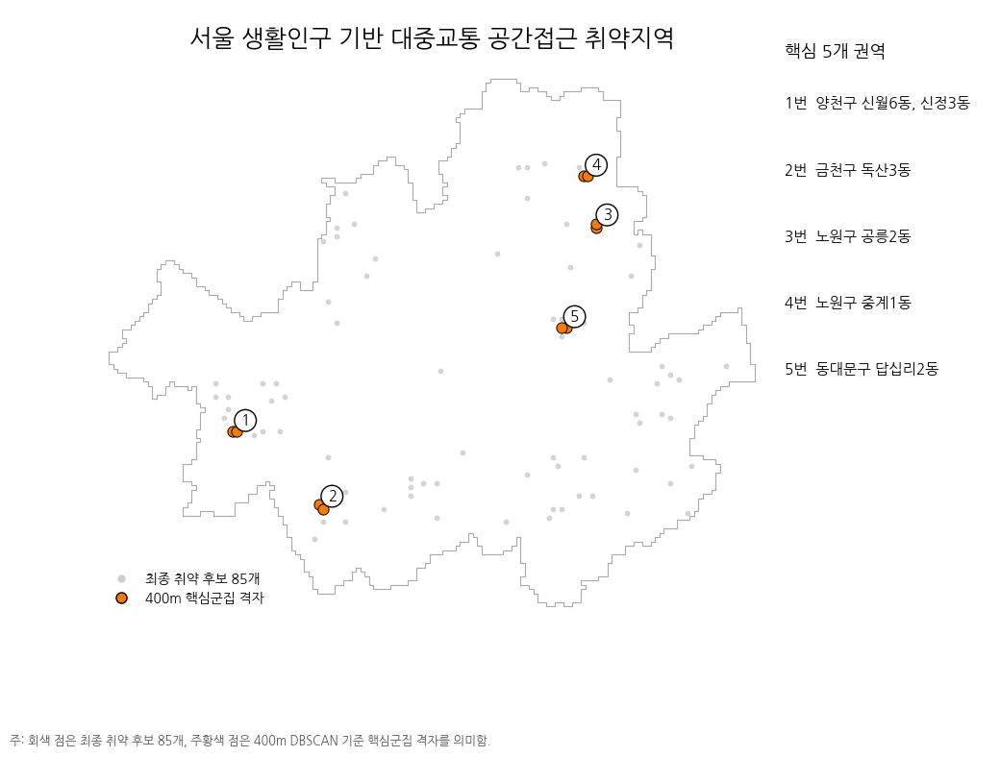

지도 저장 완료: /content/drive/MyDrive/교통공모전/final_analysis/output/final_core_regions_map.png


In [45]:
# ============================================================
# 42. 최종 취약 후보 및 핵심권역 공간분포 시각화
# ============================================================

import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# 1. 한글 폰트 설치 및 로드
# ------------------------------------------------------------

os.system("apt-get -qq update > /dev/null 2>&1")
os.system("apt-get -qq install -y fonts-nanum > /dev/null 2>&1")
os.system("fc-cache -fv > /dev/null 2>&1")

font_path = (
    subprocess
    .check_output(
        ["fc-match", "-f", "%{file}", "NanumGothic"]
    )
    .decode("utf-8")
    .strip()
)

if not os.path.exists(font_path):
    raise FileNotFoundError(f"한글 폰트 파일을 찾을 수 없습니다: {font_path}")

kor_font = font_manager.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False

print("사용 폰트:", font_path)


# ------------------------------------------------------------
# 2. 서울 외곽선 생성
# ------------------------------------------------------------

seoul_outline = grid_gdf.dissolve().copy()


# ------------------------------------------------------------
# 3. 최종 후보 85개 중심점
# ------------------------------------------------------------

candidate_points = candidate_geo.copy()

# geometry가 polygon이면 centroid로 변환
if candidate_points.geom_type.iloc[0] != "Point":
    candidate_points["geometry"] = candidate_points.geometry.centroid


# ------------------------------------------------------------
# 4. 400m 핵심군집 격자
# ------------------------------------------------------------

core_points = core400_clustered.copy()

if core_points.geom_type.iloc[0] != "Point":
    core_points["geometry"] = core_points.geometry.centroid


# ------------------------------------------------------------
# 5. 군집 대표 중심점
# ------------------------------------------------------------

cluster_centers = (
    core_points
    .dissolve(by="군집_400m")
    .centroid
)


# ------------------------------------------------------------
# 6. 권역 설명용 표 생성
#    - core400_summary가 이미 있는 흐름 기준
# ------------------------------------------------------------

region_table = (
    core400_summary[
        ["군집_400m", "자치구", "행정동", "평균최종점수"]
    ]
    .sort_values("평균최종점수", ascending=False)
    .reset_index(drop=True)
    .copy()
)

region_table["권역번호"] = np.arange(1, len(region_table) + 1)


# 군집ID -> 권역번호 매핑
cluster_to_rank = dict(
    zip(region_table["군집_400m"], region_table["권역번호"])
)


# ------------------------------------------------------------
# 7. Figure 구성
#    왼쪽: 지도 / 오른쪽: 권역 설명 패널
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(12, 9),
    facecolor="white"
)

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[4.8, 1.5],
    wspace=0.03
)

ax_map = fig.add_subplot(gs[0, 0])
ax_text = fig.add_subplot(gs[0, 1])

ax_map.set_facecolor("white")
ax_text.set_facecolor("white")


# ------------------------------------------------------------
# 8. 지도 그리기
# ------------------------------------------------------------

# 서울 외곽선
seoul_outline.boundary.plot(
    ax=ax_map,
    color="#A9A9A9",
    linewidth=0.8,
    zorder=1
)

# 최종 후보 85개
candidate_points.plot(
    ax=ax_map,
    color="#CFCFCF",
    markersize=10,
    alpha=0.85,
    zorder=2
)

# 400m 핵심군집 격자
core_points.plot(
    ax=ax_map,
    color="#F57C00",
    edgecolor="black",
    linewidth=0.7,
    markersize=65,
    zorder=3
)


# ------------------------------------------------------------
# 9. 권역번호 표시
# ------------------------------------------------------------

for cluster_id, center_geom in cluster_centers.items():

    rank_no = cluster_to_rank.get(cluster_id, None)

    if rank_no is None:
        continue

    ax_map.annotate(
        str(rank_no),
        xy=(center_geom.x, center_geom.y),
        xytext=(8, 8),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            boxstyle="circle,pad=0.25",
            fc="white",
            ec="black",
            lw=1.0
        ),
        zorder=4
    )


# ------------------------------------------------------------
# 10. 지도 제목 / 스타일
# ------------------------------------------------------------

ax_map.set_title(
    "서울 생활인구 기반 대중교통 공간접근 취약지역",
    fontproperties=kor_font,
    fontsize=18,
    fontweight="bold",
    pad=16
)

ax_map.set_axis_off()
ax_map.margins(0.02)


# ------------------------------------------------------------
# 11. 범례
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="#CFCFCF",
        markeredgecolor="none",
        markersize=6,
        label="최종 취약 후보 85개"
    ),
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="#F57C00",
        markeredgecolor="black",
        markersize=8,
        label="400m 핵심군집 격자"
    )
]

ax_map.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=False,
    prop=kor_font,
    fontsize=10
)


# ------------------------------------------------------------
# 12. 오른쪽 설명 패널
# ------------------------------------------------------------

ax_text.axis("off")

ax_text.text(
    0.02, 0.95,
    "핵심 5개 권역",
    fontproperties=kor_font,
    fontsize=13,
    fontweight="bold",
    ha="left",
    va="top"
)

y = 0.87
line_gap = 0.10

for _, row in region_table.iterrows():

    line = (
        f"{row['권역번호']}번  "
        f"{row['자치구']} {row['행정동']}"
    )

    ax_text.text(
        0.02, y,
        line,
        fontproperties=kor_font,
        fontsize=11,
        ha="left",
        va="top"
    )

    y -= line_gap


# ------------------------------------------------------------
# 13. 하단 주석
# ------------------------------------------------------------

fig.text(
    0.05, 0.03,
    "주: 회색 점은 최종 취약 후보 85개, 주황색 점은 400m DBSCAN 기준 핵심군집 격자를 의미함.",
    fontproperties=kor_font,
    fontsize=9,
    color="#555555"
)


# ------------------------------------------------------------
# 14. 저장
# ------------------------------------------------------------

plt.tight_layout(rect=[0, 0.05, 1, 0.98])

map_path = os.path.join(
    OUTPUT_DIR,
    "final_core_regions_map.png"
)

plt.savefig(
    map_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("지도 저장 완료:", map_path)

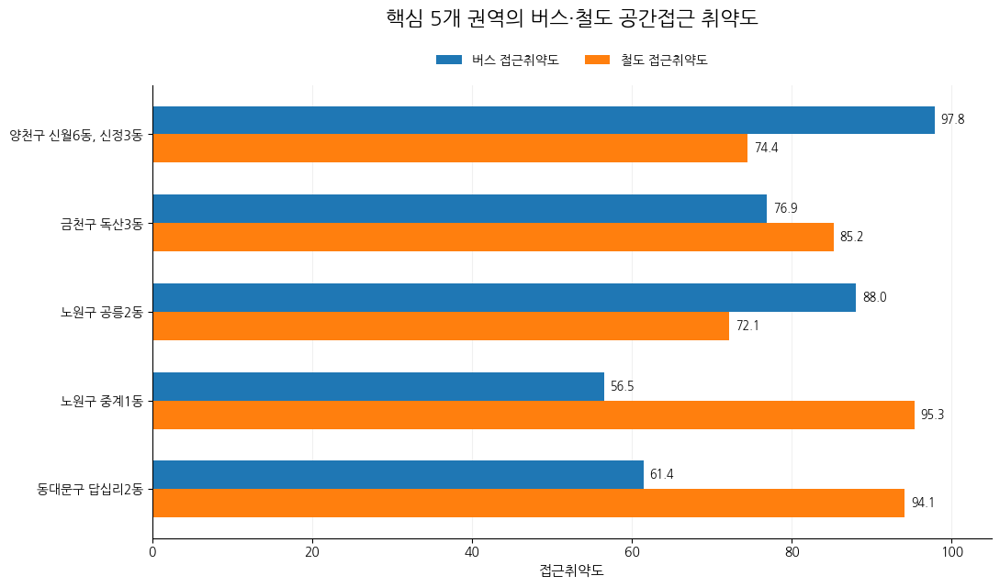

그래프 저장 완료: /content/drive/MyDrive/교통공모전/final_analysis/output/final_core_regions_bus_rail_comparison.png


In [46]:
# ============================================================
# 43. 핵심 5개 권역 버스·철도 접근취약도 비교
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 시각화용 데이터 정리
# ------------------------------------------------------------

plot_df = (
    final_core_regions
    .copy()
    .sort_values(
        "권역번호"
    )
    .reset_index(
        drop=True
    )
)


plot_df[
    "권역명"
] = (
    plot_df[
        "자치구"
    ]
    + " "
    + plot_df[
        "행정동"
    ]
)


# ------------------------------------------------------------
# 2. 막대 위치 설정
# ------------------------------------------------------------

y = np.arange(
    len(plot_df)
)

bar_height = 0.32


# ------------------------------------------------------------
# 3. Figure 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6.5),
    facecolor="white"
)

ax.set_facecolor(
    "white"
)


# ------------------------------------------------------------
# 4. 버스 접근취약도
# ------------------------------------------------------------

bars_bus = ax.barh(
    y - bar_height / 2,
    plot_df[
        "평균버스취약도"
    ],
    height=bar_height,
    label="버스 접근취약도"
)


# ------------------------------------------------------------
# 5. 철도 접근취약도
# ------------------------------------------------------------

bars_rail = ax.barh(
    y + bar_height / 2,
    plot_df[
        "평균철도취약도"
    ],
    height=bar_height,
    label="철도 접근취약도"
)


# ------------------------------------------------------------
# 6. Y축 권역명
# ------------------------------------------------------------

ax.set_yticks(
    y
)

ax.set_yticklabels(
    plot_df[
        "권역명"
    ],
    fontproperties=kor_font,
    fontsize=10
)


# 1번 권역이 위쪽에 오도록
ax.invert_yaxis()


# ------------------------------------------------------------
# 7. X축
# ------------------------------------------------------------

ax.set_xlim(
    0,
    105
)

ax.set_xlabel(
    "접근취약도",
    fontproperties=kor_font,
    fontsize=11
)


# ------------------------------------------------------------
# 8. 제목
# ------------------------------------------------------------

ax.set_title(
    "핵심 5개 권역의 버스·철도 공간접근 취약도",
    fontproperties=kor_font,
    fontsize=16,
    fontweight="bold",
    pad=48
)


# ------------------------------------------------------------
# 9. 범례
#
# 그래프 안이 아니라 제목 아래의 빈 공간에 배치
# ------------------------------------------------------------

ax.legend(
    loc="lower center",
    bbox_to_anchor=(
        0.5,
        1.015
    ),
    ncol=2,
    frameon=False,
    prop=kor_font
)


# ------------------------------------------------------------
# 10. 막대 끝에 실제 값 표시
# ------------------------------------------------------------

for bar in bars_bus:

    width = bar.get_width()

    ax.text(
        width + 0.8,
        bar.get_y()
        + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        ha="left",
        fontsize=9
    )


for bar in bars_rail:

    width = bar.get_width()

    ax.text(
        width + 0.8,
        bar.get_y()
        + bar.get_height() / 2,
        f"{width:.1f}",
        va="center",
        ha="left",
        fontsize=9
    )


# ------------------------------------------------------------
# 11. 보조선
# ------------------------------------------------------------

ax.grid(
    axis="x",
    alpha=0.18,
    linewidth=0.8
)

ax.set_axisbelow(
    True
)


# ------------------------------------------------------------
# 12. 테두리 정리
# ------------------------------------------------------------

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)


# ------------------------------------------------------------
# 13. 레이아웃
# ------------------------------------------------------------

plt.tight_layout()


# ------------------------------------------------------------
# 14. 이미지 저장
# ------------------------------------------------------------

comparison_path = os.path.join(
    OUTPUT_DIR,
    "final_core_regions_bus_rail_comparison.png"
)


plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)


plt.show()


print(
    "그래프 저장 완료:",
    comparison_path
)

### 9.4 핵심 취약권역 상세지도

서울 전체 공간분포만으로는 개별 핵심 취약권역에서
버스정류소와 철도역이 실제로 어떻게 배치되어 있는지 파악하기 어렵다.

따라서 400m DBSCAN 기준으로 도출된
**5개 핵심 취약권역 전체**에 대해 상세지도를 작성하였다.

각 권역은 하나의 통합 대중교통 공간접근 취약권역이며,
버스 취약지역과 철도 취약지역을 별도로 선정한 것은 아니다.

상세지도는 권역별로 다음 정보를 함께 제시한다.

- 핵심 취약 250m 격자
- 격자 중심점
- 버스 300m 분석반경
- 300m 내 버스정류소
- 최근접 버스정류소 및 직선거리
- 철도 800m 분석반경
- 800m 내 물리적 철도역
- 최근접 철도역 및 직선거리
- 권역 평균 버스·철도·통합 접근취약도와 최종점수
- 각 격자의 버스·철도 공간접근성 정보

배경지도는 실제 공간적 위치와 주변 환경을 쉽게 파악할 수 있도록
ArcGIS 기반 지도를 활용하였다.

이를 통해 동일한 기준으로 선정된 핵심 취약권역이라도
버스와 철도 공간접근 취약성의 형태가 권역별로 서로 다르게 나타날 수 있음을 확인한다.

지도에 표시된 연결선은 실제 보행경로를 의미하지 않으며,
본 분석에서 사용한 격자 중심과 교통시설 간 직선거리를 시각적으로 나타낸 것이다.

**시각화 배경지도:** Esri ArcGIS World Imagery, World Transportation, World Boundaries and Places


[1번 권역] 양천구 신월6동, 신정3동


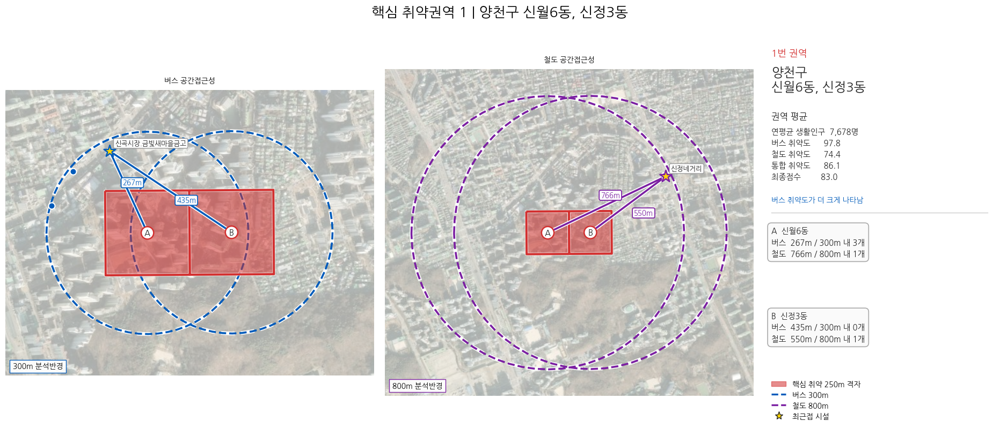

저장 완료: /content/drive/MyDrive/교통공모전/final_analysis/output/core_region_1_양천구_신월6동_신정3동_detail.png

[2번 권역] 금천구 독산3동


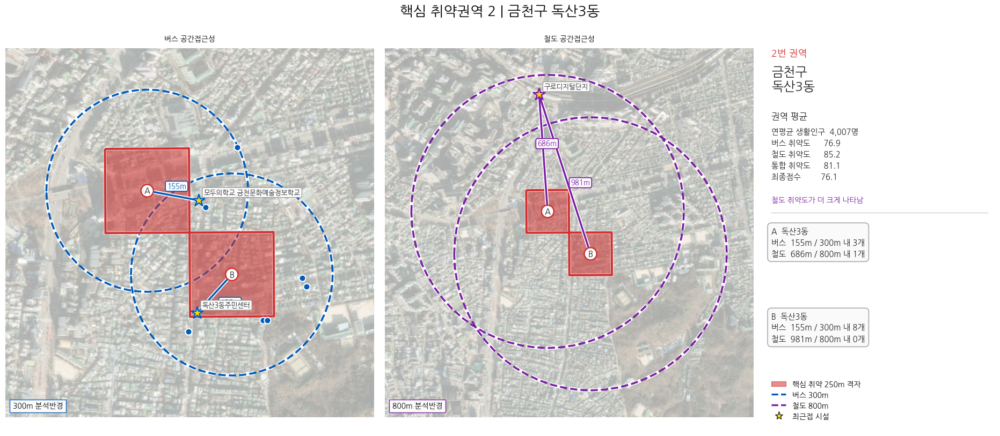

저장 완료: /content/drive/MyDrive/교통공모전/final_analysis/output/core_region_2_금천구_독산3동_detail.png

[3번 권역] 노원구 공릉2동


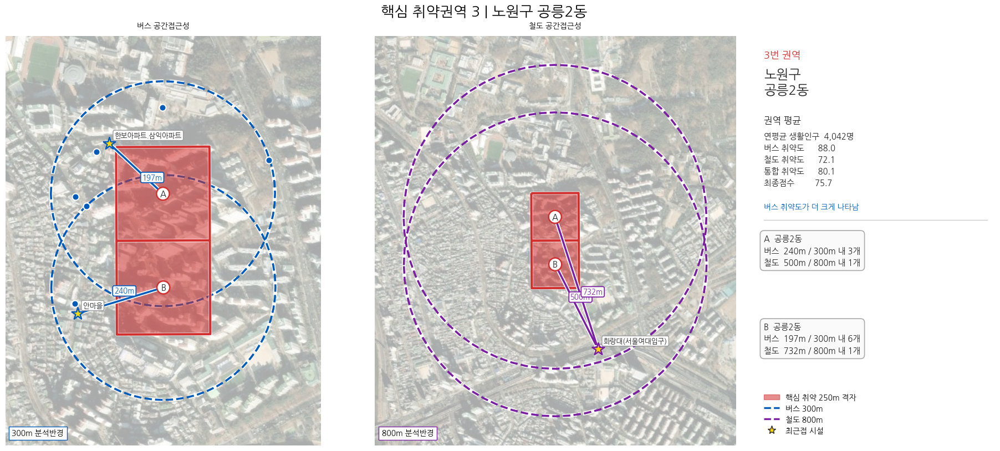

저장 완료: /content/drive/MyDrive/교통공모전/final_analysis/output/core_region_3_노원구_공릉2동_detail.png

[4번 권역] 노원구 중계1동


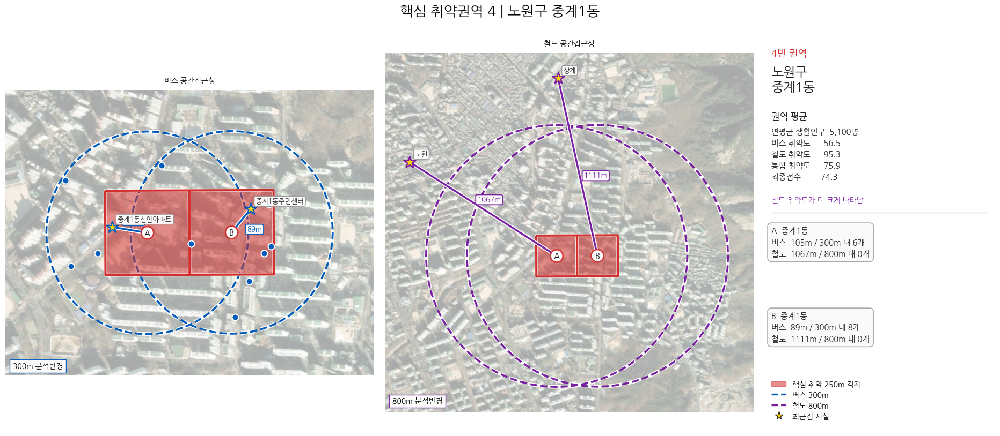

저장 완료: /content/drive/MyDrive/교통공모전/final_analysis/output/core_region_4_노원구_중계1동_detail.png

[5번 권역] 동대문구 답십리2동


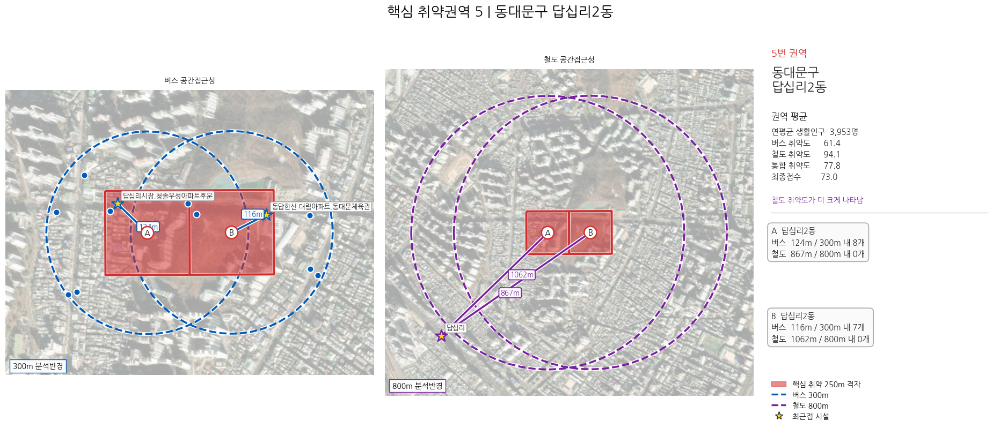

저장 완료: /content/drive/MyDrive/교통공모전/final_analysis/output/core_region_5_동대문구_답십리2동_detail.png

핵심 취약권역 5개 상세지도 생성 완료
/content/drive/MyDrive/교통공모전/final_analysis/output/core_region_1_양천구_신월6동_신정3동_detail.png
/content/drive/MyDrive/교통공모전/final_analysis/output/core_region_2_금천구_독산3동_detail.png
/content/drive/MyDrive/교통공모전/final_analysis/output/core_region_3_노원구_공릉2동_detail.png
/content/drive/MyDrive/교통공모전/final_analysis/output/core_region_4_노원구_중계1동_detail.png
/content/drive/MyDrive/교통공모전/final_analysis/output/core_region_5_동대문구_답십리2동_detail.png


In [47]:
# ============================================================
# 44. 핵심 취약권역 5개 전체 상세지도
#
# 권역별 1장씩 생성
#
# 왼쪽  : 버스 공간접근성
# 가운데: 철도 공간접근성
# 오른쪽: 권역 및 격자별 핵심지표
#
# 총 5개 PNG 자동 저장
# ============================================================

!pip install -q contextily

import os
import subprocess
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import contextily as ctx

from shapely.geometry import LineString
from shapely.ops import unary_union
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# 0. 한글 폰트 설정
# ============================================================

font_path = (
    subprocess
    .check_output(
        [
            "fc-match",
            "-f",
            "%{file}",
            "NanumGothic"
        ]
    )
    .decode("utf-8")
    .strip()
)

if os.path.exists(font_path):

    fm.fontManager.addfont(
        font_path
    )

    kor_font = fm.FontProperties(
        fname=font_path
    )

    plt.rcParams["font.family"] = (
        kor_font.get_name()
    )

else:

    kor_font = fm.FontProperties()

plt.rcParams["axes.unicode_minus"] = False


# ============================================================
# 1. 기본 색상
# ============================================================

GRID_COLOR = "#D32F2F"

BUS_COLOR = "#005BBB"

RAIL_COLOR = "#7B1FA2"

CENTER_COLOR = "#111111"

NEAREST_COLOR = "#FFD600"

WHITE = "#FFFFFF"

DARK = "#222222"

MUTED = "#555555"


# ============================================================
# 2. ArcGIS 배경지도
#
# OSM / CARTO 사용하지 않음
# ============================================================

ARCGIS_IMAGERY = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "World_Imagery/MapServer/tile/{z}/{y}/{x}"
)

ARCGIS_TRANSPORT = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "Reference/World_Transportation/MapServer/tile/{z}/{y}/{x}"
)

ARCGIS_LABELS = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "Reference/World_Boundaries_and_Places/MapServer/tile/{z}/{y}/{x}"
)


def add_light_basemap(
    ax,
    zoom
):

    """
    실제 위성사진은 흐리게 표시하고,
    도로·지명을 그 위에 표시한다.
    """

    try:

        ctx.add_basemap(
            ax,
            source=ARCGIS_IMAGERY,
            zoom=zoom,
            attribution=False,
            alpha=0.34,
            zorder=0
        )

        try:

            ctx.add_basemap(
                ax,
                source=ARCGIS_TRANSPORT,
                zoom=zoom,
                attribution=False,
                alpha=0.75,
                zorder=1
            )

        except Exception:
            pass

        try:

            ctx.add_basemap(
                ax,
                source=ARCGIS_LABELS,
                zoom=zoom,
                attribution=False,
                alpha=0.90,
                zorder=2
            )

        except Exception:
            pass

        return True

    except Exception as e:

        print(
            "배경지도 로드 실패:",
            str(e)
        )

        ax.set_facecolor(
            "#F2F2F2"
        )

        return False


# ============================================================
# 3. 공통 함수
# ============================================================

def to_3857(
    gdf
):

    return (
        gdf
        .to_crs(
            epsg=3857
        )
    )


def get_extent_3857(
    geometries,
    padding_m
):

    valid = [

        geom

        for geom in geometries

        if geom is not None
        and not geom.is_empty
    ]


    merged = unary_union(
        valid
    )


    extent_geometry = (
        merged
        .envelope
        .buffer(
            padding_m
        )
    )


    return (
        gpd.GeoSeries(
            [
                extent_geometry
            ],
            crs="EPSG:5179"
        )
        .to_crs(
            epsg=3857
        )
        .total_bounds
    )


# ------------------------------------------------------------
# 분석반경
#
# 흰색 테두리를 먼저 그려 위성사진 위에서도
# 파랑/보라 점선이 잘 보이게 함
# ------------------------------------------------------------

def plot_buffer(
    ax,
    buffers,
    color
):

    buffers.boundary.plot(
        ax=ax,
        color=WHITE,
        linewidth=5.0,
        linestyle="--",
        alpha=0.95,
        zorder=10
    )

    buffers.boundary.plot(
        ax=ax,
        color=color,
        linewidth=2.6,
        linestyle="--",
        alpha=1.0,
        zorder=11
    )


# ------------------------------------------------------------
# 최근접 거리 연결선
# ------------------------------------------------------------

def plot_distance_lines(
    ax,
    lines,
    color
):

    lines.plot(
        ax=ax,
        color=WHITE,
        linewidth=5.0,
        zorder=15
    )

    lines.plot(
        ax=ax,
        color=color,
        linewidth=2.5,
        zorder=16
    )


# ------------------------------------------------------------
# 격자 A/B 부여
#
# 지도에서 왼쪽 격자 = A
# 오른쪽 격자 = B
# ------------------------------------------------------------

def sorted_centers_ab(
    centers
):

    temp = (
        centers
        .copy()
    )

    temp["_x"] = (
        temp
        .geometry
        .x
    )

    return (
        temp
        .sort_values(
            "_x"
        )
        .reset_index(
            drop=True
        )
    )


def add_ab_labels(
    ax,
    centers_3857
):

    temp = (
        sorted_centers_ab(
            centers_3857
        )
    )


    for i, row in (
        temp
        .iterrows()
    ):

        letter = (
            "A"
            if i == 0
            else
            "B"
        )

        ax.annotate(

            letter,

            xy=(
                row.geometry.x,
                row.geometry.y
            ),

            ha="center",
            va="center",

            fontsize=11,

            fontweight="bold",

            fontproperties=kor_font,

            color=DARK,

            bbox=dict(
                boxstyle="circle,pad=0.27",
                facecolor=WHITE,
                edgecolor=GRID_COLOR,
                linewidth=1.8,
                alpha=1.0
            ),

            zorder=40
        )


# ------------------------------------------------------------
# 최근접 거리 숫자 표시
# ------------------------------------------------------------

def add_distance_labels(
    ax,
    lines,
    color
):

    for i, (_, row) in enumerate(

        lines
        .reset_index(
            drop=True
        )
        .iterrows()
    ):

        midpoint = (
            row.geometry
            .interpolate(
                0.5,
                normalized=True
            )
        )


        if i == 0:

            offset = (
                -8,
                10
            )

        else:

            offset = (
                8,
                -14
            )


        ax.annotate(

            f"{row['distance_m']:.0f}m",

            xy=(
                midpoint.x,
                midpoint.y
            ),

            xytext=offset,

            textcoords="offset points",

            fontsize=9.5,

            fontweight="bold",

            fontproperties=kor_font,

            color=color,

            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor=WHITE,
                edgecolor=color,
                linewidth=1.3,
                alpha=0.97
            ),

            zorder=35
        )


# ============================================================
# 4. 권역별 상세지도 생성 함수
# ============================================================

def make_core_region_map(
    region_no,
    detail_row
):

    # --------------------------------------------------------
    # 군집 기본정보
    # --------------------------------------------------------

    cluster_id = int(
        detail_row[
            "군집_400m"
        ]
    )

    district = str(
        detail_row[
            "자치구"
        ]
    )

    dong_name = str(
        detail_row[
            "행정동"
        ]
    )


    print(
        f"\n[{region_no}번 권역] "
        f"{district} {dong_name}"
    )


    # ========================================================
    # 4-1. 해당 군집 격자
    # ========================================================

    centers = (

        core400_clustered[
            core400_clustered[
                "군집_400m"
            ]
            ==
            cluster_id
        ]

        .copy()
    )


    grids = (

        candidate_geo[
            candidate_geo[
                "CELL_ID"
            ]
            .isin(
                centers[
                    "CELL_ID"
                ]
            )
        ]

        .copy()
    )


    # A/B 순서
    centers_ab = (
        sorted_centers_ab(
            centers
        )
    )


    # ========================================================
    # 4-2. 버스 정보
    # ========================================================

    BUS_RADIUS = 300


    bus_buffers = gpd.GeoDataFrame(

        centers[
            [
                "CELL_ID"
            ]
        ].copy(),

        geometry=(
            centers
            .geometry
            .buffer(
                BUS_RADIUS
            )
        ),

        crs=centers.crs
    )


    bus_nearby_indices = set()

    bus_nearest_indices = []

    bus_line_rows = []

    bus_grid_info = {}


    for _, row in centers.iterrows():

        center_geom = (
            row.geometry
        )


        distances = (
            bus_locations
            .geometry
            .distance(
                center_geom
            )
        )


        nearby_indices = (

            bus_locations
            .index[
                distances
                <=
                BUS_RADIUS
            ]
            .tolist()
        )


        bus_nearby_indices.update(
            nearby_indices
        )


        nearest_idx = (
            distances
            .idxmin()
        )


        nearest_stop = (
            bus_locations
            .loc[
                nearest_idx
            ]
        )


        nearest_distance = float(
            distances.loc[
                nearest_idx
            ]
        )


        bus_nearest_indices.append(
            nearest_idx
        )


        bus_line_rows.append(
            {
                "CELL_ID":
                row[
                    "CELL_ID"
                ],

                "distance_m":
                nearest_distance,

                "geometry":
                LineString(
                    [
                        center_geom,
                        nearest_stop.geometry
                    ]
                )
            }
        )


        bus_grid_info[
            row[
                "CELL_ID"
            ]
        ] = {

            "dong":
            row[
                "ADMI_NM"
            ],

            "count":
            int(
                len(
                    nearby_indices
                )
            ),

            "distance":
            nearest_distance,

            "name":
            str(
                nearest_stop[
                    "정류소명"
                ]
            )
        }


    if len(
        bus_nearby_indices
    ) > 0:

        nearby_bus = (

            bus_locations
            .loc[
                sorted(
                    bus_nearby_indices
                )
            ]
            .copy()
        )

    else:

        nearby_bus = (
            bus_locations
            .iloc[
                0:0
            ]
            .copy()
        )


    nearest_bus = (

        bus_locations
        .loc[
            list(
                dict.fromkeys(
                    bus_nearest_indices
                )
            )
        ]
        .copy()
    )


    bus_lines = gpd.GeoDataFrame(

        bus_line_rows,

        geometry="geometry",

        crs="EPSG:5179"
    )


    # ========================================================
    # 4-3. 철도 정보
    # ========================================================

    RAIL_RADIUS = 800


    rail_buffers = gpd.GeoDataFrame(

        centers[
            [
                "CELL_ID"
            ]
        ].copy(),

        geometry=(
            centers
            .geometry
            .buffer(
                RAIL_RADIUS
            )
        ),

        crs=centers.crs
    )


    rail_nearest_indices = []

    rail_line_rows = []

    rail_grid_info = {}


    # 800m 안에 존재하는 물리역 ID 전체
    rail_nearby_physical_ids = set()


    for _, row in centers.iterrows():

        center_geom = (
            row.geometry
        )


        distances = (

            rail_station_points
            .geometry
            .distance(
                center_geom
            )
        )


        nearby_mask = (
            distances
            <=
            RAIL_RADIUS
        )


        nearby_ids = (

            rail_station_points
            .loc[
                nearby_mask,
                "물리역_ID"
            ]
            .dropna()
            .unique()
            .tolist()
        )


        rail_nearby_physical_ids.update(
            nearby_ids
        )


        nearest_idx = (
            distances
            .idxmin()
        )


        nearest_station = (

            rail_station_points
            .loc[
                nearest_idx
            ]
        )


        nearest_distance = float(

            distances.loc[
                nearest_idx
            ]
        )


        rail_nearest_indices.append(
            nearest_idx
        )


        rail_line_rows.append(
            {
                "CELL_ID":
                row[
                    "CELL_ID"
                ],

                "distance_m":
                nearest_distance,

                "geometry":
                LineString(
                    [
                        center_geom,
                        nearest_station.geometry
                    ]
                )
            }
        )


        rail_grid_info[
            row[
                "CELL_ID"
            ]
        ] = {

            "dong":
            row[
                "ADMI_NM"
            ],

            "count":
            int(
                len(
                    nearby_ids
                )
            ),

            "distance":
            nearest_distance,

            "name":
            str(
                nearest_station[
                    "역사명_통합기준"
                ]
            )
        }


    nearest_rail = (

        rail_station_points
        .loc[
            list(
                dict.fromkeys(
                    rail_nearest_indices
                )
            )
        ]
        .copy()
    )


    rail_lines = gpd.GeoDataFrame(

        rail_line_rows,

        geometry="geometry",

        crs="EPSG:5179"
    )


    # --------------------------------------------------------
    # 800m 이내 물리적 역은 하나의 대표 실제 좌표만 표시
    # --------------------------------------------------------

    if len(
        rail_nearby_physical_ids
    ) > 0:

        nearby_rail = (

            rail_station_points[
                rail_station_points[
                    "물리역_ID"
                ]
                .isin(
                    rail_nearby_physical_ids
                )
            ]
            .copy()
        )


        cluster_center = (

            unary_union(
                list(
                    centers.geometry
                )
            )
            .centroid
        )


        nearby_rail[
            "_cluster_distance"
        ] = (

            nearby_rail
            .geometry
            .distance(
                cluster_center
            )
        )


        nearby_rail = (

            nearby_rail
            .sort_values(
                "_cluster_distance"
            )
            .drop_duplicates(
                "물리역_ID"
            )
            .copy()
        )

    else:

        nearby_rail = (

            rail_station_points
            .iloc[
                0:0
            ]
            .copy()
        )


    # ========================================================
    # 4-4. EPSG:3857 변환
    # ========================================================

    grids_3857 = (
        to_3857(
            grids
        )
    )

    centers_3857 = (
        to_3857(
            centers
        )
    )


    bus_buffers_3857 = (
        to_3857(
            bus_buffers
        )
    )

    nearby_bus_3857 = (
        to_3857(
            nearby_bus
        )
    )

    nearest_bus_3857 = (
        to_3857(
            nearest_bus
        )
    )

    bus_lines_3857 = (
        to_3857(
            bus_lines
        )
    )


    rail_buffers_3857 = (
        to_3857(
            rail_buffers
        )
    )

    nearby_rail_3857 = (
        to_3857(
            nearby_rail
        )
    )

    nearest_rail_3857 = (
        to_3857(
            nearest_rail
        )
    )

    rail_lines_3857 = (
        to_3857(
            rail_lines
        )
    )


    # ========================================================
    # 4-5. 버스 / 철도 지도범위 별도 산출
    # ========================================================

    bus_extent = get_extent_3857(

        list(
            bus_buffers.geometry
        )
        +
        list(
            nearest_bus.geometry
        ),

        padding_m=120
    )


    rail_extent = get_extent_3857(

        list(
            rail_buffers.geometry
        )
        +
        list(
            nearest_rail.geometry
        ),

        padding_m=150
    )


    # ========================================================
    # 4-6. 그림 틀
    #
    # 버스지도 / 철도지도 / 정보패널
    # ========================================================

    fig = plt.figure(

        figsize=(
            19,
            8.5
        ),

        facecolor="white"
    )


    gs = fig.add_gridspec(

        1,
        3,

        width_ratios=[
            3.2,
            3.2,
            2.0
        ],

        wspace=0.035
    )


    bus_ax = fig.add_subplot(
        gs[
            0,
            0
        ]
    )

    rail_ax = fig.add_subplot(
        gs[
            0,
            1
        ]
    )

    info_ax = fig.add_subplot(
        gs[
            0,
            2
        ]
    )


    # ========================================================
    # 5. 버스 지도
    # ========================================================

    bus_ax.set_xlim(
        bus_extent[0],
        bus_extent[2]
    )

    bus_ax.set_ylim(
        bus_extent[1],
        bus_extent[3]
    )


    add_light_basemap(
        bus_ax,
        zoom=16
    )


    # 분석반경
    plot_buffer(
        bus_ax,
        bus_buffers_3857,
        BUS_COLOR
    )


    # 핵심격자
    grids_3857.plot(

        ax=bus_ax,

        facecolor=GRID_COLOR,

        edgecolor=WHITE,

        linewidth=4.5,

        alpha=0.52,

        zorder=12
    )


    grids_3857.boundary.plot(

        ax=bus_ax,

        color=GRID_COLOR,

        linewidth=2.8,

        zorder=13
    )


    # 300m 정류장
    if len(
        nearby_bus_3857
    ) > 0:

        nearby_bus_3857.plot(

            ax=bus_ax,

            marker="o",

            markersize=75,

            color=BUS_COLOR,

            edgecolor=WHITE,

            linewidth=1.5,

            zorder=19
        )


    # 최근접 정류장
    nearest_bus_3857.plot(

        ax=bus_ax,

        marker="*",

        markersize=270,

        color=NEAREST_COLOR,

        edgecolor=BUS_COLOR,

        linewidth=1.8,

        zorder=22
    )


    # 연결선
    plot_distance_lines(
        bus_ax,
        bus_lines_3857,
        BUS_COLOR
    )


    # 중심점
    centers_3857.plot(

        ax=bus_ax,

        marker="X",

        markersize=110,

        color=CENTER_COLOR,

        edgecolor=WHITE,

        linewidth=1.4,

        zorder=24
    )


    add_ab_labels(
        bus_ax,
        centers_3857
    )


    add_distance_labels(
        bus_ax,
        bus_lines_3857,
        BUS_COLOR
    )


    # 최근접 정류소명
    for _, row in (

        nearest_bus_3857
        .drop_duplicates(
            "정류소명"
        )
        .iterrows()
    ):

        bus_ax.annotate(

            str(
                row[
                    "정류소명"
                ]
            ),

            xy=(
                row.geometry.x,
                row.geometry.y
            ),

            xytext=(
                7,
                8
            ),

            textcoords="offset points",

            fontsize=9,

            fontweight="bold",

            fontproperties=kor_font,

            color=DARK,

            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor=WHITE,
                edgecolor="#999999",
                alpha=0.96
            ),

            zorder=35
        )


    bus_ax.set_title(

        "버스 공간접근성",

        fontsize=16,

        fontweight="bold",

        fontproperties=kor_font,

        pad=10
    )


    bus_ax.text(

        0.02,
        0.025,

        "300m 분석반경",

        transform=bus_ax.transAxes,

        fontsize=10,

        fontproperties=kor_font,

        bbox=dict(
            facecolor=WHITE,
            edgecolor=BUS_COLOR,
            alpha=0.94
        )
    )


    bus_ax.set_axis_off()


    # ========================================================
    # 6. 철도 지도
    # ========================================================

    rail_ax.set_xlim(
        rail_extent[0],
        rail_extent[2]
    )

    rail_ax.set_ylim(
        rail_extent[1],
        rail_extent[3]
    )


    add_light_basemap(
        rail_ax,
        zoom=15
    )


    # 800m 분석반경
    plot_buffer(
        rail_ax,
        rail_buffers_3857,
        RAIL_COLOR
    )


    # 핵심격자
    grids_3857.plot(

        ax=rail_ax,

        facecolor=GRID_COLOR,

        edgecolor=WHITE,

        linewidth=4.5,

        alpha=0.52,

        zorder=12
    )


    grids_3857.boundary.plot(

        ax=rail_ax,

        color=GRID_COLOR,

        linewidth=2.8,

        zorder=13
    )


    # 800m 내 철도역
    if len(
        nearby_rail_3857
    ) > 0:

        nearby_rail_3857.plot(

            ax=rail_ax,

            marker="s",

            markersize=80,

            color=RAIL_COLOR,

            edgecolor=WHITE,

            linewidth=1.5,

            zorder=19
        )


    # 최근접 철도역
    nearest_rail_3857.plot(

        ax=rail_ax,

        marker="*",

        markersize=280,

        color=NEAREST_COLOR,

        edgecolor=RAIL_COLOR,

        linewidth=1.8,

        zorder=22
    )


    # 연결선
    plot_distance_lines(
        rail_ax,
        rail_lines_3857,
        RAIL_COLOR
    )


    # 중심점
    centers_3857.plot(

        ax=rail_ax,

        marker="X",

        markersize=110,

        color=CENTER_COLOR,

        edgecolor=WHITE,

        linewidth=1.4,

        zorder=24
    )


    add_ab_labels(
        rail_ax,
        centers_3857
    )


    add_distance_labels(
        rail_ax,
        rail_lines_3857,
        RAIL_COLOR
    )


    # 최근접 철도역명
    for _, row in (

        nearest_rail_3857
        .drop_duplicates(
            "역사명_통합기준"
        )
        .iterrows()
    ):

        rail_ax.annotate(

            str(
                row[
                    "역사명_통합기준"
                ]
            ),

            xy=(
                row.geometry.x,
                row.geometry.y
            ),

            xytext=(
                7,
                8
            ),

            textcoords="offset points",

            fontsize=9,

            fontweight="bold",

            fontproperties=kor_font,

            color=DARK,

            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor=WHITE,
                edgecolor="#999999",
                alpha=0.96
            ),

            zorder=35
        )


    rail_ax.set_title(

        "철도 공간접근성",

        fontsize=16,

        fontweight="bold",

        fontproperties=kor_font,

        pad=10
    )


    rail_ax.text(

        0.02,
        0.025,

        "800m 분석반경",

        transform=rail_ax.transAxes,

        fontsize=10,

        fontproperties=kor_font,

        bbox=dict(
            facecolor=WHITE,
            edgecolor=RAIL_COLOR,
            alpha=0.94
        )
    )


    rail_ax.set_axis_off()


    # ========================================================
    # 7. 오른쪽 정보패널
    # ========================================================

    info_ax.set_axis_off()

    info_ax.set_xlim(
        0,
        1
    )

    info_ax.set_ylim(
        0,
        1
    )


    # --------------------------------------------------------
    # 권역 제목
    # --------------------------------------------------------

    info_ax.text(

        0.03,
        0.965,

        f"{region_no}번 권역",

        ha="left",
        va="top",

        fontsize=13,

        fontweight="bold",

        fontproperties=kor_font,

        color=GRID_COLOR
    )


    info_ax.text(

        0.03,
        0.92,

        (
            f"{district}\n"
            f"{dong_name}"
        ),

        ha="left",
        va="top",

        fontsize=17,

        fontweight="bold",

        fontproperties=kor_font,

        color=DARK
    )


    # --------------------------------------------------------
    # 권역 평균
    # --------------------------------------------------------

    dominant_text = (

        "버스 취약도가 더 크게 나타남"

        if (
            detail_row[
                "평균버스취약도"
            ]
            >
            detail_row[
                "평균철도취약도"
            ]
        )

        else

        "철도 취약도가 더 크게 나타남"
    )


    info_ax.text(

        0.03,
        0.805,

        "권역 평균",

        ha="left",
        va="top",

        fontsize=12,

        fontweight="bold",

        fontproperties=kor_font,

        color=DARK
    )


    average_text = (

        f"연평균 생활인구  "
        f"{detail_row['평균생활인구']:,.0f}명\n"

        f"버스 취약도      "
        f"{detail_row['평균버스취약도']:.1f}\n"

        f"철도 취약도      "
        f"{detail_row['평균철도취약도']:.1f}\n"

        f"통합 취약도      "
        f"{detail_row['평균대중교통취약도']:.1f}\n"

        f"최종점수         "
        f"{detail_row['평균최종점수']:.1f}"
    )


    info_ax.text(

        0.03,
        0.765,

        average_text,

        ha="left",
        va="top",

        fontsize=10.5,

        linespacing=1.5,

        fontproperties=kor_font,

        color=DARK
    )


    info_ax.text(

        0.03,
        0.59,

        dominant_text,

        ha="left",
        va="top",

        fontsize=10,

        fontweight="bold",

        fontproperties=kor_font,

        color=(
            BUS_COLOR

            if (
                detail_row[
                    "평균버스취약도"
                ]
                >
                detail_row[
                    "평균철도취약도"
                ]
            )

            else

            RAIL_COLOR
        )
    )


    # --------------------------------------------------------
    # A/B 격자 정보
    # --------------------------------------------------------

    info_ax.plot(

        [
            0.03,
            0.97
        ],

        [
            0.55,
            0.55
        ],

        color="#CCCCCC",

        linewidth=1
    )


    centers_ab_original = (
        sorted_centers_ab(
            centers
        )
    )


    for i, row in (
        centers_ab_original
        .iterrows()
    ):

        cell_id = (
            row[
                "CELL_ID"
            ]
        )


        letter = (
            "A"
            if i == 0
            else
            "B"
        )


        bus_data = (
            bus_grid_info[
                cell_id
            ]
        )


        rail_data = (
            rail_grid_info[
                cell_id
            ]
        )


        y = (
            0.515

            if i == 0

            else

            0.30
        )


        card_text = (

            f"{letter}  {row['ADMI_NM']}\n"

            f"버스  "
            f"{bus_data['distance']:.0f}m / "
            f"300m 내 {bus_data['count']}개\n"

            f"철도  "
            f"{rail_data['distance']:.0f}m / "
            f"800m 내 {rail_data['count']}개"
        )


        info_ax.text(

            0.03,
            y,

            card_text,

            ha="left",
            va="top",

            fontsize=10.5,

            linespacing=1.55,

            fontproperties=kor_font,

            color=DARK,

            bbox=dict(
                boxstyle="round,pad=0.48",
                facecolor="#FAFAFA",
                edgecolor="#AAAAAA",
                linewidth=1.2
            )
        )


    # --------------------------------------------------------
    # 범례
    # --------------------------------------------------------

    legend_items = [

        Patch(
            facecolor=GRID_COLOR,
            edgecolor=GRID_COLOR,
            alpha=0.55,
            label="핵심 취약 250m 격자"
        ),

        Line2D(
            [0],
            [0],
            color=BUS_COLOR,
            linestyle="--",
            linewidth=2.4,
            label="버스 300m"
        ),

        Line2D(
            [0],
            [0],
            color=RAIL_COLOR,
            linestyle="--",
            linewidth=2.4,
            label="철도 800m"
        ),

        Line2D(
            [0],
            [0],
            marker="*",
            color="none",
            markerfacecolor=NEAREST_COLOR,
            markeredgecolor=DARK,
            markersize=11,
            label="최근접 시설"
        )
    ]


    info_ax.legend(

        handles=legend_items,

        loc="lower left",

        bbox_to_anchor=(
            0.00,
            0.01
        ),

        frameon=False,

        prop=kor_font
    )


    # ========================================================
    # 8. 전체 제목
    # ========================================================

    fig.suptitle(

        (
            f"핵심 취약권역 {region_no} "
            f"| {district} {dong_name}"
        ),

        fontsize=19,

        fontweight="bold",

        fontproperties=kor_font,

        y=0.975
    )


    plt.subplots_adjust(
        top=0.91,
        bottom=0.04,
        left=0.015,
        right=0.985
    )


    # ========================================================
    # 9. 저장
    # ========================================================

    safe_dong = (
        dong_name
        .replace(
            ", ",
            "_"
        )
        .replace(
            " ",
            "_"
        )
    )


    save_path = os.path.join(

        OUTPUT_DIR,

        (
            f"core_region_{region_no}_"
            f"{district}_{safe_dong}_detail.png"
        )
    )


    plt.savefig(

        save_path,

        dpi=300,

        bbox_inches="tight",

        facecolor="white"
    )


    plt.show()


    print(
        "저장 완료:",
        save_path
    )


    return save_path


# ============================================================
# 10. 최종 5개 권역 전체 생성
#
# core400_detail은 이미 평균최종점수 내림차순
# ============================================================

all_map_paths = []


for region_index, row in (
    core400_detail
    .reset_index(
        drop=True
    )
    .iterrows()
):

    region_no = (
        region_index
        + 1
    )


    output_path = make_core_region_map(

        region_no,

        row
    )


    all_map_paths.append(
        output_path
    )


# ============================================================
# 11. 완료 확인
# ============================================================

print(
    "\n"
    + "=" * 60
)

print(
    "핵심 취약권역 5개 상세지도 생성 완료"
)

print(
    "=" * 60
)


for path in all_map_paths:

    print(
        path
    )

## 10. 분석 범위 및 향후 확장

본 분석은 생활인구 수요가 높은 지역을 대상으로
버스정류소와 철도역의 공간적 배치를 결합하여
서울 내 대중교통 공간접근 취약성을 상대적으로 비교하는 데 초점을 둔다.

분석 결과의 해석 범위와 향후 확장 방향은 다음과 같다.

1. 본 분석의 거리 지표는 격자 중심과 교통시설 간 직선거리를 기준으로 산출하였다.
   향후 보행도로망을 결합하면 횡단보도, 하천, 철도시설 등 실제 이동환경을 반영한
   보행 접근성 분석으로 확장할 수 있다.

2. 버스와 철도 접근성은 시설까지의 거리와 주변 시설 수를 중심으로 평가하였다.
   향후 노선 수, 배차간격, 운행빈도, 급행운행, 환승편의성 등의 운영정보를 결합하면
   공간접근성과 실제 서비스 수준을 함께 고려할 수 있다.

3. 버스 300m와 철도 800m는 지역 간 상대적인 공간접근성을 비교하기 위해 설정한
   분석 반경이다. 따라서 본 결과는 동일한 기준 아래 서울 지역 간 접근성을
   비교한 상대적 취약도 지표로 해석한다.

4. 생활인구는 2025년 9월부터 2026년 8월까지의 1년 자료를 사용한 반면,
   버스정류소와 철도역은 분석에 사용한 시점의 공간정보를 적용하였다.
   따라서 실제 정책 적용 시에는 최신 교통시설 현황과 지역별 운영여건을 함께
   확인함으로써 분석 결과를 보다 구체적인 정책 검토로 확장할 수 있다.

## 분석 마무리

본 분석에서는 2025년 9월부터 2026년 8월까지의 서울 생활인구와
버스정류소·철도역 공간정보를 결합하여
250m 격자 단위의 대중교통 공간접근 취약지역을 분석하였다.

연간 관측률이 충분한 격자 가운데 생활인구 상위 10%인
849개 격자를 주요 분석대상으로 선정하고,
버스와 철도의 공간접근 취약도를 각각 산출하였다.

이후 전체 유효격자에서 산출한 생활인구 백분위를 함께 반영하여
최종 취약 우선순위를 계산하고,
고생활인구 849개 격자 가운데 상위 10%인 85개 격자를
최종 취약 후보로 선정하였다.

개별 격자의 높은 점수에만 의존하지 않고
DBSCAN 공간군집 분석을 추가로 적용하여
인접한 공간에서 취약성이 반복적으로 나타나는 지역을 확인하였다.

400m 기준에서는 다음 5개 핵심 취약권역이 도출되었다.

- 양천구 신월6동·신정3동
- 금천구 독산3동
- 노원구 공릉2동
- 노원구 중계1동
- 동대문구 답십리2동

거리기준을 400m·500m·600m로 변화시켜
공간군집 형성의 변화를 비교하였으며,
버스·철도 가중치를 40:60, 50:50, 60:40으로 변화시킨 결과에서도
격자 순위 간 Spearman 상관계수가 약 0.92~0.98로 나타나
가중치 변화에 따른 전체 순위 구조는 대체로 유사하게 유지되었다.

또한 핵심 취약권역별로 버스와 철도 접근취약성의 양상이 서로 다르게 나타났다.
양천구 신월6동·신정3동과 노원구 공릉2동에서는 버스 접근취약도가 상대적으로 크게 나타났으며,
금천구 독산3동, 노원구 중계1동, 동대문구 답십리2동에서는
철도 접근취약도가 상대적으로 크게 나타났다.

이를 통해 생활인구 수요와 교통시설의 공간접근성을 함께 고려하면
단순한 시설 분포만으로는 확인하기 어려운 대중교통 공간접근 취약지역을
격자와 권역 수준에서 구체적으로 식별할 수 있음을 확인하였다.

본 분석 결과는 서울 내 대중교통 공간접근 취약지역을 파악하고,
권역별로 서로 다른 버스·철도 취약특성을 고려한
교통정책 검토 대상을 구체화하는 공간적 근거로 활용할 수 있다.